# IPD Brain - baseline performance, label-confidence tiers, subgroup analysis, uncertainty quantification

External validation of the locked ABMIL ensemble (trained on EBRAINS, thresholds
locked on TCGA calibration sites, never refit here) on the IPD Brain cohort (320
patients, India, IHC-based IDH calls). Covers baseline performance,
label-confidence-tier analysis, subgroup analysis, and, in Part E, the same six
uncertainty-quantification families defined and compared the same way as
`selective_prediction_bench_clean.ipynb` (predictive, epistemic, MC-dropout, deep
ensemble, Laplace, OOD), with the label-confidence tier axis woven into every UQ
comparison rather than bolted on afterward.

No refitting happens anywhere in this notebook. Every operating threshold is
loaded from `outputs/selective_prediction_bench/baseline_overall_metrics.csv` (the
TCGA bench's own locked, calibration-site-derived Youden thresholds); computing a
new threshold from IPD Brain's own labels would defeat the point of external
validation.

Label-confidence tiers, rather than the raw IHC call taken at face value: IPD
Brain's IDH1R132H is IHC-based, which only detects the single most common mutation
and misses non-R132H IDH1/all IDH2 cases, so IHC-negative isn't the same as
confirmed-wildtype. Each patient is assigned a tier: A (n=312, high confidence) or
C (n=8, case-specific evidence of likely mislabeling). This notebook reports
performance for the full cohort and for Level A alone, and tests directly whether
Level C behaves differently, which would itself be evidence the tier system is
doing real work rather than just a plausible-sounding heuristic.

## 0. Config & imports

In [ ]:
from __future__ import annotations

from pathlib import Path
from itertools import combinations
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, rankdata
from sklearn.metrics import (
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    f1_score, brier_score_loss, confusion_matrix, roc_curve, precision_recall_curve,
)

from IPython.display import display

warnings.filterwarnings("ignore")

RNG_SEED = 42

Z_MDE = float(norm.ppf(0.975) + norm.ppf(0.80))

import hashlib

def stable_seed(*parts):
    digest = hashlib.md5(repr(parts).encode()).hexdigest()
    return int(digest, 16) % 9999

pd.set_option("display.width", 160); pd.set_option("display.max_columns", 60)

if Path.cwd().name == "scripts":
    os.chdir("..")
BASE = Path.cwd().resolve()
print("Project root:", BASE)

OUT_DIR = BASE / "outputs/ipd_brain_baseline_bench"
OUT_DIR.mkdir(parents=True, exist_ok=True)
MASTER_CSV = OUT_DIR / "master_patient_table.csv"

ABMIL_ENCODERS = ["uni2", "conch", "hoptimus"]
FOLDS = [0, 1, 2, 3, 4]

TCGA_BENCH_OUT = BASE / "outputs/selective_prediction_bench"
print("Config loaded.")

Project root: /cs/student/project_msc/2025/aibh/mpapageo
Config loaded.


## Part A: build the master patient table

Loads the base-pass predictions (`outputs/embeddings/ipd_brain/<encoder>/fold<N>.npz`,
produced by `extract_abmil_embeddings.py --dataset ipd_brain`) for all 3 encoders
× 5 folds, then merges the IDH label, confidence tier, and Age/Sex.

In [ ]:
def binary_entropy(p, eps=1e-10):
    p = np.asarray(p, dtype=float)
    p = np.clip(p, eps, 1.0 - eps)
    return -(p * np.log(p) + (1.0 - p) * np.log(1.0 - p))

def predictive_entropy_from_two_class_probs(probs, eps=1e-10):
    probs = np.asarray(probs, dtype=float)
    probs = np.clip(probs, eps, 1.0 - eps)
    return -np.sum(probs * np.log(probs), axis=1)

def load_abmil_ensemble_ipd_brain():
    frames = []
    for enc in ABMIL_ENCODERS:
        for fold in FOLDS:
            path = BASE / "outputs/embeddings/ipd_brain" / enc / f"fold{fold}.npz"
            if not path.exists():
                print("WARNING missing", path); continue
            d = np.load(path, allow_pickle=True)
            frames.append(pd.DataFrame({
                "patient": d["patients"].astype(str), "encoder": enc, "fold": fold,
                "prob_wt": d["probs"][:, 0], "prob_mutant": d["probs"][:, 1],
                "label": d["labels"].astype(int),
            }))
    if not frames:
        raise FileNotFoundError("No IPD Brain ABMIL prediction files found.")
    allp = pd.concat(frames, ignore_index=True)

    inconsistent = allp.groupby("patient")["label"].nunique() > 1
    if inconsistent.any():
        raise RuntimeError(f"Inconsistent labels for {inconsistent.sum()} patients.")

    overall = (allp.groupby("patient")
               .agg(prob_wt=("prob_wt", "mean"), prob_mutant=("prob_mutant", "mean"),
                    label=("label", "first"), n_abmil_rows=("prob_mutant", "size"))
               .reset_index())
    overall["ensemble_entropy"] = predictive_entropy_from_two_class_probs(
        overall[["prob_wt", "prob_mutant"]].to_numpy())

    encoder_means_wide = (allp.groupby(["patient", "encoder"], as_index=False)
                           .agg(encoder_prob_mutant=("prob_mutant", "mean"))
                           .pivot(index="patient", columns="encoder", values="encoder_prob_mutant")
                           .add_prefix("prob_mutant_").reset_index())

    master = overall.merge(encoder_means_wide, on="patient", how="left")
    return master

master = load_abmil_ensemble_ipd_brain()
print("Base-pass predictions loaded:", master.shape)
master.head(3)

Base-pass predictions loaded: (320, 9)


,patient,prob_wt,prob_mutant,label,n_abmil_rows,ensemble_entropy,prob_mutant_conch,prob_mutant_hoptimus,prob_mutant_uni2
0,IN Brain-0002,0.013859,0.986141,1,15,0.073064,0.966605,0.997385,0.994432
1,IN Brain-0004,0.126309,0.873691,1,15,0.379309,0.846436,0.932646,0.841992
2,IN Brain-0007,0.981126,0.018874,0,15,0.093626,0.012819,0.009316,0.034489


In [ ]:
clinical = pd.read_csv(BASE / "data/raw/ipd_brain/clinical/ipd_brain_idh_final.csv")
clinical = clinical.rename(columns={"case_id": "patient"})

master = master.merge(
    clinical[["patient", "level", "age", "sex"]], on="patient", how="left"
)
assert master["level"].notna().all(), "every patient must have a confidence tier"

master["sex"] = master["sex"].str.strip().str.upper().map({"M": "male", "F": "female"})
master["age"] = pd.to_numeric(master["age"], errors="coerce")
master["age_band"] = pd.cut(
    master["age"], bins=[0, 20, 40, 55, 70, np.inf],
    labels=["<20", "20-39", "40-54", "55-69", "70+"], right=False,
)
master["tier_grouped"] = master["level"]

master.to_csv(MASTER_CSV, index=False)
print(f"Master table: {len(master)} patients -> {MASTER_CSV}")
print("\nLabel confidence tier:"); print(master["level"].value_counts())
print("\nSex:"); print(master["sex"].value_counts(dropna=False))
print("\nAge band:"); print(master["age_band"].value_counts(dropna=False).sort_index())
print(f"\nIDH-mutant prevalence: {master['label'].mean():.3f}")

Master table: 320 patients -> /cs/student/project_msc/2025/aibh/mpapageo/outputs/ipd_brain_baseline_bench/master_patient_table.csv

Label confidence tier:
level
A    312
C      8
Name: count, dtype: int64

Sex:
sex
male      186
female    134
Name: count, dtype: int64

Age band:
age_band
<20        3
20-39    104
40-54    120
55-69     82
70+       11
Name: count, dtype: int64

IDH-mutant prevalence: 0.503


## Part B: baseline performance, locked thresholds (no refitting)

IPD Brain is a genuine external cohort: unlike TCGA, which was split into
calibration/evaluation within the same bench, nothing here may be fit on IPD
Brain's own labels. Every per-predictor operating threshold is loaded directly
from the TCGA bench's own saved `baseline_overall_metrics.csv` (Youden's J on
TCGA's calibration sites, already locked before that bench ever touched its own
evaluation cohort). This just reuses the same lock, unchanged, on a third cohort.

In [ ]:
def expected_calibration_error(y, p, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, edges) - 1, 0, n_bins - 1)
    n = len(y)
    counts = np.bincount(idx, minlength=n_bins).astype(float)
    sum_y = np.bincount(idx, weights=y, minlength=n_bins)
    sum_p = np.bincount(idx, weights=p, minlength=n_bins)
    with np.errstate(divide="ignore", invalid="ignore"):
        gap = np.abs(sum_y / counts - sum_p / counts)
    gap = np.nan_to_num(gap, nan=0.0)
    return float(np.sum(counts / n * gap))

def binary_metrics(y, p, thr):
    y = np.asarray(y, int); p = np.asarray(p, float); yhat = (p >= thr).astype(int)
    n = len(y)
    out = {"n": n, "prevalence": float(y.mean()) if n else np.nan}
    n_pos = int(y.sum()); n_neg = n - n_pos
    if n_pos > 0 and n_neg > 0:
        ranks = rankdata(p)
        out["auroc"] = float((ranks[y == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))
        out["auprc"] = average_precision_score(y, p)
    else:
        out["auroc"] = np.nan
        out["auprc"] = np.nan
    tp = int(np.sum((yhat == 1) & (y == 1))); fp = int(np.sum((yhat == 1) & (y == 0)))
    fn = int(np.sum((yhat == 0) & (y == 1))); tn = int(np.sum((yhat == 0) & (y == 0)))
    out["accuracy"] = (tp + tn) / max(1, tp + tn + fp + fn)
    sens = tp / max(1, tp + fn); spec = tn / max(1, tn + fp)
    out["sensitivity"] = sens; out["specificity"] = spec
    out["balanced_accuracy"] = (sens + spec) / 2 if (n_pos > 0 and n_neg > 0) else np.nan
    out["ppv"] = tp / max(1, tp + fp); out["npv"] = tn / max(1, tn + fn)
    out["f1"] = (2 * tp / max(1, 2 * tp + fp + fn)) if (tp + fp + fn) > 0 else 0.0
    out["brier"] = float(np.mean((p - y) ** 2))
    out["ece"] = expected_calibration_error(y, p)
    return out

METRIC_KEYS = ["auroc", "auprc", "accuracy", "balanced_accuracy", "sensitivity",
               "specificity", "ppv", "npv", "f1", "brier", "ece"]

def _strat_idx(y, rng):
    z, o = np.flatnonzero(y == 0), np.flatnonzero(y == 1)
    if len(z) == 0 or len(o) == 0:
        return rng.choice(len(y), len(y), True)
    return np.concatenate([rng.choice(z, len(z), True), rng.choice(o, len(o), True)])

def bootstrap_metrics(y, p, thr, n_boot=2000, seed=RNG_SEED):
    y = np.asarray(y, int); p = np.asarray(p, float)
    point = binary_metrics(y, p, thr); rng = np.random.default_rng(seed)
    samp = {k: [] for k in METRIC_KEYS}
    for _ in range(n_boot):
        bi = _strat_idx(y, rng)
        if len(np.unique(y[bi])) < 2:
            continue
        m = binary_metrics(y[bi], p[bi], thr)
        for k in METRIC_KEYS:
            samp[k].append(m[k])
    ci = {k: (float(np.nanpercentile(samp[k], 2.5)),
              float(np.nanpercentile(samp[k], 97.5))) for k in METRIC_KEYS}
    return point, ci

def bh_fdr(p):
    p = np.asarray(p, float); n = len(p); order = np.argsort(p)
    q = p[order] * n / (np.arange(1, n + 1))
    q = np.clip(np.minimum.accumulate(q[::-1])[::-1], 0, 1)
    out = np.empty(n); out[order] = q
    return out

PREDICTORS = {
    "uni2":          ["prob_mutant_uni2"],
    "conch":         ["prob_mutant_conch"],
    "hoptimus":      ["prob_mutant_hoptimus"],
    "uni2+hoptimus": ["prob_mutant_uni2", "prob_mutant_hoptimus"],
    "ensemble":      ["prob_mutant"],
}
PREDICTORS = {k: v for k, v in PREDICTORS.items() if all(c in master.columns for c in v)}

def fused_prob(frame, cols):
    return frame[cols].mean(axis=1).to_numpy()

def predictor_scores(frame, cols):
    return pd.DataFrame({
        "patient": frame["patient"].values,
        "label": frame["label"].values,
        "prob_mutant": fused_prob(frame, cols),
    }).assign(prob_wt=lambda d: 1.0 - d["prob_mutant"])

tcga_baseline = pd.read_csv(TCGA_BENCH_OUT / "baseline_overall_metrics.csv").set_index("predictor")
OP_THRESHOLD_BY_PRED = {p: float(tcga_baseline.loc[p, "threshold"]) for p in PREDICTORS}
print("Locked thresholds, loaded from the TCGA bench (not refit here):")
for p, t in OP_THRESHOLD_BY_PRED.items():
    print(f"  {p:<14s} {t:.6f}")

Locked thresholds, loaded from the TCGA bench (not refit here):
  uni2           0.708551
  conch          0.447520
  hoptimus       0.284850
  uni2+hoptimus  0.488499
  ensemble       0.441619


### E1 (IPD Brain). Overall baseline performance per predictor: full cohort (n=320, all tiers)

Same metric suite, same bootstrap-CI convention as the TCGA bench's E1, applied
here with the locked (not refit) thresholds above.

IPD Brain baseline performance | n=320 | IDH-mutant prevalence=0.503



predictor,uni2,conch,hoptimus,uni2+hoptimus,ensemble
n,320,320,320,320,320
prevalence,0.503,0.503,0.503,0.503,0.503
threshold,0.709,0.448,0.285,0.488,0.442
auroc,"0.901 [0.865, 0.934]","0.895 [0.855, 0.933]","0.898 [0.862, 0.934]","0.904 [0.869, 0.937]","0.907 [0.870, 0.939]"
auprc,"0.899 [0.853, 0.940]","0.899 [0.851, 0.942]","0.900 [0.855, 0.941]","0.902 [0.854, 0.943]","0.906 [0.858, 0.947]"
accuracy,"0.766 [0.725, 0.806]","0.850 [0.809, 0.887]","0.838 [0.797, 0.875]","0.822 [0.781, 0.859]","0.844 [0.803, 0.881]"
balanced_accuracy,"0.767 [0.726, 0.807]","0.850 [0.810, 0.888]","0.838 [0.797, 0.875]","0.823 [0.782, 0.860]","0.844 [0.804, 0.882]"
sensitivity,"0.565 [0.484, 0.646]","0.789 [0.727, 0.851]","0.764 [0.696, 0.826]","0.708 [0.640, 0.776]","0.764 [0.696, 0.826]"
specificity,"0.969 [0.937, 0.994]","0.912 [0.868, 0.956]","0.912 [0.868, 0.950]","0.937 [0.899, 0.975]","0.925 [0.881, 0.962]"
ppv,"0.948 [0.903, 0.989]","0.901 [0.857, 0.947]","0.898 [0.851, 0.942]","0.919 [0.873, 0.965]","0.911 [0.863, 0.953]"


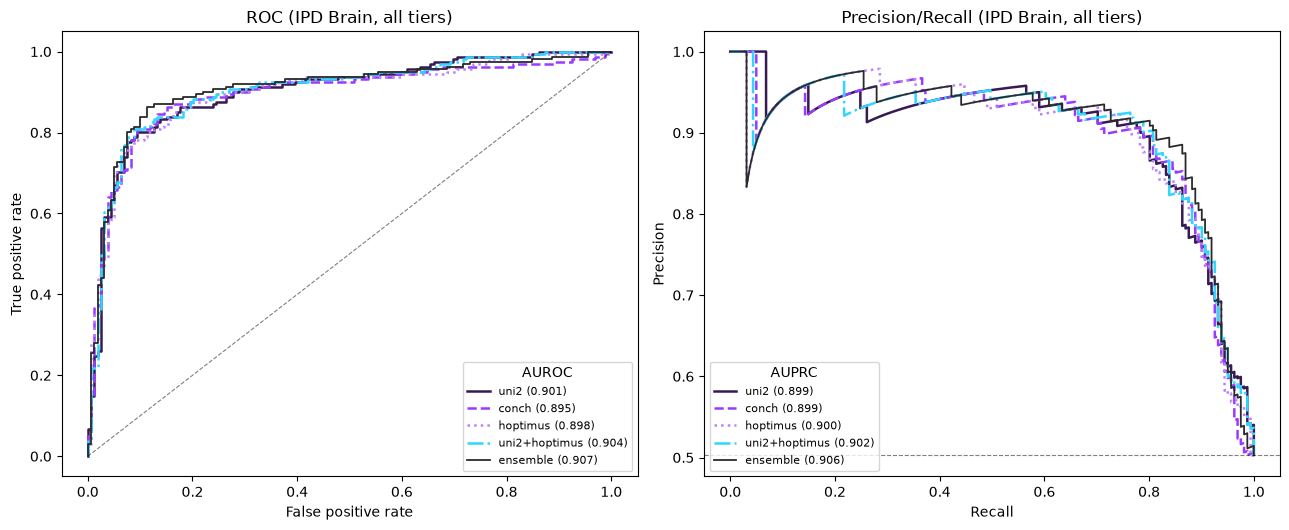

In [ ]:
N_BOOT_B1 = 2000

def run_baseline_table(frame, label_suffix=""):
    rows_fmt, rows_num, curve_data = [], [], {}
    for pname, cols in PREDICTORS.items():
        thr = OP_THRESHOLD_BY_PRED[pname]
        scored = predictor_scores(frame, cols)
        y = scored["label"].to_numpy(int); p = scored["prob_mutant"].to_numpy(float)
        point, ci = bootstrap_metrics(y, p, thr, n_boot=N_BOOT_B1,
                                       seed=RNG_SEED + stable_seed(pname, label_suffix))
        curve_data[pname] = (y, p)
        fmt = {"predictor": pname, "n": point["n"], "prevalence": round(point["prevalence"], 3),
               "threshold": round(thr, 3)}
        num = {"predictor": pname, "n": point["n"], "prevalence": point["prevalence"], "threshold": thr}
        for k in METRIC_KEYS:
            lo, hi = ci[k]
            fmt[k] = f"{point[k]:.3f} [{lo:.3f}, {hi:.3f}]"
            num[k], num[f"{k}_lo"], num[f"{k}_hi"] = point[k], lo, hi
        rows_fmt.append(fmt); rows_num.append(num)
    return pd.DataFrame(rows_fmt).set_index("predictor"), pd.DataFrame(rows_num).set_index("predictor"), curve_data

baseline_fmt, baseline_num, curve_data = run_baseline_table(master, "all")
baseline_num.to_csv(OUT_DIR / "baseline_overall_metrics_all_tiers.csv")

print(f"IPD Brain baseline performance | n={len(master)} | "
      f"IDH-mutant prevalence={master['label'].mean():.3f}\n")
display(baseline_fmt.T)

UCL_CURVE_STYLE = {
    "uni2":          dict(color="#361a54", ls="-"),            # dark purple, solid
    "conch":         dict(color="#993bff", ls="--"),           # bright purple, dashed
    "hoptimus":      dict(color="#ba82ff", ls=":"),             # mid purple, dotted
    "uni2+hoptimus": dict(color="#30d6ff", ls="-."),            # heritage blue, dash-dot
    "ensemble":      dict(color="#2a2a2a", ls="-", lw=1.3),    # dark grey, thin solid (aggregate)
}
R1_FIG_DIR = BASE / "outputs/r1_figures"
R1_FIG_DIR.mkdir(parents=True, exist_ok=True)

prev = float(master["label"].mean())
fig, ax = plt.subplots(1, 2, figsize=(13, 5.4))
for pname, (y, p) in curve_data.items():
    style = UCL_CURVE_STYLE[pname]
    fpr, tpr, _ = roc_curve(y, p)
    prec, rec, _ = precision_recall_curve(y, p)
    ax[0].plot(fpr, tpr, lw=style.get("lw", 1.8), color=style["color"], linestyle=style["ls"],
               label=f"{pname} ({baseline_num.loc[pname,'auroc']:.3f})")
    ax[1].plot(rec, prec, lw=style.get("lw", 1.8), color=style["color"], linestyle=style["ls"],
               label=f"{pname} ({baseline_num.loc[pname,'auprc']:.3f})")
ax[0].plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
ax[0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC (IPD Brain, all tiers)")
ax[0].legend(loc="lower right", fontsize=8, title="AUROC")
ax[1].axhline(prev, ls="--", color="k", lw=0.8, alpha=0.5)
ax[1].set(xlabel="Recall", ylabel="Precision", title="Precision/Recall (IPD Brain, all tiers)")
ax[1].legend(loc="lower left", fontsize=8, title="AUPRC")
plt.tight_layout()
plt.savefig(R1_FIG_DIR / "ipd_brain_roc_pr_curves.pdf")
plt.show()


### B2 (IPD Brain). Paired bootstrap comparison of the five locked predictors

Mirrors the main TCGA bench's own B2: one shared resample scores all five
predictors, preserving cross-predictor correlation, same primary/support metric
split, same BH-FDR correction within the primary family, applied here to the full
IPD Brain cohort (n=320, all tiers) with the TCGA-locked thresholds already used
throughout Part B. Needed specifically because E1's point estimates put the full
ensemble's AUROC (0.907) above UNI2's (0.901), the opposite ranking from TCGA
(where UNI2 significantly beat the ensemble); this checks whether that reordering
is a real, testable difference or noise at this smaller n.

In [ ]:
from itertools import combinations

N_BOOT_B2_IPD = 5000
PRIMARY_METRICS = ["auroc", "auprc", "brier", "ece"]
SUPPORT_METRICS = ["sensitivity", "npv"]
LOWER_BETTER    = {"brier", "ece"}
track = PRIMARY_METRICS + SUPPORT_METRICS
pred_names = list(PREDICTORS.keys())

Y   = master["label"].to_numpy(int)
P   = {pn: predictor_scores(master, cols)["prob_mutant"].to_numpy(float)
       for pn, cols in PREDICTORS.items()}
THR = {pn: OP_THRESHOLD_BY_PRED[pn] for pn in pred_names}

rng = np.random.default_rng(RNG_SEED)
samp = {pn: {k: [] for k in track} for pn in pred_names}
n_used = 0
for _ in range(N_BOOT_B2_IPD):
    bi = _strat_idx(Y, rng)
    if len(np.unique(Y[bi])) < 2:
        continue
    n_used += 1
    for pn in pred_names:
        m = binary_metrics(Y[bi], P[pn][bi], THR[pn])
        for k in track:
            samp[pn][k].append(m[k])
samp = {pn: {k: np.asarray(v) for k, v in d.items()} for pn, d in samp.items()}
print(f"IPD Brain paired bootstrap: {n_used}/{N_BOOT_B2_IPD} usable resamples")

def boot_p_two_sided(d):
    nb_ = len(d)
    return min(1.0, 2 * min((np.sum(d <= 0) + 1) / (nb_ + 1),
                            (np.sum(d >= 0) + 1) / (nb_ + 1)))

def bh_fdr(p):
    p = np.asarray(p, float); n = len(p); order = np.argsort(p)
    q = p[order] * n / (np.arange(1, n + 1))
    q = np.clip(np.minimum.accumulate(q[::-1])[::-1], 0, 1)
    out = np.empty(n); out[order] = q
    return out

rows = []
for a, b in combinations(pred_names, 2):
    for k in track:
        d = samp[a][k] - samp[b][k]
        lo, hi = np.quantile(d, [0.025, 0.975])
        rows.append({"a": a, "b": b, "metric": k,
                     "delta": float(baseline_num.loc[a, k] - baseline_num.loc[b, k]),
                     "ci_low": float(lo), "ci_high": float(hi),
                     "p_raw": float(boot_p_two_sided(d)),
                     "family": "primary" if k in PRIMARY_METRICS else "support"})
contrasts_ipd = pd.DataFrame(rows)
prim = contrasts_ipd["family"] == "primary"
contrasts_ipd["p_fdr"] = np.nan
contrasts_ipd.loc[prim, "p_fdr"] = bh_fdr(contrasts_ipd.loc[prim, "p_raw"].to_numpy())
contrasts_ipd["sig_fdr"] = contrasts_ipd["p_fdr"] < 0.05
contrasts_ipd.to_csv(OUT_DIR / "baseline_paired_contrasts.csv", index=False)

def line(r):
    star = "*" if (r["family"] == "primary" and r["sig_fdr"]) else " "
    p = f"q={r['p_fdr']:.3f}" if r["family"] == "primary" else f"p={r['p_raw']:.3f}(raw)"
    return (f"{star} {r['a']:>13s} - {r['b']:<13s} {r['metric']:>6s}: "
            f"{r['delta']:+.4f} [{r['ci_low']:+.4f}, {r['ci_high']:+.4f}]  {p}")

print("\nPrimary contrasts (BH-FDR; * = q<0.05):")
for _, r in contrasts_ipd[prim].loc[contrasts_ipd[prim]["p_fdr"].sort_values().index].iterrows():
    print(line(r))
print("\nSupporting (own-threshold operating points; uncorrected):")
for _, r in contrasts_ipd[~prim].iterrows():
    print(line(r))

print("\nEnsemble vs UNI2 (does IPD Brain's point-estimate reordering survive testing?):")
for k in PRIMARY_METRICS:
    row = contrasts_ipd[(contrasts_ipd.metric == k) &
                         (((contrasts_ipd.a == "ensemble") & (contrasts_ipd.b == "uni2")) |
                          ((contrasts_ipd.a == "uni2") & (contrasts_ipd.b == "ensemble")))].iloc[0]
    s = 1.0 if row["a"] == "ensemble" else -1.0
    lo, hi = sorted([s * row["ci_low"], s * row["ci_high"]])
    print(f"  {k:>6s}: {s*row['delta']:+.4f} [{lo:+.4f}, {hi:+.4f}]  "
          f"q={row['p_fdr']:.3f} {'*' if row['sig_fdr'] else ''}")


IPD Brain paired bootstrap: 5000/5000 usable resamples

Primary contrasts (BH-FDR; * = q<0.05):
*         conch - hoptimus         ece: -0.0480 [-0.0688, -0.0182]  q=0.005
*      hoptimus - ensemble       brier: +0.0205 [+0.0107, +0.0308]  q=0.005
* uni2+hoptimus - ensemble       brier: +0.0104 [+0.0046, +0.0167]  q=0.005
*      hoptimus - ensemble         ece: +0.0226 [+0.0110, +0.0423]  q=0.024
*      hoptimus - uni2+hoptimus  brier: +0.0101 [+0.0027, +0.0176]  q=0.037
*         conch - uni2+hoptimus    ece: -0.0412 [-0.0584, -0.0103]  q=0.037
  uni2+hoptimus - ensemble         ece: +0.0158 [+0.0042, +0.0305]  q=0.085
          conch - hoptimus       brier: -0.0226 [-0.0416, -0.0036]  q=0.086
           uni2 - conch            ece: +0.0374 [+0.0043, +0.0551]  q=0.089
           uni2 - ensemble       brier: +0.0095 [+0.0012, +0.0183]  q=0.089
          conch - ensemble       auroc: -0.0122 [-0.0233, -0.0016]  q=0.089
          conch - ensemble         ece: -0.0254 [-0.0370, +0.0024]  

### Locked threshold vs. hypothetically-recalibrated threshold

This is a secondary, exploratory comparison, not a replacement for the
locked-threshold result above. AUROC/AUPRC/Brier/ECE are threshold-free and
already identical either way: they measure whether the model discriminates
IDH-mutant from wildtype at all, which the locked-threshold table above already
answers honestly. What a locked threshold can hide is a pure calibration problem:
good ranking, wrong cutoff for this population's prevalence/acquisition
characteristics. Refitting Youden's J directly on IPD Brain's own labels and
comparing sensitivity/specificity/PPV/NPV/accuracy at that hypothetical cutoff
separates "the model doesn't work here" from "the model works here but needs the
cutoff moved."

Fit/held-out split, not a single in-sample fit-and-evaluate. Fitting Youden's J
and then evaluating it on the same data is optimistically biased, even for
something as simple as a single scalar cutoff, so the recalibrated threshold is
fit on a stratified 70% subset of Level A only, and every metric below (both
thresholds, for a fair comparison) is evaluated on the held-out 30% of Level A
plus all 8 Level C patients, none of whom enter the fitting set. This costs
sample size: the eval set here is a subset of the full 320, so its CIs are wider
than the primary locked-threshold table's.

Locked and recalibrated are scored on the exact same held-out patients, so
"barely moves" needs a paired test, not two independent CIs. The two thresholds
aren't being compared across different samples: every metric below is computed
twice on the identical n=102 eval set, just with a different cutoff applied to
the same probabilities. Reporting two separate bootstrap CIs throws away that
pairing and overstates how uncertain the difference actually is, the same issue
Part C's paired tier test exists to avoid below, so the comparison here uses a
shared-resample paired bootstrap instead: one resample of the eval set per
iteration, both thresholds' metrics computed on that same resample, the paired
difference is what gets a CI and p-value.

In [ ]:
from sklearn.model_selection import train_test_split

def pick_threshold_youden(y, p):
    fpr, tpr, thr = roc_curve(y, p)
    return float(thr[np.argmax(tpr - fpr)])

labels_full = master["label"].to_numpy()
clean_mask = (master["level"] != "C").to_numpy()
ab_positions = np.flatnonzero(clean_mask)
c_positions = np.flatnonzero(~clean_mask)

fit_positions, held_ab_positions = train_test_split(
    ab_positions, test_size=0.3, stratify=labels_full[ab_positions], random_state=RNG_SEED
)
eval_positions = np.concatenate([held_ab_positions, c_positions])

print(f"Threshold-fitting set: n={len(fit_positions)} (stratified 70% of A+B, Level C never included)")
print(f"Held-out evaluation set: n={len(eval_positions)} "
      f"({len(held_ab_positions)} held-out A+B + {len(c_positions)} Level C, "
      f"none of it used for fitting)\n")

N_BOOT_RECAL_PAIRED = 2000
PAIRED_THR_METRICS = ["accuracy", "sensitivity", "specificity", "balanced_accuracy", "ppv", "npv"]

def paired_threshold_diff(y, p, thr_a, thr_b, n_boot, seed):
    obs = {k: binary_metrics(y, p, thr_a)[k] - binary_metrics(y, p, thr_b)[k] for k in PAIRED_THR_METRICS}
    rng = np.random.default_rng(seed)
    diffs = {k: [] for k in PAIRED_THR_METRICS}
    for _ in range(n_boot):
        bi = rng.integers(0, len(y), len(y))
        yb, pb = y[bi], p[bi]
        if len(np.unique(yb)) < 2:
            continue
        ma, mb = binary_metrics(yb, pb, thr_a), binary_metrics(yb, pb, thr_b)
        for k in PAIRED_THR_METRICS:
            diffs[k].append(ma[k] - mb[k])
    out = {}
    for k in PAIRED_THR_METRICS:
        d = np.asarray(diffs[k], float); d = d[np.isfinite(d)]
        if not len(d):
            out[k] = {"diff": obs[k], "lo": np.nan, "hi": np.nan, "p": np.nan}
            continue
        lo, hi = np.percentile(d, [2.5, 97.5])
        p_ = min(1.0, 2 * min((d <= 0).mean(), (d >= 0).mean()))
        out[k] = {"diff": obs[k], "lo": float(lo), "hi": float(hi), "p": float(p_)}
    return out

recal_rows = []
recal_test_rows = []
for pname, cols in PREDICTORS.items():
    scored = predictor_scores(master, cols)
    y_all = scored["label"].to_numpy(int); p_all = scored["prob_mutant"].to_numpy(float)

    thr_locked = OP_THRESHOLD_BY_PRED[pname]
    thr_recal = pick_threshold_youden(y_all[fit_positions], p_all[fit_positions])
    thr_recal_contaminated = pick_threshold_youden(y_all, p_all)

    y_eval, p_eval = y_all[eval_positions], p_all[eval_positions]
    point_locked, _ = bootstrap_metrics(y_eval, p_eval, thr_locked, n_boot=N_BOOT_B1,
                                         seed=RNG_SEED + stable_seed(pname, "recal_locked"))
    point_recal, _ = bootstrap_metrics(y_eval, p_eval, thr_recal, n_boot=N_BOOT_B1,
                                        seed=RNG_SEED + stable_seed(pname, "recal_recal"))
    paired = paired_threshold_diff(y_eval, p_eval, thr_recal, thr_locked, N_BOOT_RECAL_PAIRED,
                                   RNG_SEED + stable_seed(pname, "recal_paired"))
    for k, r in paired.items():
        recal_test_rows.append({"predictor": pname, "metric": k, "diff_recal_minus_locked": r["diff"],
                                "lo": r["lo"], "hi": r["hi"], "p": r["p"]})
    recal_rows.append({
        "predictor": pname, "n_eval": len(eval_positions),
        "threshold_locked": thr_locked, "threshold_recalibrated": thr_recal,
        "threshold_recalibrated_if_contaminated_with_level_C_and_no_split": thr_recal_contaminated,
        "sensitivity_locked": point_locked["sensitivity"], "sensitivity_recal": point_recal["sensitivity"],
        "specificity_locked": point_locked["specificity"], "specificity_recal": point_recal["specificity"],
        "balanced_accuracy_locked": point_locked["balanced_accuracy"], "balanced_accuracy_recal": point_recal["balanced_accuracy"],
        "ppv_locked": point_locked["ppv"], "ppv_recal": point_recal["ppv"],
        "npv_locked": point_locked["npv"], "npv_recal": point_recal["npv"],
        "accuracy_locked": point_locked["accuracy"], "accuracy_recal": point_recal["accuracy"],
    })

recal_df = pd.DataFrame(recal_rows).set_index("predictor")
recal_df.to_csv(OUT_DIR / "locked_vs_recalibrated_threshold.csv")

recal_test_df = pd.DataFrame(recal_test_rows)
recal_test_df["q_fdr"] = np.nan
for _metric, idx_ in recal_test_df.groupby("metric").groups.items():
    sub = recal_test_df.loc[idx_]
    recal_test_df.loc[sub.index, "q_fdr"] = bh_fdr(sub["p"].to_numpy())
recal_test_df["sig_fdr"] = recal_test_df["q_fdr"] < 0.05
recal_test_df.to_csv(OUT_DIR / "locked_vs_recalibrated_threshold_paired_test.csv", index=False)

print("Locked vs. properly-held-out-recalibrated threshold, both evaluated on the SAME "
      f"held-out set (n={len(eval_positions)}) -- note this is smaller than, and not directly\n"
      "comparable in absolute terms to, the full-cohort (n=320) locked-threshold table above;\n"
      "wider CIs here are the honest cost of a genuine held-out comparison. Paired-bootstrap\n"
      "significance (recalibrated minus locked, same resampled patients both times), BH-FDR\n"
      "corrected within metric across all 5 predictors, is reported alongside each metric.\n")
for pname in PREDICTORS:
    r = recal_df.loc[pname]
    tsub = recal_test_df[recal_test_df.predictor == pname].set_index("metric")
    contam_shift = abs(r.threshold_recalibrated - r["threshold_recalibrated_if_contaminated_with_level_C_and_no_split"])
    print(f"--- {pname} ---")
    print(f"  threshold:        locked={r.threshold_locked:.4f}   recalibrated(proper split)={r.threshold_recalibrated:.4f}"
          f"   [naive in-sample + Level C included: {r['threshold_recalibrated_if_contaminated_with_level_C_and_no_split']:.4f}, "
          f"shift={contam_shift:.4f}]")
    for label, locked_col, recal_col, key in [
        ("sensitivity", "sensitivity_locked", "sensitivity_recal", "sensitivity"),
        ("specificity", "specificity_locked", "specificity_recal", "specificity"),
        ("balanced_accuracy", "balanced_accuracy_locked", "balanced_accuracy_recal", "balanced_accuracy"),
        ("ppv", "ppv_locked", "ppv_recal", "ppv"),
        ("npv", "npv_locked", "npv_recal", "npv"),
        ("accuracy", "accuracy_locked", "accuracy_recal", "accuracy"),
    ]:
        t = tsub.loc[key]
        star = "*" if bool(t.sig_fdr) else " "
        print(f"  {label:<17s} locked={r[locked_col]:.3f}  recalibrated={r[recal_col]:.3f}   "
              f"diff={t.diff_recal_minus_locked:+.3f}{star} [{t.lo:+.3f},{t.hi:+.3f}] q={t.q_fdr:.3f}")
    print()
print("(* = FDR q<0.05 within metric, across every predictor)")


Threshold-fitting set: n=218 (stratified 70% of A+B, Level C never included)
Held-out evaluation set: n=102 (94 held-out A+B + 8 Level C, none of it used for fitting)

Locked vs. properly-held-out-recalibrated threshold, both evaluated on the SAME held-out set (n=102) -- note this is smaller than, and not directly
comparable in absolute terms to, the full-cohort (n=320) locked-threshold table above;
wider CIs here are the honest cost of a genuine held-out comparison. Paired-bootstrap
significance (recalibrated minus locked, same resampled patients both times), BH-FDR
corrected within metric across all 5 predictors, is reported alongside each metric.

--- uni2 ---
  threshold:        locked=0.7086   recalibrated(proper split)=0.1362   [naive in-sample + Level C included: 0.2778, shift=0.1417]
  sensitivity       locked=0.673  recalibrated=0.898   diff=+0.224* [+0.111,+0.346] q=0.000
  specificity       locked=0.925  recalibrated=0.679   diff=-0.245* [-0.367,-0.128] q=0.000
  balanced_ac

## Part C: baseline performance by label-confidence tier

If the tier system is doing real work, not just a plausible-sounding heuristic,
Level C (case-specific evidence of likely mislabeling) should show materially
different model behaviour than Level A. Reports the same E1 table for two
cohorts: all 320, and Level A only (n=312, excluding the 8 confirmed-likely-
mislabeled Level C cases). Thresholds are the same locked TCGA values throughout;
only the evaluated cohort changes, never the operating point.

In [ ]:
tier_cohorts = {
    "all (A+C, n=320)": master,
    "A (n=312, excl. Level C)": master[master["level"] != "C"],
}

tier_results = {}
for label, cohort in tier_cohorts.items():
    fmt, num, _ = run_baseline_table(cohort, label)
    tier_results[label] = num
    print(f"--- {label} ---")
    display(fmt[["n", "prevalence", "auroc", "auprc", "brier", "ece", "balanced_accuracy"]])
    print()

ens_by_tier = pd.DataFrame({
    label: tier_results[label].loc["ensemble", ["n", "auroc", "auroc_lo", "auroc_hi",
                                                  "brier", "brier_lo", "brier_hi"]]
    for label in tier_cohorts
}).T
ens_by_tier.to_csv(OUT_DIR / "baseline_by_tier_ensemble.csv")
print("Ensemble predictor, AUROC/Brier across tier subsets:")
display(ens_by_tier)

--- all (A+C, n=320) ---


,n,prevalence,auroc,auprc,brier,ece,balanced_accuracy
predictor,,,,,,,
uni2,320,0.503,"0.901 [0.865, 0.934]","0.899 [0.854, 0.939]","0.139 [0.112, 0.167]","0.129 [0.105, 0.162]","0.767 [0.726, 0.807]"
conch,320,0.503,"0.895 [0.857, 0.930]","0.899 [0.853, 0.939]","0.128 [0.103, 0.154]","0.092 [0.076, 0.130]","0.850 [0.813, 0.885]"
hoptimus,320,0.503,"0.898 [0.862, 0.934]","0.900 [0.855, 0.944]","0.151 [0.121, 0.179]","0.140 [0.117, 0.176]","0.838 [0.798, 0.876]"
uni2+hoptimus,320,0.503,"0.904 [0.868, 0.937]","0.902 [0.853, 0.944]","0.140 [0.115, 0.168]","0.133 [0.109, 0.166]","0.823 [0.782, 0.863]"
ensemble,320,0.503,"0.907 [0.870, 0.939]","0.906 [0.859, 0.945]","0.130 [0.106, 0.156]","0.117 [0.095, 0.150]","0.844 [0.807, 0.879]"



--- A (n=312, excl. Level C) ---


,n,prevalence,auroc,auprc,brier,ece,balanced_accuracy
predictor,,,,,,,
uni2,312,0.516,"0.922 [0.890, 0.952]","0.942 [0.920, 0.963]","0.130 [0.105, 0.157]","0.139 [0.112, 0.166]","0.779 [0.742, 0.820]"
conch,312,0.516,"0.912 [0.876, 0.943]","0.935 [0.910, 0.958]","0.120 [0.095, 0.146]","0.109 [0.089, 0.142]","0.868 [0.830, 0.902]"
hoptimus,312,0.516,"0.917 [0.884, 0.949]","0.939 [0.916, 0.962]","0.142 [0.113, 0.170]","0.158 [0.129, 0.189]","0.852 [0.816, 0.891]"
uni2+hoptimus,312,0.516,"0.925 [0.893, 0.952]","0.944 [0.923, 0.964]","0.132 [0.105, 0.159]","0.148 [0.123, 0.178]","0.837 [0.799, 0.875]"
ensemble,312,0.516,"0.926 [0.894, 0.955]","0.947 [0.925, 0.967]","0.121 [0.098, 0.146]","0.135 [0.110, 0.161]","0.859 [0.822, 0.894]"



Ensemble predictor, AUROC/Brier across tier subsets:


,n,auroc,auroc_lo,auroc_hi,brier,brier_lo,brier_hi
"all (A+C, n=320)",320.0,0.906871,0.869754,0.938594,0.129989,0.106391,0.156419
"A (n=312, excl. Level C)",312.0,0.926494,0.894033,0.954879,0.121316,0.098083,0.145991


### Proper paired test between the tier cohorts

Why the naive comparison above isn't a valid significance test. All (n=320) and A
(n=312) are nested, not independent: A is a subset of All, and 312 of the 320
patients are literally identical between the two. Treating their bootstrap CIs as
independent samples (the way a normal subgroup contrast would) ignores that
shared overlap and overstates the uncertainty of the difference; most of each
CI's width comes from sampling variation common to both cohorts, which cancels
out when you compare them properly.

The correct approach: draw one stratified bootstrap resample of the full
320-patient cohort per iteration, then compute AUROC on that same resample two
ways, using every resampled patient and using only the resampled patients whose
tier isn't C, so the correlation between the two numbers is preserved rather than
discarded. The paired difference per iteration is what gets a CI and a two-sided
p-value, not each cohort's AUROC separately.

In [ ]:
N_BOOT_TIER_PAIRED = 2000

def paired_tier_test(frame, cols, thr, seed):
    """Shared-resample paired bootstrap: draws once from the full cohort,
    then restricts to the Level-A (excl. Level C) subset within that same
    draw."""
    scored = predictor_scores(frame, cols)
    y_all = scored["label"].to_numpy(int)
    p_all = scored["prob_mutant"].to_numpy(float)
    level = frame["level"].to_numpy()
    is_a = level != "C"

    def safe_auroc(y, p):
        return roc_auc_score(y, p) if len(y) >= 10 and len(np.unique(y)) > 1 else np.nan

    obs_all = safe_auroc(y_all, p_all)
    obs_a = safe_auroc(y_all[is_a], p_all[is_a])

    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(N_BOOT_TIER_PAIRED):
        bi = _strat_idx(y_all, rng)
        yb, pb = y_all[bi], p_all[bi]
        a_b = is_a[bi]
        auroc_all = safe_auroc(yb, pb)
        auroc_a = safe_auroc(yb[a_b], pb[a_b])
        if not (np.isfinite(auroc_all) and np.isfinite(auroc_a)):
            continue
        diffs.append(auroc_all - auroc_a)

    out = {"auroc_all": obs_all, "auroc_A": obs_a}
    d = np.asarray(diffs, float)
    obs_diff = obs_all - obs_a
    lo, hi = np.percentile(d, [2.5, 97.5]) if len(d) else (np.nan, np.nan)
    p = (min(1.0, 2 * min((d <= 0).mean(), (d >= 0).mean())) if len(d) else np.nan)
    mde = float(Z_MDE * d.std()) if len(d) else np.nan
    out["diff_all-A"] = obs_diff
    out["diff_all-A_mde"] = mde
    out["diff_all-A_lo"] = lo
    out["diff_all-A_hi"] = hi
    out["diff_all-A_p"] = p
    out["diff_all-A_n_boot"] = len(d)
    return out

paired_rows = []
for pname, cols in PREDICTORS.items():
    thr = OP_THRESHOLD_BY_PRED[pname]
    r = paired_tier_test(master, cols, thr, RNG_SEED + stable_seed(pname, "tier_paired"))
    r["predictor"] = pname
    paired_rows.append(r)
paired_df = pd.DataFrame(paired_rows).set_index("predictor")

# BH-FDR across the 1 contrast x 5 predictors = 5 tests
paired_df["diff_all-A_q"] = bh_fdr(paired_df["diff_all-A_p"].to_numpy())
paired_df.to_csv(OUT_DIR / "tier_paired_test.csv")

print("Paired bootstrap test, nested tier cohorts (shared resample, BH-FDR across 5 tests)\n")
print("--- All (320) vs A (312, excl. Level C) ---")
for pname in PREDICTORS:
    r = paired_df.loc[pname]
    star = "*" if r["diff_all-A_q"] < 0.05 else " "
    print(f"  {star} {pname:>13s}: diff={r['diff_all-A']:+.4f} "
          f"[{r['diff_all-A_lo']:+.4f}, {r['diff_all-A_hi']:+.4f}]  "
          f"p={r['diff_all-A_p']:.3f}  q={r['diff_all-A_q']:.3f}  "
          f"MDE={r['diff_all-A_mde']:.4f}")
print()
print("(* = FDR q<0.05 across all 5 tier-cohort tests. Positive diff means")
print(" the full cohort has HIGHER AUROC than the Level-C-excluded one.)")

Paired bootstrap test, nested tier cohorts (shared resample, BH-FDR across 5 tests)

--- All (320) vs A (312, excl. Level C) ---
  *          uni2: diff=-0.0209 [-0.0413, -0.0053]  p=0.005  q=0.005  MDE=0.0262
  *         conch: diff=-0.0171 [-0.0360, -0.0030]  p=0.003  q=0.005  MDE=0.0233
  *      hoptimus: diff=-0.0188 [-0.0373, -0.0049]  p=0.003  q=0.005  MDE=0.0236
  * uni2+hoptimus: diff=-0.0203 [-0.0398, -0.0048]  p=0.004  q=0.005  MDE=0.0255
  *      ensemble: diff=-0.0196 [-0.0390, -0.0044]  p=0.002  q=0.005  MDE=0.0251

(* = FDR q<0.05 across all 5 tier-cohort tests. Positive diff means
 the full cohort has HIGHER AUROC than the Level-C-excluded one.)


### C.3: Level A prevalence, and a label-noise robustness check

Two numbers referenced directly in R3a: (1) Level A's own IDH-mutant prevalence,
materially higher than the all-tiers figure reported in the cohort-characteristics
table (Level C is wildtype-only by construction, so pooling it in dilutes the
headline number), relevant context for interpreting the TCGA/IPD Brain
threshold-transfer finding; (2) whether restricting to Level A's reliable labels
changes AUROC much from the full cohort, a robustness check against label noise as
an alternative explanation for R3a's headline finding.

Self-contained: only needs Section 0's config/imports cell (`BASE`, `OUT_DIR`,
`pd`, `np`), no dependency on any analysis cell above.

In [55]:
from sklearn.metrics import roc_auc_score

_lvl_df = pd.read_csv(BASE / "outputs/ipd_brain_baseline_bench/master_patient_table.csv")

prevalence_by_tier = _lvl_df.groupby("level")["label"].agg(n="size", prevalence="mean").reset_index()
prevalence_by_tier.loc[len(prevalence_by_tier)] = ["all_tiers", len(_lvl_df), _lvl_df["label"].mean()]
prevalence_by_tier.to_csv(OUT_DIR / "prevalence_by_tier.csv", index=False)

_level_a = _lvl_df[_lvl_df.level == "A"]
_auroc_rows = []
for pred in ["uni2", "conch", "hoptimus", "ensemble"]:
    col = "prob_mutant" if pred == "ensemble" else f"prob_mutant_{pred}"
    full_auroc = roc_auc_score(_lvl_df["label"], _lvl_df[col])
    a_auroc = roc_auc_score(_level_a["label"], _level_a[col])
    _auroc_rows.append({"predictor": pred, "full_auroc": full_auroc,
                         "level_a_auroc": a_auroc, "diff": a_auroc - full_auroc})
level_a_auroc_check = pd.DataFrame(_auroc_rows)
level_a_auroc_check.to_csv(OUT_DIR / "level_a_only_vs_full_cohort_auroc.csv", index=False)

print("Prevalence by tier:")
print(prevalence_by_tier.round(4).to_string(index=False))
print("\nLevel-A-only vs. full-cohort AUROC (label-noise robustness check):")
print(level_a_auroc_check.round(4).to_string(index=False))


Prevalence by tier:
    level   n  prevalence
        A 312      0.5160
        C   8      0.0000
all_tiers 320      0.5031

Level-A-only vs. full-cohort AUROC (label-noise robustness check):
predictor  full_auroc  level_a_auroc   diff
     uni2      0.9011         0.9220 0.0209
    conch      0.8947         0.9118 0.0171
 hoptimus      0.8984         0.9172 0.0188
 ensemble      0.9069         0.9265 0.0196


### C.3c: does the label-noise robustness check survive also excluding the age<55 wildtype group?

C.3 above tests Level A (excl. Level C only, n=312) against the full cohort and
finds a significant AUROC gain, but this project separately identifies a second
group whose wildtype labels carry real, if unquantified, risk of a missed
non-canonical IDH mutation: patients under 55 of any WHO grade, per the age-55
cutoff for trusting a negative R132H IHC result without reflex sequencing,
applied across all grades (see `shift_weighted_conformal_ipd_brain_extension.ipynb`,
which excludes this same group from scoring for that reason).

In [86]:
N_BOOT_TIER_PAIRED2 = 2000
YOUNG_WT_BANDS = {"<20", "20-39", "40-54"}

young_wt_mask_r1 = (master["level"] == "A") & (master["label"] == 0) & (master["age_band"].isin(YOUNG_WT_BANDS))
is_a_excl_young_wt = (master["level"] != "C").to_numpy() & (~young_wt_mask_r1).to_numpy()
print(f"Level A excluding age<55 wildtype: n={int(is_a_excl_young_wt.sum())} "
      f"(full n={len(master)}, Level A n={int((master.level=='A').sum())}, "
      f"minus {int(young_wt_mask_r1.sum())} age<55 wildtype)")


def paired_tier_test_excl_young(frame, cols, thr, seed):
    """Same paired-bootstrap design as paired_tier_test above (C.3's own
    all-vs-Level-A test), restricted further to exclude the age<55
    wildtype group too."""
    scored = predictor_scores(frame, cols)
    y_all = scored["label"].to_numpy(int)
    p_all = scored["prob_mutant"].to_numpy(float)
    is_a2 = is_a_excl_young_wt

    def safe_auroc(y, p):
        return roc_auc_score(y, p) if len(y) >= 10 and len(np.unique(y)) > 1 else np.nan

    obs_all = safe_auroc(y_all, p_all)
    obs_a2 = safe_auroc(y_all[is_a2], p_all[is_a2])

    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(N_BOOT_TIER_PAIRED2):
        bi = _strat_idx(y_all, rng)
        yb, pb = y_all[bi], p_all[bi]
        a2_b = is_a2[bi]
        auroc_all = safe_auroc(yb, pb)
        auroc_a2 = safe_auroc(yb[a2_b], pb[a2_b])
        if not (np.isfinite(auroc_all) and np.isfinite(auroc_a2)):
            continue
        diffs.append(auroc_all - auroc_a2)

    d = np.asarray(diffs, float)
    obs_diff = obs_all - obs_a2
    lo, hi = np.percentile(d, [2.5, 97.5]) if len(d) else (np.nan, np.nan)
    p = (min(1.0, 2 * min((d <= 0).mean(), (d >= 0).mean())) if len(d) else np.nan)
    mde = float(Z_MDE * d.std()) if len(d) else np.nan
    return {
        "auroc_all": obs_all, "auroc_A_excl_young_wt": obs_a2,
        "diff_all-A_excl_young_wt": obs_diff, "diff_all-A_excl_young_wt_mde": mde,
        "diff_all-A_excl_young_wt_lo": lo, "diff_all-A_excl_young_wt_hi": hi,
        "diff_all-A_excl_young_wt_p": p, "diff_all-A_excl_young_wt_n_boot": len(d),
    }


paired_rows2 = []
for pname, cols in PREDICTORS.items():
    thr = OP_THRESHOLD_BY_PRED[pname]
    r = paired_tier_test_excl_young(master, cols, thr, RNG_SEED + stable_seed(pname, "tier_paired_excl_young"))
    r["predictor"] = pname
    paired_rows2.append(r)
paired_df2 = pd.DataFrame(paired_rows2).set_index("predictor")

paired_df2["diff_all-A_excl_young_wt_q"] = bh_fdr(paired_df2["diff_all-A_excl_young_wt_p"].to_numpy())
paired_df2.to_csv(OUT_DIR / "tier_paired_test_excl_young_wt.csv")

print("\nPaired bootstrap test: all (320) vs Level A excluding age<55 wildtype "
      f"(n={int(is_a_excl_young_wt.sum())}), BH-FDR across 5 tests\n")
for pname in PREDICTORS:
    r = paired_df2.loc[pname]
    star = "*" if r["diff_all-A_excl_young_wt_q"] < 0.05 else " "
    print(f"  {star} {pname:>13s}: diff={r['diff_all-A_excl_young_wt']:+.4f} "
          f"[{r['diff_all-A_excl_young_wt_lo']:+.4f}, {r['diff_all-A_excl_young_wt_hi']:+.4f}]  "
          f"p={r['diff_all-A_excl_young_wt_p']:.3f}  q={r['diff_all-A_excl_young_wt_q']:.3f}  "
          f"MDE={r['diff_all-A_excl_young_wt_mde']:.4f}")
print()
print("(* = FDR q<0.05 across all 5 tests. Positive diff means the full")
print(" cohort has HIGHER AUROC than the further-excluded one.)")

Level A excluding age<55 wildtype: n=233 (full n=320, Level A n=312, minus 79 age<55 wildtype)

Paired bootstrap test: all (320) vs Level A excluding age<55 wildtype (n=233), BH-FDR across 5 tests

             uni2: diff=-0.0249 [-0.0489, -0.0040]  p=0.022  q=0.065  MDE=0.0332
            conch: diff=-0.0131 [-0.0375, +0.0077]  p=0.250  q=0.250  MDE=0.0322
         hoptimus: diff=-0.0221 [-0.0462, -0.0010]  p=0.041  q=0.068  MDE=0.0324
    uni2+hoptimus: diff=-0.0237 [-0.0492, -0.0018]  p=0.026  q=0.065  MDE=0.0332
         ensemble: diff=-0.0188 [-0.0419, +0.0018]  p=0.076  q=0.095  MDE=0.0316

(* = FDR q<0.05 across all 5 tests. Positive diff means the full
 cohort has HIGHER AUROC than the further-excluded one.)


### C.3b: does the deferral pattern itself survive on Level-A-only patients?

C.3 above checks whether the full-cohort AUROC baseline is distorted by label
noise from Level C. That comparison never applies deferral, so it says nothing
about whether the retained-vs-full AUROC/accuracy divergence reported in R3a
survives once the label-noisy tier is excluded. This cell re-runs the same
TCGA-locked, transported cutoff (ensemble predictor, predictive family)
restricted to Level-A-only patients, and also reports the confidently-wrong
retained-error rate on that subset, the same way Table~\ref{tab:r3a-mechanism}
does for the full cohort.

In [56]:
_master_c3b = pd.read_csv(MASTER_CSV)
_level_a_c3b = _master_c3b[_master_c3b.level == "A"].copy()

_tcga_cut_c3b = pd.read_csv(TCGA_BENCH_OUT / "selective_metrics_cal_locked_all_fdr.csv")
_ens_pred_cutoffs = (_tcga_cut_c3b[(_tcga_cut_c3b.predictor == "ensemble") & (_tcga_cut_c3b.family == "predictive")]
                     .drop_duplicates("target_coverage")
                     .set_index("target_coverage")[["signal", "calibration_cutoff"]])

_thr_locked_c3b = pd.read_csv(OUT_DIR / "locked_vs_recalibrated_threshold.csv")
_cls_thr_c3b = float(_thr_locked_c3b.loc[_thr_locked_c3b.predictor == "ensemble", "threshold_locked"].iloc[0])


def _level_a_deferral_row(pop, target_cov):
    y = pop["label"].to_numpy(int)
    p = pop["prob_mutant"].to_numpy(float)
    ent = pop["ensemble_entropy"].to_numpy(float)
    cutoff = float(_ens_pred_cutoffs.loc[target_cov, "calibration_cutoff"])

    full_auroc = roc_auc_score(y, p)
    pred_cls = (p >= _cls_thr_c3b).astype(int)
    full_acc = (pred_cls == y).mean()
    is_err = pred_cls != y
    confidently_wrong = is_err & (np.abs(p - 0.5) > 0.3)

    keep = ent <= cutoff
    ret_auroc = roc_auc_score(y[keep], p[keep])
    ret_acc = (pred_cls[keep] == y[keep]).mean()
    n_err_ret = int((is_err & keep).sum())
    n_cw_ret = int((confidently_wrong & keep).sum())
    pct_cw_ret = 100 * n_cw_ret / max(1, n_err_ret)

    return {
        "target_coverage": target_cov, "n": len(pop), "n_retained": int(keep.sum()),
        "achieved_coverage": float(keep.mean()),
        "full_auroc": full_auroc, "retained_auroc": ret_auroc, "d_auroc": ret_auroc - full_auroc,
        "full_accuracy": full_acc, "retained_accuracy": ret_acc, "d_accuracy": ret_acc - full_acc,
        "n_retained_errors": n_err_ret, "pct_retained_errors_confidently_wrong": pct_cw_ret,
    }


level_a_deferral_check = pd.DataFrame([
    _level_a_deferral_row(_level_a_c3b, cov) for cov in (0.9, 0.8, 0.7)
])
level_a_deferral_check.to_csv(OUT_DIR / "level_a_only_deferral_pattern.csv", index=False)

print("Level-A-only (n=244): same locked ensemble+predictive deferral -- does the pattern hold?")
print(level_a_deferral_check.round(4).to_string(index=False))

Level-A-only (n=244): same locked ensemble+predictive deferral -- does the pattern hold?
 target_coverage   n  n_retained  achieved_coverage  full_auroc  retained_auroc  d_auroc  full_accuracy  retained_accuracy  d_accuracy  n_retained_errors  pct_retained_errors_confidently_wrong
             0.9 312         265             0.8494      0.9265          0.9222  -0.0042         0.8558             0.8830      0.0272                 31                                67.7419
             0.8 312         236             0.7564      0.9265          0.9048  -0.0217         0.8558             0.8983      0.0425                 24                                87.5000
             0.7 312         201             0.6442      0.9265          0.8976  -0.0289         0.8558             0.9104      0.0547                 18                               100.0000


### C.3c: age-band class-conditional entropy (replication of TCGA's R4 addendum)

TCGA's own notebook found that its 20-39 age band's excess deferral rate is not
purely compositional (i.e. not just "that band is mutant-heavy, and mutant
patients defer more everywhere," R3a's already-established general effect),
specifically, wildtype patients within the 20-39 band show anomalously elevated
entropy relative to wildtype patients in every other band, nearly matching that
band's own mutant patients, which a pure class-mix account would not predict.
This cell runs the identical check on IPD Brain, an independently-collected
cohort, to see whether that specific pattern replicates or is TCGA-specific.
Self-contained: only needs the master table's `label`, `ensemble_entropy`, and
`age_band` columns, all already present.

In [57]:

_master_c3c = pd.read_csv(MASTER_CSV)
_y_c3c = _master_c3c["label"].to_numpy(int)
_ent_c3c = _master_c3c["ensemble_entropy"].to_numpy(float)
_band_c3c = _master_c3c["age_band"].astype(str).to_numpy()

_rows = [{
    "level": "overall", "n": len(_y_c3c),
    "n_mutant": int((_y_c3c == 1).sum()), "n_wildtype": int((_y_c3c == 0).sum()),
    "mutant_entropy": float(_ent_c3c[_y_c3c == 1].mean()),
    "wildtype_entropy": float(_ent_c3c[_y_c3c == 0].mean()),
}]
for _b in ["20-39", "40-54", "55-69", "70+"]:
    _m = _band_c3c == _b
    if _m.sum() < 5:
        continue
    _ym, _entm = _y_c3c[_m], _ent_c3c[_m]
    _rows.append({
        "level": _b, "n": int(_m.sum()),
        "n_mutant": int((_ym == 1).sum()), "n_wildtype": int((_ym == 0).sum()),
        "mutant_entropy": float(_entm[_ym == 1].mean()) if (_ym == 1).any() else np.nan,
        "wildtype_entropy": float(_entm[_ym == 0].mean()) if (_ym == 0).any() else np.nan,
    })

age_class_entropy_ipd = pd.DataFrame(_rows)
age_class_entropy_ipd["gap"] = age_class_entropy_ipd["mutant_entropy"] - age_class_entropy_ipd["wildtype_entropy"]
age_class_entropy_ipd.to_csv(OUT_DIR / "c3c_age_band_class_conditional_entropy.csv", index=False)

print("Mutant vs. wildtype ensemble_entropy, overall and within each age band (IPD Brain):")
print(age_class_entropy_ipd.round(4).to_string(index=False))
print()
print("Replication check: does 20-39's wildtype entropy stand out above every other")
print("band's wildtype entropy here too, the same way it did on TCGA?")

Mutant vs. wildtype ensemble_entropy, overall and within each age band (IPD Brain):
  level   n  n_mutant  n_wildtype  mutant_entropy  wildtype_entropy    gap
overall 320       161         159          0.4248            0.2412 0.1836
  20-39 104        82          22          0.4414            0.2995 0.1419
  40-54 120        58          62          0.4377            0.2333 0.2044
  55-69  82        16          66          0.2973            0.2269 0.0704
    70+  11         4           7          0.3587            0.2018 0.1569

Replication check: does 20-39's wildtype entropy stand out above every other
band's wildtype entropy here too, the same way it did on TCGA?


## Part D: subgroup analysis: sex, age, label-confidence tier

Same design as the TCGA bench's B3: a closed-form power audit before any result
(sample size alone sets a floor on the smallest detectable gap, independent of
model performance), then the full bootstrap subgroup analysis with BH-FDR
correction within each metric. IPD Brain has no race field, so the axes here are
sex, age band, and label-confidence tier (tier is IPD-Brain-specific, with no
TCGA equivalent), contrasting Level A against Level C, the cleanest single test
of whether Level C behaves differently.

In [ ]:
MIN_SUBGROUP_N = 5   
PRIMARY_D = "ensemble"

BAD_LEVELS = {"unknown", "unclass", "not reported", "nan", "", "none"}
AGE_ORDER = ["<20", "20-39", "40-54", "55-69", "70+"]

AXES = {
    "sex":          {"col": "sex",          "levels": ["female", "male"], "contrasts": [("female", "male")]},
    "age":          {"col": "age_band",     "levels": None, "contrasts": "level_vs_rest"},
    "tier":         {"col": "level",        "levels": ["a", "b", "c"], "contrasts": [("a", "c"), ("b", "c"), ("a", "b")]},
    "tier_grouped": {"col": "tier_grouped", "levels": ["a+b", "c"], "contrasts": [("a+b", "c")]},
}

def resolve_levels(spec, colvals):
    if spec["levels"] is not None:
        return [lv for lv in spec["levels"] if (colvals == lv).sum() >= MIN_SUBGROUP_N]
    present = [v for v in pd.unique(colvals) if v not in BAD_LEVELS]
    if spec["col"] == "age_band":
        present = [a for a in AGE_ORDER if a in present]
    return [lv for lv in present if (colvals == lv).sum() >= MIN_SUBGROUP_N]

def frame_for(pname):
    s = predictor_scores(master, PREDICTORS[pname])
    f = master.copy()
    f["p"] = s["prob_mutant"].to_numpy(float)
    f["y"] = s["label"].to_numpy(int)
    return f

def proportion_mde(n_a, n_b, z=Z_MDE):
    if n_a <= 0 or n_b <= 0:
        return np.nan
    se = np.sqrt(0.25 * (1 / n_a + 1 / n_b))
    return float(z * se)

def auroc_mde_conservative(n0_a, n1_a, n0_b, n1_b, z=Z_MDE):
    if min(n0_a, n1_a) <= 0 or min(n0_b, n1_b) <= 0:
        return np.nan
    var_a = (n0_a + n1_a + 1) / (12 * n0_a * n1_a)
    var_b = (n0_b + n1_b + 1) / (12 * n0_b * n1_b)
    return float(z * np.sqrt(var_a + var_b))

_f_power = frame_for(PRIMARY_D)
power_rows = []
for axis, spec in AXES.items():
    colvals = _f_power[spec["col"]].astype(str).str.lower().to_numpy()
    levels = resolve_levels(spec, colvals)
    masks = {lv: colvals == lv.lower() for lv in levels}

    if spec["contrasts"] == "level_vs_rest":
        valid = np.isin(colvals, [lv.lower() for lv in levels])
        pairs = [(f"{lv} - rest", masks[lv], valid & ~masks[lv]) for lv in levels]
    else:
        pairs = [(f"{a} - {b}", masks[a], masks[b]) for a, b in spec["contrasts"]
                 if a in masks and b in masks]

    for cname, mA, mB in pairs:
        yA, yB = _f_power.loc[mA, "y"].to_numpy(int), _f_power.loc[mB, "y"].to_numpy(int)
        nA, nB = len(yA), len(yB)
        n0A, n1A = int((yA == 0).sum()), int((yA == 1).sum())
        n0B, n1B = int((yB == 0).sum()), int((yB == 1).sum())
        power_rows.append({
            "axis": axis, "contrast": cname, "nA": nA, "nB": nB,
            "mde_proportion": proportion_mde(nA, nB),
            "mde_auroc_conservative": auroc_mde_conservative(n0A, n1A, n0B, n1B),
        })
power_df = pd.DataFrame(power_rows)
power_df["adequate_for_0.05_gap"] = power_df["mde_auroc_conservative"] <= 0.05
power_df.to_csv(OUT_DIR / "subgroup_power_audit.csv", index=False)

print(f"Subgroup power audit -- {PRIMARY_D} cohort, closed-form MDE "
      f"(80% power, alpha=0.05, no bootstrap, model-independent)\n")
hdr = f"{'axis':<13s} {'contrast':<14s} {'nA':>5s} {'nB':>5s} {'MDE(prop)':>10s} {'MDE(AUROC)':>11s} {'>=0.05?':>8s}"
print(hdr); print("-" * len(hdr))
for _, r in power_df.iterrows():
    print(f"{r.axis:<13s} {r.contrast:<14s} {r.nA:>5d} {r.nB:>5d} "
          f"{r.mde_proportion:>10.3f} {r.mde_auroc_conservative:>11.3f} "
          f"{'yes' if r['adequate_for_0.05_gap'] else 'no':>8s}")
n_ok = int(power_df["adequate_for_0.05_gap"].sum())
print(f"\n{n_ok}/{len(power_df)} contrasts adequately powered for a 0.05 AUROC gap.")
print("Contrasts below the bar should be read as underpowered, not as evidence against a gap.")

Subgroup power audit -- ensemble cohort, closed-form MDE (80% power, alpha=0.05, no bootstrap, model-independent)

axis          contrast          nA    nB  MDE(prop)  MDE(AUROC)  >=0.05?
------------------------------------------------------------------------
sex           female - male    134   186      0.159       0.184       no
age           20-39 - rest     104   213      0.168       0.227       no
age           40-54 - rest     120   197      0.162       0.188       no
age           55-69 - rest      82   235      0.180       0.251       no
age           70+ - rest        11   306      0.430       0.537       no
tier          a - c            312     8      0.502         nan       no

0/6 contrasts adequately powered for a 0.05 AUROC gap.
Contrasts below the bar should be read as underpowered, not as evidence against a gap.


In [59]:
MIN_CLASS_N = 3
N_BOOT_D = 2000
RANK_METRICS = ["auroc", "auprc", "bss", "balanced_accuracy"]
NEEDS_BOTH = set(RANK_METRICS) | {"ppv", "npv", "f1"}
SUITE = RANK_METRICS + ["sensitivity", "specificity", "brier", "ece", "cal_gap", "accuracy", "ppv", "npv", "f1"]

def _bss(y, p):
    u = y.mean() * (1 - y.mean())
    return 1 - ((p - y) ** 2).mean() / u if u > 1e-6 else np.nan

def metrics_of(y, p, thr):
    m = binary_metrics(y, p, thr)
    m["bss"] = _bss(y, p)
    m["cal_gap"] = float(p.mean() - y.mean())
    return m

def defined_keys(y):
    n1, n0 = int((y == 1).sum()), int((y == 0).sum())
    keep = []
    for k in SUITE:
        if k in NEEDS_BOTH and min(n0, n1) < MIN_CLASS_N: continue
        if k == "sensitivity" and n1 < MIN_CLASS_N: continue
        if k == "specificity" and n0 < MIN_CLASS_N: continue
        keep.append(k)
    return keep

def subgroup_ci(y, p, thr, seed):
    keys = defined_keys(y)
    point = metrics_of(y, p, thr)
    rng = np.random.default_rng(seed)
    draws = {k: [] for k in keys}
    for _ in range(N_BOOT_D):
        i = rng.integers(0, len(y), len(y))
        if defined_keys(y[i]) != keys:
            continue
        m = metrics_of(y[i], p[i], thr)
        for k in keys:
            draws[k].append(m[k])
    out = {}
    for k in SUITE:
        if k not in keys:
            out[k] = out[f"{k}_lo"] = out[f"{k}_hi"] = np.nan; continue
        v = np.asarray(draws[k], float); v = v[np.isfinite(v)]
        out[k] = point[k]
        out[f"{k}_lo"], out[f"{k}_hi"] = (np.percentile(v, [2.5, 97.5]) if len(v) else (np.nan, np.nan))
    return out

def contrast_ci(yA, pA, yB, pB, thr, seed):
    keys = [k for k in defined_keys(yA) if k in defined_keys(yB)]
    if not keys:
        return {}
    obs = {k: metrics_of(yA, pA, thr)[k] - metrics_of(yB, pB, thr)[k] for k in keys}
    rng = np.random.default_rng(seed)
    boot = {k: [] for k in keys}
    for _ in range(N_BOOT_D):
        a = rng.integers(0, len(yA), len(yA)); b = rng.integers(0, len(yB), len(yB))
        if defined_keys(yA[a]) != defined_keys(yA) or defined_keys(yB[b]) != defined_keys(yB):
            continue
        mA, mB = metrics_of(yA[a], pA[a], thr), metrics_of(yB[b], pB[b], thr)
        for k in keys:
            boot[k].append(mA[k] - mB[k])
    res = {}
    for k in keys:
        d = np.asarray(boot[k], float); d = d[np.isfinite(d)]
        if not len(d):
            res[k] = {"gap": obs[k], "lo": np.nan, "hi": np.nan, "p": np.nan, "mde": np.nan}; continue
        lo, hi = np.percentile(d, [2.5, 97.5])
        p = min(1.0, 2 * min((d <= 0).mean(), (d >= 0).mean()))
        res[k] = {"gap": obs[k], "lo": float(lo), "hi": float(hi), "p": float(p), "mde": float(Z_MDE * d.std())}
    return res

sub_rows, gap_rows = [], []
for pname in PREDICTORS:
    f = frame_for(pname); thr = OP_THRESHOLD_BY_PRED[pname]
    for axis, spec in AXES.items():
        colvals = f[spec["col"]].astype(str).str.lower().to_numpy()
        levels = resolve_levels(spec, colvals)
        masks = {lv: colvals == lv.lower() for lv in levels}

        for lv, m in masks.items():
            y, p = f.loc[m, "y"].to_numpy(int), f.loc[m, "p"].to_numpy(float)
            sub_rows.append({"predictor": pname, "axis": axis, "level": lv, "n": int(m.sum()),
                             "prev": float(y.mean()) if m.sum() else np.nan,
                             **subgroup_ci(y, p, thr, RNG_SEED + stable_seed(pname, lv))})

        if spec["contrasts"] == "level_vs_rest":
            valid = np.isin(colvals, [lv.lower() for lv in levels])
            pairs = [(f"{lv} - rest", masks[lv], valid & ~masks[lv]) for lv in levels]
        else:
            pairs = [(f"{a} - {b}", masks[a], masks[b]) for a, b in spec["contrasts"] if a in masks and b in masks]

        for cname, mA, mB in pairs:
            r = contrast_ci(f.loc[mA, "y"].to_numpy(int), f.loc[mA, "p"].to_numpy(float),
                            f.loc[mB, "y"].to_numpy(int), f.loc[mB, "p"].to_numpy(float),
                            thr, RNG_SEED + stable_seed(cname))
            for k, v in r.items():
                gap_rows.append({"predictor": pname, "axis": axis, "contrast": cname, "metric": k,
                                 "nA": int(mA.sum()), "nB": int(mB.sum()), **v})

sub_df = pd.DataFrame(sub_rows)
gap_df = pd.DataFrame(gap_rows)
gap_df["q_fdr"] = np.nan
for m, idx in gap_df.groupby("metric").groups.items():
    sub = gap_df.loc[idx]; ok = sub["p"].notna()
    gap_df.loc[sub.index[ok], "q_fdr"] = bh_fdr(sub.loc[ok, "p"].to_numpy())
gap_df["sig_fdr"] = gap_df["q_fdr"] < 0.05

sub_df.to_csv(OUT_DIR / "subgroup_descriptives.csv", index=False)
gap_df.to_csv(OUT_DIR / "subgroup_gaps.csv", index=False)

sp = sub_df[sub_df.predictor == PRIMARY_D]
def cell(r, k):
    if not np.isfinite(r[k]): return f"{'-':>17s}"
    return f"{r[k]:>+6.3f}[{r[f'{k}_lo']:>+5.2f},{r[f'{k}_hi']:>+5.2f}]"
print(f"Subgroup descriptives -- {PRIMARY_D} (n>={MIN_SUBGROUP_N} per subgroup)")
hdr = f"{'axis':<13s} {'level':<12s} {'n':>4s} {'prev':>5s}" + "".join(f" {m:>17s}" for m in SUITE)
print(hdr); print("-" * len(hdr))
for axis in AXES:
    for _, r in sp[sp.axis == axis].iterrows():
        print(f"{axis:<13s} {str(r.level)[:11]:<12s} {r.n:>4d} {r.prev:>5.2f}"
              + "".join(" " + cell(r, m) for m in SUITE))

for m in ["auroc", "sensitivity", "specificity", "brier"]:
    gm = gap_df[gap_df.metric == m]
    if gm.empty: continue
    print(f"\n{m} gaps  (* = FDR q<0.05 within metric)")
    for (axis, contrast), sub in gm.groupby(["axis", "contrast"], observed=True):
        print(f"  {axis}  {contrast}")
        sub = sub.set_index("predictor")
        for pred in PREDICTORS:
            if pred not in sub.index: continue
            r = sub.loc[pred]
            star = "*" if r.sig_fdr else " "
            print(f"    {star} {pred:>13s}: {r.gap:+.3f} [{r.lo:+.3f},{r.hi:+.3f}]  q={r.q_fdr:.3f}  MDE={r.mde:.3f}")

Subgroup descriptives -- ensemble (n>=5 per subgroup)
axis          level           n  prev             auroc             auprc               bss balanced_accuracy       sensitivity       specificity             brier               ece           cal_gap          accuracy               ppv               npv                f1
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
sex           female        134  0.48 +0.934[+0.88,+0.97] +0.886[+0.79,+0.97] +0.574[+0.42,+0.71] +0.878[+0.82,+0.93] +0.812[+0.71,+0.91] +0.943[+0.88,+0.99] +0.106[+0.07,+0.14] +0.103[+0.08,+0.17] -0.091[-0.15,-0.04] +0.881[+0.82,+0.93] +0.929[+0.86,+0.98] +0.846[+0.76,+0.93] +0.867[+0.80,+0.93]
sex           male          186  0.52 +0.888[+0.84,+0.94] +0.914[+0.86,+0.95] +0.411[+0.25,+0.55] +0.821

## Part E: uncertainty quantification, strategies and comparisons

Same family definitions, same comparison methodology as
`selective_prediction_bench_clean.ipynb`. Six uncertainty-quantification
families: predictive (cross-fold/cross-encoder disagreement, partially built in
Part A), epistemic (the same decomposition's mutual-information term),
MC-dropout, deep ensemble (8-member init-seed ensemble, seeds 43-50), last-layer
Laplace, and density-based OOD (class-conditional normalizing-flow density,
scored via `scripts/training/ipd_brain_ood_infer.py`, the one family needing its
own dedicated inference stage; OOD is restricted to uni2 and hoptimus, matching
`OOD_ENCODERS` in the main bench, which never scores conch either).

What's new: IPD Brain has a label-confidence tier axis (A vs C) with no
TCGA/EBRAINS equivalent, so every comparison below has tier woven in: does each
uncertainty signal independently rank Level C as riskier (E.4b), and does
deferral behaviour itself differ by tier (E.5), rather than reported only as an
afterthought subgroup cut.

Two threshold/cutoff sources are compared throughout, exactly mirroring Part B's
design: TCGA-transferred (primary, no refitting; calibration cutoffs are loaded
directly from the main bench's own saved
`selective_metrics_cal_locked_all_fdr.csv`, never refit on IPD Brain) and
IPD-Brain-internal recalibrated (secondary, exploratory; fit on the same 70% of
Level A `fit_positions` used for the threshold recalibration above, evaluated on
the same held-out `eval_positions`, so this notebook uses exactly one
fit/held-out split throughout, not a different one per analysis).

### E.0: extending the master table with the full predictive/epistemic decomposition

Part A's `load_abmil_ensemble_ipd_brain()` only computed the pooled
`ensemble_entropy` and per-encoder mean probabilities, enough for Parts B-D, but
the full aleatoric/epistemic decomposition (mirroring the main bench's
`load_abmil_ensemble()`) is needed before `signal_families()` below can populate
the "predictive" and "epistemic" families. Recomputed here from the same
base-pass files Part A already reads, not duplicated logic: same decomposition
identity

In [60]:
PREDICTIVE_EPISTEMIC_COLS_EXPECTED = (
    ["aleatoric", "total_mi", "mean_within_encoder_mi", "between_encoder_mi"]
    + [f"entropy_{e}" for e in ABMIL_ENCODERS]
    + [f"aleatoric_{e}" for e in ABMIL_ENCODERS]
    + [f"within_encoder_mi_{e}" for e in ABMIL_ENCODERS]
)

if all(c in master.columns for c in PREDICTIVE_EPISTEMIC_COLS_EXPECTED):
    print("Predictive/epistemic decomposition columns already present; skipping recomputation.")
else:
    print("Predictive/epistemic decomposition missing; computing from outputs/embeddings/ipd_brain/...")

    frames = []
    for enc in ABMIL_ENCODERS:
        for fold in FOLDS:
            path = BASE / "outputs/embeddings/ipd_brain" / enc / f"fold{fold}.npz"
            if not path.exists():
                print("  WARNING missing", path); continue
            d = np.load(path, allow_pickle=True)
            frames.append(pd.DataFrame({
                "patient": d["patients"].astype(str), "encoder": enc, "fold": fold,
                "prob_mutant": d["probs"][:, 1],
            }))
    allp = pd.concat(frames, ignore_index=True)

    mean_member_entropy = (allp.assign(member_entropy=binary_entropy(allp["prob_mutant"].to_numpy()))
                            .groupby("patient")["member_entropy"].mean()
                            .rename("aleatoric").reset_index())

    decomp = master[["patient", "ensemble_entropy"]].merge(mean_member_entropy, on="patient", how="left")
    decomp["total_mi"] = (decomp["ensemble_entropy"] - decomp["aleatoric"]).clip(lower=0.0)

    within_rows = []
    for (patient, encoder), group in allp.groupby(["patient", "encoder"], sort=False):
        fold_probs = group["prob_mutant"].to_numpy(float)
        mean_prob = np.mean(fold_probs)
        pred_entropy = binary_entropy(mean_prob)
        exp_entropy = np.mean(binary_entropy(fold_probs))
        within_mi = max(float(pred_entropy - exp_entropy), 0.0)
        within_rows.append({"patient": patient, "encoder": encoder,
                             "entropy": float(pred_entropy), "aleatoric_enc": float(exp_entropy),
                             "within_encoder_mi": within_mi})
    within_encoder = pd.DataFrame(within_rows)

    def _pivot(col, prefix):
        return (within_encoder.pivot(index="patient", columns="encoder", values=col)
                .add_prefix(prefix).reset_index())

    within_mi_wide = _pivot("within_encoder_mi", "within_encoder_mi_")
    entropy_wide = _pivot("entropy", "entropy_")
    aleatoric_wide = _pivot("aleatoric_enc", "aleatoric_")

    mean_within = (within_encoder.groupby("patient")["within_encoder_mi"].mean()
                   .rename("mean_within_encoder_mi").reset_index())

    encoder_means = allp.groupby(["patient", "encoder"], as_index=False)["prob_mutant"].mean()
    between_rows = []
    for patient, group in encoder_means.groupby("patient", sort=False):
        probs = group["prob_mutant"].to_numpy(float)
        mean_prob = np.mean(probs)
        between_entropy = binary_entropy(mean_prob)
        mean_enc_entropy = np.mean(binary_entropy(probs))
        between_mi = max(float(between_entropy - mean_enc_entropy), 0.0)
        between_rows.append({"patient": patient, "between_encoder_mi": between_mi})
    between_encoder = pd.DataFrame(between_rows)

    new_cols = (decomp[["patient", "aleatoric", "total_mi"]]
                .merge(within_mi_wide, on="patient", how="left")
                .merge(entropy_wide, on="patient", how="left")
                .merge(aleatoric_wide, on="patient", how="left")
                .merge(mean_within, on="patient", how="left")
                .merge(between_encoder, on="patient", how="left"))

    master = master.drop(columns=[c for c in new_cols.columns if c != "patient" and c in master.columns],
                          errors="ignore")
    master = master.merge(new_cols, on="patient", how="left")

    check_dev = (master["total_mi"] - (master["between_encoder_mi"] + master["mean_within_encoder_mi"])).abs()
    print(f"decomposition check | total_mi vs between+within max abs dev: {check_dev.max():.2e}")

    master.to_csv(MASTER_CSV, index=False)
    print("appended predictive/epistemic decomposition columns:",
          [c for c in new_cols.columns if c != "patient"])

Predictive/epistemic decomposition missing; computing from outputs/embeddings/ipd_brain/...
decomposition check | total_mi vs between+within max abs dev: 1.21e-07
appended predictive/epistemic decomposition columns: ['aleatoric', 'total_mi', 'within_encoder_mi_conch', 'within_encoder_mi_hoptimus', 'within_encoder_mi_uni2', 'entropy_conch', 'entropy_hoptimus', 'entropy_uni2', 'aleatoric_conch', 'aleatoric_hoptimus', 'aleatoric_uni2', 'mean_within_encoder_mi', 'between_encoder_mi']


In [61]:
MC_DROPOUT_COLS_EXPECTED = (
    [f"mc_predictive_entropy_{e}" for e in ABMIL_ENCODERS]
    + [f"mc_aleatoric_{e}" for e in ABMIL_ENCODERS]
    + [f"mc_epistemic_mi_{e}" for e in ABMIL_ENCODERS]
    + [f"mc_prob_mutant_{e}" for e in ABMIL_ENCODERS]
    + ["mc_predictive_entropy", "mc_aleatoric", "mc_epistemic_mi", "mc_prob_mutant"]
)

if all(c in master.columns for c in MC_DROPOUT_COLS_EXPECTED):
    print("MC-dropout columns already present; skipping recomputation.")
else:
    print("MC-dropout columns missing; loading from outputs/mc_dropout/ipd_brain/...")

    mc_frames = []
    for enc in ABMIL_ENCODERS:
        for fold in FOLDS:
            p = BASE / f"outputs/mc_dropout/ipd_brain/{enc}/fold{fold}_summary.csv"
            if not p.exists():
                print(f"  WARNING missing {p}"); continue
            fdf = pd.read_csv(p)
            fdf["encoder"] = enc
            mc_frames.append(fdf)
    mc_all = pd.concat(mc_frames, ignore_index=True)
    mc_all["patient"] = mc_all["patient"].astype(str)

    per_enc_prob = (mc_all.groupby(["patient", "encoder"])["mean_prob_mutant"]
                     .mean().reset_index().rename(columns={"mean_prob_mutant": "mc_prob_mutant"}))
    per_enc_prob["mc_predictive_entropy"] = binary_entropy(per_enc_prob["mc_prob_mutant"].to_numpy())
    per_enc_linear = (mc_all.groupby(["patient", "encoder"])
                       .agg(mc_aleatoric=("aleatoric", "mean"),
                            mc_epistemic_mi=("epistemic_mi", "mean"))
                       .reset_index())
    per_enc = per_enc_prob[["patient", "encoder", "mc_predictive_entropy", "mc_prob_mutant"]].merge(
        per_enc_linear, on=["patient", "encoder"])

    wide = per_enc.pivot(index="patient", columns="encoder",
                          values=["mc_predictive_entropy", "mc_aleatoric", "mc_epistemic_mi", "mc_prob_mutant"])
    wide.columns = [f"{a}_{b}" for a, b in wide.columns]
    wide = wide.reset_index()

    linear_pooled = (per_enc.groupby("patient")
                      .agg(mc_aleatoric=("mc_aleatoric", "mean"),
                           mc_epistemic_mi=("mc_epistemic_mi", "mean"))
                      .reset_index())
    grand_mean_prob = mc_all.groupby("patient")["mean_prob_mutant"].mean()
    grand_pooled_entropy = pd.DataFrame({
        "patient": grand_mean_prob.index,
        "mc_predictive_entropy": binary_entropy(grand_mean_prob.to_numpy()),
        "mc_prob_mutant": grand_mean_prob.to_numpy(),
    })
    pooled = linear_pooled.merge(grand_pooled_entropy, on="patient", how="left")
    mc_cols = wide.merge(pooled, on="patient", how="outer")

    master["patient"] = master["patient"].astype(str)
    master = master.drop(columns=[c for c in master.columns if c.startswith("mc_")], errors="ignore")
    master = master.merge(mc_cols, on="patient", how="left")
    master.to_csv(MASTER_CSV, index=False)
    print("appended MC-dropout columns:", [c for c in master.columns if c.startswith("mc_")])

MC-dropout columns missing; loading from outputs/mc_dropout/ipd_brain/...
appended MC-dropout columns: ['mc_predictive_entropy_conch', 'mc_predictive_entropy_hoptimus', 'mc_predictive_entropy_uni2', 'mc_aleatoric_conch', 'mc_aleatoric_hoptimus', 'mc_aleatoric_uni2', 'mc_epistemic_mi_conch', 'mc_epistemic_mi_hoptimus', 'mc_epistemic_mi_uni2', 'mc_prob_mutant_conch', 'mc_prob_mutant_hoptimus', 'mc_prob_mutant_uni2', 'mc_aleatoric', 'mc_epistemic_mi', 'mc_predictive_entropy', 'mc_prob_mutant']


In [62]:
DEEP_ENSEMBLE_COLS_EXPECTED = (
    [f"de_predictive_entropy_{e}" for e in ABMIL_ENCODERS]
    + [f"de_aleatoric_{e}" for e in ABMIL_ENCODERS]
    + [f"de_within_fold_mi_{e}" for e in ABMIL_ENCODERS]
    + [f"de_prob_mutant_{e}" for e in ABMIL_ENCODERS]
    + ["de_predictive_entropy", "de_aleatoric", "de_within_fold_mi", "de_prob_mutant"]
)

if all(c in master.columns for c in DEEP_ENSEMBLE_COLS_EXPECTED):
    print("Deep-ensemble columns already present; skipping recomputation.")
else:
    print("Deep-ensemble columns missing; loading from outputs/deep_ensemble/ipd_brain/...")

    de_per_enc_frames, all_fold_rows = [], []
    for enc in ABMIL_ENCODERS:
        fold_rows = []
        for fold in FOLDS:
            p = BASE / f"outputs/deep_ensemble/ipd_brain/{enc}/fold{fold}.npz"
            if not p.exists():
                print(f"  WARNING missing {p}"); continue
            d = np.load(p, allow_pickle=True)
            patients = d["patients"].astype(str)
            member_probs = d["member_probs"]
            fold_mean = member_probs.mean(axis=1)
            fold_pred_entropy = binary_entropy(fold_mean)
            fold_aleatoric = binary_entropy(member_probs).mean(axis=1)
            fold_mi = np.clip(fold_pred_entropy - fold_aleatoric, 0.0, None)
            df = pd.DataFrame({
                "patient": patients, "fold": fold, "fold_mean_prob": fold_mean,
                "fold_pred_entropy": fold_pred_entropy, "fold_aleatoric": fold_aleatoric,
                "fold_within_fold_mi": fold_mi,
            })
            fold_rows.append(df)
            all_fold_rows.append(df.assign(encoder=enc))
        allf = pd.concat(fold_rows, ignore_index=True)

        enc_grand_mean_prob = allf.groupby("patient")["fold_mean_prob"].mean()
        per_patient = allf.groupby("patient").agg(
            de_aleatoric=("fold_aleatoric", "mean"),
            de_within_fold_mi=("fold_within_fold_mi", "mean"),
        ).reset_index()
        per_patient["de_predictive_entropy"] = per_patient["patient"].map(
            pd.Series(binary_entropy(enc_grand_mean_prob.to_numpy()), index=enc_grand_mean_prob.index))
        per_patient["de_prob_mutant"] = per_patient["patient"].map(enc_grand_mean_prob)
        per_patient["encoder"] = enc
        de_per_enc_frames.append(per_patient)

    de_all = pd.concat(de_per_enc_frames, ignore_index=True)
    wide = de_all.pivot(index="patient", columns="encoder",
                         values=["de_predictive_entropy", "de_aleatoric", "de_within_fold_mi", "de_prob_mutant"])
    wide.columns = [f"{a}_{b}" for a, b in wide.columns]
    wide = wide.reset_index()

    linear_pooled = (de_all.groupby("patient")
                      .agg(de_aleatoric=("de_aleatoric", "mean"),
                           de_within_fold_mi=("de_within_fold_mi", "mean"))
                      .reset_index())
    all_fold_df = pd.concat(all_fold_rows, ignore_index=True)
    grand_mean_prob = all_fold_df.groupby("patient")["fold_mean_prob"].mean()
    grand_pooled_entropy = pd.DataFrame({
        "patient": grand_mean_prob.index,
        "de_predictive_entropy": binary_entropy(grand_mean_prob.to_numpy()),
        "de_prob_mutant": grand_mean_prob.to_numpy(),
    })
    pooled = linear_pooled.merge(grand_pooled_entropy, on="patient", how="left")
    de_cols = wide.merge(pooled, on="patient", how="outer")

    master["patient"] = master["patient"].astype(str)
    master = master.drop(columns=[c for c in master.columns if c.startswith("de_")], errors="ignore")
    master = master.merge(de_cols, on="patient", how="left")
    master.to_csv(MASTER_CSV, index=False)
    print("appended deep-ensemble columns:", [c for c in master.columns if c.startswith("de_")])

Deep-ensemble columns missing; loading from outputs/deep_ensemble/ipd_brain/...
appended deep-ensemble columns: ['de_predictive_entropy_conch', 'de_predictive_entropy_hoptimus', 'de_predictive_entropy_uni2', 'de_aleatoric_conch', 'de_aleatoric_hoptimus', 'de_aleatoric_uni2', 'de_within_fold_mi_conch', 'de_within_fold_mi_hoptimus', 'de_within_fold_mi_uni2', 'de_prob_mutant_conch', 'de_prob_mutant_hoptimus', 'de_prob_mutant_uni2', 'de_aleatoric', 'de_within_fold_mi', 'de_predictive_entropy', 'de_prob_mutant']


In [63]:
LAPLACE_COLS_EXPECTED = (
    [f"laplace_predictive_entropy_{e}" for e in ABMIL_ENCODERS]
    + [f"laplace_aleatoric_{e}" for e in ABMIL_ENCODERS]
    + [f"laplace_epistemic_mi_{e}" for e in ABMIL_ENCODERS]
    + [f"laplace_prob_mutant_{e}" for e in ABMIL_ENCODERS]
    + ["laplace_predictive_entropy", "laplace_aleatoric", "laplace_epistemic_mi", "laplace_prob_mutant"]
)

if all(c in master.columns for c in LAPLACE_COLS_EXPECTED):
    print("Laplace columns already present; skipping recomputation.")
else:
    print("Laplace columns missing; loading from outputs/laplace/ipd_brain/...")

    laplace_frames = []
    for enc in ABMIL_ENCODERS:
        for fold in FOLDS:
            p = BASE / f"outputs/laplace/ipd_brain/{enc}/fold{fold}_summary.csv"
            if not p.exists():
                print(f"  WARNING missing {p}"); continue
            fdf = pd.read_csv(p)
            fdf["encoder"] = enc
            laplace_frames.append(fdf)
    laplace_all = pd.concat(laplace_frames, ignore_index=True)
    laplace_all["patient"] = laplace_all["patient"].astype(str)

    per_enc_prob = (laplace_all.groupby(["patient", "encoder"])["mean_prob_mutant"]
                     .mean().reset_index().rename(columns={"mean_prob_mutant": "laplace_prob_mutant"}))
    per_enc_prob["laplace_predictive_entropy"] = binary_entropy(per_enc_prob["laplace_prob_mutant"].to_numpy())
    per_enc_linear = (laplace_all.groupby(["patient", "encoder"])
                       .agg(laplace_aleatoric=("aleatoric", "mean"),
                            laplace_epistemic_mi=("epistemic_mi", "mean"))
                       .reset_index())
    per_enc = per_enc_prob[["patient", "encoder", "laplace_predictive_entropy", "laplace_prob_mutant"]].merge(
        per_enc_linear, on=["patient", "encoder"])

    wide = per_enc.pivot(index="patient", columns="encoder",
                          values=["laplace_predictive_entropy", "laplace_aleatoric",
                                  "laplace_epistemic_mi", "laplace_prob_mutant"])
    wide.columns = [f"{a}_{b}" for a, b in wide.columns]
    wide = wide.reset_index()

    linear_pooled = (per_enc.groupby("patient")
                      .agg(laplace_aleatoric=("laplace_aleatoric", "mean"),
                           laplace_epistemic_mi=("laplace_epistemic_mi", "mean"))
                      .reset_index())
    grand_mean_prob = laplace_all.groupby("patient")["mean_prob_mutant"].mean()
    grand_pooled_entropy = pd.DataFrame({
        "patient": grand_mean_prob.index,
        "laplace_predictive_entropy": binary_entropy(grand_mean_prob.to_numpy()),
        "laplace_prob_mutant": grand_mean_prob.to_numpy(),
    })
    pooled = linear_pooled.merge(grand_pooled_entropy, on="patient", how="left")
    laplace_cols = wide.merge(pooled, on="patient", how="outer")

    master["patient"] = master["patient"].astype(str)
    master = master.drop(columns=[c for c in master.columns if c.startswith("laplace_")], errors="ignore")
    master = master.merge(laplace_cols, on="patient", how="left")
    master.to_csv(MASTER_CSV, index=False)
    print("appended Laplace columns:", [c for c in master.columns if c.startswith("laplace_")])

Laplace columns missing; loading from outputs/laplace/ipd_brain/...
appended Laplace columns: ['laplace_predictive_entropy_conch', 'laplace_predictive_entropy_hoptimus', 'laplace_predictive_entropy_uni2', 'laplace_aleatoric_conch', 'laplace_aleatoric_hoptimus', 'laplace_aleatoric_uni2', 'laplace_epistemic_mi_conch', 'laplace_epistemic_mi_hoptimus', 'laplace_epistemic_mi_uni2', 'laplace_prob_mutant_conch', 'laplace_prob_mutant_hoptimus', 'laplace_prob_mutant_uni2', 'laplace_aleatoric', 'laplace_epistemic_mi', 'laplace_predictive_entropy', 'laplace_prob_mutant']


In [64]:
OOD_ENCODERS = ["uni2", "hoptimus"]   # matches the main bench: OOD is never scored for conch
OOD_AGGREGATIONS = ["topk", "attention", "mean"]
OOD_COLS_EXPECTED = [f"ood_{a}_{e}" for a in OOD_AGGREGATIONS for e in OOD_ENCODERS]

if all(c in master.columns for c in OOD_COLS_EXPECTED):
    print("OOD columns already present; skipping recomputation.")
else:
    print("OOD columns missing; loading from outputs/ood/ipd_brain/ "
          "(scripts/training/ipd_brain_ood_infer.py)...")
    ood_frames = []
    for enc in OOD_ENCODERS:
        p = BASE / f"outputs/ood/ipd_brain/{enc}_summary.csv"
        if not p.exists():
            raise FileNotFoundError(
                f"{p} missing -- run scripts/training/ipd_brain_ood_infer.py --encoder {enc} first.")
        fdf = pd.read_csv(p)
        fdf["patient"] = fdf["patient"].astype(str)
        ood_frames.append(fdf)
    ood = ood_frames[0]
    for f in ood_frames[1:]:
        ood = ood.merge(f, on="patient", how="outer")

    master["patient"] = master["patient"].astype(str)
    master = master.drop(columns=[c for c in master.columns if c.startswith("ood_")], errors="ignore")
    master = master.merge(ood, on="patient", how="left")
    master.to_csv(MASTER_CSV, index=False)
    print("appended OOD columns:", [c for c in master.columns if c.startswith("ood_")])
    print("n missing per column:")
    print(master[OOD_COLS_EXPECTED].isna().sum())

OOD columns missing; loading from outputs/ood/ipd_brain/ (scripts/training/ipd_brain_ood_infer.py)...
appended OOD columns: ['ood_topk_uni2', 'ood_attention_uni2', 'ood_mean_uni2', 'ood_energy_topk_uni2', 'ood_energy_mean_uni2', 'ood_topk_hoptimus', 'ood_attention_hoptimus', 'ood_mean_hoptimus', 'ood_energy_topk_hoptimus', 'ood_energy_mean_hoptimus']
n missing per column:
ood_topk_uni2             0
ood_topk_hoptimus         0
ood_attention_uni2        0
ood_attention_hoptimus    0
ood_mean_uni2             0
ood_mean_hoptimus         0
dtype: int64


### A.5 (IPD Brain): closed-form Gaussian density ablation (Mahalanobis)

Mirrors the main bench's own A.5 ablation: checks that "OOD underperforms
predictive uncertainty" is a property of the task, not an artefact of the
normalizing-flow density estimator, by repeating OOD scoring with a much simpler
closed-form alternative, a class-conditional Gaussian (Mahalanobis distance) fit
in the same per-fold 64-d projection and EBRAINS reference set as the flow.
Folded directly into the `ood` family (same convention as the main bench's
`OOD_AGGS`), so every downstream family comparison (E.4 AURC, E.4a redundancy,
E.6/E.7 deferral) automatically includes both the flow and the Gaussian variant,
not just the flow alone.

In [ ]:
OOD_MAHA_AGGS = ["maha_topk", "maha_attention", "maha_mean"]
OOD_MAHA_COLS_EXPECTED = [f"ood_{a}_{e}" for a in OOD_MAHA_AGGS for e in OOD_ENCODERS]

if all(c in master.columns for c in OOD_MAHA_COLS_EXPECTED):
    print("Mahalanobis OOD columns already present; skipping recomputation.")
else:
    print("Mahalanobis OOD columns missing; loading from outputs/ood/ipd_brain/ "
          "(scripts/training/ipd_brain_maha_infer.py)...")
    maha_frames = []
    for enc in OOD_ENCODERS:
        p = BASE / f"outputs/ood/ipd_brain/{enc}_maha_summary.csv"
        if not p.exists():
            raise FileNotFoundError(
                f"{p} missing -- run scripts/training/ipd_brain_maha_infer.py --encoder {enc} first.")
        fdf = pd.read_csv(p)
        fdf["patient"] = fdf["patient"].astype(str)
        maha_frames.append(fdf)
    maha = maha_frames[0]
    for f in maha_frames[1:]:
        maha = maha.merge(f, on="patient", how="outer")

    master["patient"] = master["patient"].astype(str)
    master = master.drop(columns=[c for c in master.columns if c.startswith("ood_maha_")], errors="ignore")
    master = master.merge(maha, on="patient", how="left")
    master.to_csv(MASTER_CSV, index=False)
    print("appended Mahalanobis OOD columns:", [c for c in master.columns if "maha" in c])
    print("n missing per column:")
    print(master[OOD_MAHA_COLS_EXPECTED].isna().sum())


for _agg in OOD_MAHA_AGGS:
    if _agg not in OOD_AGGREGATIONS:
        OOD_AGGREGATIONS.append(_agg)
print("OOD_AGGREGATIONS now:", OOD_AGGREGATIONS)


Mahalanobis OOD columns missing; loading from outputs/ood/ipd_brain/ (scripts/training/ipd_brain_maha_infer.py)...
appended Mahalanobis OOD columns: ['ood_maha_topk_uni2', 'ood_maha_attention_uni2', 'ood_maha_mean_uni2', 'ood_maha_topk_hoptimus', 'ood_maha_attention_hoptimus', 'ood_maha_mean_hoptimus']
n missing per column:
ood_maha_topk_uni2             0
ood_maha_topk_hoptimus         0
ood_maha_attention_uni2        0
ood_maha_attention_hoptimus    0
ood_maha_mean_uni2             0
ood_maha_mean_hoptimus         0
dtype: int64
OOD_AGGREGATIONS now: ['topk', 'attention', 'mean', 'maha_topk', 'maha_attention', 'maha_mean']


### E.1: signal families, matched per predictor

Same `signal_families()` definition as the main bench (predictive, epistemic,
mc_dropout, deep_ensemble, laplace, ood), keyed per predictor the same way:
single-encoder predictors get that encoder's own per-member signals, the
`ensemble` predictor gets the pooled/3-encoder signals, and `uni2+hoptimus` gets
both encoders' signals. `resolve()` drops any signal family that isn't actually
present (e.g. OOD is absent for the `conch`-only predictor, since OOD was never
scored for conch), the same missing-is-excluded-not-imputed convention as the
main bench.

In [66]:
def signal_families(predictor):
    if predictor == "ensemble":
        return {
            "predictive": ["ensemble_entropy", "aleatoric"],
            "epistemic":  ["total_mi", "mean_within_encoder_mi", "between_encoder_mi"],
            "ood":        [f"ood_{a}_{e}" for e in OOD_ENCODERS for a in OOD_AGGREGATIONS],
            "mc_dropout":    ["mc_predictive_entropy", "mc_aleatoric", "mc_epistemic_mi"],
            "deep_ensemble": ["de_predictive_entropy", "de_aleatoric", "de_within_fold_mi"],
            "laplace":       ["laplace_predictive_entropy", "laplace_aleatoric", "laplace_epistemic_mi"],
        }
    encs = predictor.split("+")
    return {
        "predictive": [f"entropy_{e}" for e in encs] + [f"aleatoric_{e}" for e in encs],
        "epistemic":  [f"within_encoder_mi_{e}" for e in encs],
        "ood":        [f"ood_{a}_{e}" for e in encs for a in OOD_AGGREGATIONS if e in OOD_ENCODERS],
        "mc_dropout":    ([f"mc_predictive_entropy_{e}" for e in encs]
                          + [f"mc_aleatoric_{e}" for e in encs]
                          + [f"mc_epistemic_mi_{e}" for e in encs]),
        "deep_ensemble": ([f"de_predictive_entropy_{e}" for e in encs]
                          + [f"de_aleatoric_{e}" for e in encs]
                          + [f"de_within_fold_mi_{e}" for e in encs]),
        "laplace":       ([f"laplace_predictive_entropy_{e}" for e in encs]
                          + [f"laplace_aleatoric_{e}" for e in encs]
                          + [f"laplace_epistemic_mi_{e}" for e in encs]),
    }

def resolve(families, df):
    present = {f: [c for c in cols if c in df.columns] for f, cols in families.items()}
    return {f: c for f, c in present.items() if c}

def common_cohort(df, signals, extra):
    cols = [c for c in signals if c in df.columns] + [c for c in extra if c in df.columns]
    keep = df[cols].replace([np.inf, -np.inf], np.nan).dropna().index
    return df.loc[keep]

for pname in PREDICTORS:
    print(f"{pname:14s}: ", {k: len(v) for k, v in resolve(signal_families(pname), master).items()})

uni2          :  {'predictive': 2, 'epistemic': 1, 'ood': 6, 'mc_dropout': 3, 'deep_ensemble': 3, 'laplace': 3}
conch         :  {'predictive': 2, 'epistemic': 1, 'mc_dropout': 3, 'deep_ensemble': 3, 'laplace': 3}
hoptimus      :  {'predictive': 2, 'epistemic': 1, 'ood': 6, 'mc_dropout': 3, 'deep_ensemble': 3, 'laplace': 3}
uni2+hoptimus :  {'predictive': 4, 'epistemic': 2, 'ood': 12, 'mc_dropout': 6, 'deep_ensemble': 6, 'laplace': 6}
ensemble      :  {'predictive': 2, 'epistemic': 3, 'ood': 12, 'mc_dropout': 3, 'deep_ensemble': 3, 'laplace': 3}


### E.4: which uncertainty signal is worth abstaining on (AURC)

Same machinery as the main bench's E5: risk-coverage curves, AURC (area under
the risk-coverage curve; lower is better, a perfect signal sorts all errors to
the low-coverage end), and shared-resample paired bootstrap contrasts between
each family's best signal and the predictive reference signal. Run on the full
320-patient cohort at the locked classification threshold
(`OP_THRESHOLD_BY_PRED`). IPD Brain has no TCGA-style calibration/evaluation
site split, so unlike the main bench there is no separate "eval_df"; every
predictor's own full cohort is the evaluation set here, since nothing in this
AURC step is fit on IPD Brain's labels (the classification threshold is
TCGA-locked, and AURC is inherently unsupervised w.r.t. the uncertainty signal
itself, it only uses the already-fixed classification errors).

In [67]:
N_BOOT_AURC = 2000
COVERAGES = (0.9, 0.8, 0.7, 0.5)

def risk_coverage(score, errors):
    order = np.argsort(np.asarray(score, float), kind="stable")
    e = np.asarray(errors, int)[order]
    k = np.arange(1, len(e) + 1)
    return k / len(e), np.cumsum(e) / k

def aurc(score, errors):
    return float(np.mean(risk_coverage(score, errors)[1]))

def eaurc(score, errors):
    errors = np.asarray(errors, int)
    return aurc(score, errors) - aurc(errors.astype(float), errors)

def risk_at_coverage(score, errors, cov):
    sr = risk_coverage(score, errors)[1]
    return float(sr[max(0, int(np.ceil(cov * len(sr))) - 1)])

def boot_indices(n, n_boot=N_BOOT_AURC, seed=0):
    rng = np.random.default_rng(seed)
    return rng.integers(0, n, size=(n_boot, n))

def aurc_boot(score, errors, idx):
    score, errors = np.asarray(score, float), np.asarray(errors, int)
    return np.array([aurc(score[i], errors[i]) for i in idx])

def evaluate_signals(df, prob_col, thr, families, idx):
    y = df["label"].astype(int).to_numpy()
    err = ((df[prob_col].astype(float).to_numpy() >= thr).astype(int) != y).astype(int)
    base = err.mean()
    rows, draws = [], {}
    for fam, cols in families.items():
        for c in cols:
            s = df[c].astype(float).to_numpy()
            b = aurc_boot(s, err, idx)
            draws[c] = b
            rows.append({"family": fam, "signal": c, "aurc": aurc(s, err),
                         "aurc_lo": float(np.percentile(b, 2.5)),
                         "aurc_hi": float(np.percentile(b, 97.5)),
                         "eaurc": eaurc(s, err),
                         **{f"risk@{c2:.0%}": risk_at_coverage(s, err, c2) for c2 in COVERAGES}})
    rows.append({"family": "reference", "signal": "random", "aurc": base,
                 "aurc_lo": np.nan, "aurc_hi": np.nan, "eaurc": base - aurc(err.astype(float), err),
                 **{f"risk@{c2:.0%}": base for c2 in COVERAGES}})
    return pd.DataFrame(rows).sort_values(["family", "aurc"]), draws, err

def paired_contrast(draws, a, b):
    d = draws[a] - draws[b]
    return {"contrast": f"{a} - {b}", "mean_diff": float(d.mean()),
            "lo": float(np.percentile(d, 2.5)), "hi": float(np.percentile(d, 97.5)),
            "p_favours_a": float((d < 0).mean())}

RESULTS = {}
for pname, cols in PREDICTORS.items():
    fams = resolve(signal_families(pname), master)
    if not fams:
        print(f"\n{pname}: no signals available, skipped"); continue
    sig_cols = [c for cols_ in fams.values() for c in cols_]
    scored = predictor_scores(master, cols)
    work = (master[["patient", "level", "tier_grouped"] + sig_cols]
            .merge(scored[["patient", "label", "prob_mutant"]], on="patient", how="inner"))
    before = len(work)
    work = work.replace([np.inf, -np.inf], np.nan).dropna(subset=sig_cols + ["label", "prob_mutant"])
    print(f"\n{'='*70}\n{pname}  |  n={len(work)}/{before}")
    if len(work) < before:
        print(f"  cohort shrank by {before - len(work)} (rows with any NaN signal)")

    idx = boot_indices(len(work), seed=RNG_SEED + stable_seed(pname, "aurc"))
    tab, draws, err = evaluate_signals(work, "prob_mutant", OP_THRESHOLD_BY_PRED[pname], fams, idx)
    display(tab.round(4))

    ref = tab.query("family=='predictive'").iloc[0]["signal"]
    contrasts = [paired_contrast(draws, tab.query("family==@f").iloc[0]["signal"], ref)
                 for f in fams if f != "predictive"]
    print(f"  paired AURC contrasts vs {ref} (negative favours the first term):")
    display(pd.DataFrame(contrasts).round(4))

    tab.assign(predictor=pname).to_csv(
        OUT_DIR / f"uncertainty_aurc_{pname.replace('+', '_')}.csv", index=False)
    RESULTS[pname] = {"table": tab, "draws": draws, "err": err, "work": work}


uni2  |  n=320/320


,family,signal,aurc,aurc_lo,aurc_hi,eaurc,risk@90%,risk@80%,risk@70%,risk@50%
13,deep_ensemble,de_aleatoric_uni2,0.1118,0.0757,0.1521,0.0815,0.1840,0.1328,0.1339,0.1250
12,deep_ensemble,de_predictive_entropy_uni2,0.1124,0.0766,0.1539,0.0821,0.1701,0.1406,0.1339,0.1250
14,deep_ensemble,de_within_fold_mi_uni2,0.1290,0.0863,0.1794,0.0987,0.1910,0.1641,0.1518,0.1188
2,epistemic,within_encoder_mi_uni2,0.1339,0.0938,0.1798,0.1037,0.2014,0.1875,0.1562,0.1312
16,laplace,laplace_aleatoric_uni2,0.1058,0.0714,0.1459,0.0756,0.1806,0.1289,0.1205,0.1062
15,laplace,laplace_predictive_entropy_uni2,0.1078,0.0726,0.1488,0.0775,0.1667,0.1367,0.1295,0.1125
17,laplace,laplace_epistemic_mi_uni2,0.1227,0.0847,0.1664,0.0924,0.2049,0.1758,0.1518,0.1312
10,mc_dropout,mc_aleatoric_uni2,0.1050,0.0705,0.1449,0.0747,0.1806,0.1289,0.1205,0.1000
9,mc_dropout,mc_predictive_entropy_uni2,0.1060,0.0713,0.1469,0.0757,0.1701,0.1328,0.1295,0.1062
11,mc_dropout,mc_epistemic_mi_uni2,0.1257,0.0869,0.1715,0.0955,0.1979,0.1797,0.1607,0.1250


  paired AURC contrasts vs aleatoric_uni2 (negative favours the first term):


,contrast,mean_diff,lo,hi,p_favours_a
0,within_encoder_mi_uni2 - aleatoric_uni2,0.0294,0.0058,0.0554,0.0080
1,ood_maha_topk_uni2 - aleatoric_uni2,0.1025,0.0554,0.1520,0.0000
2,mc_aleatoric_uni2 - aleatoric_uni2,0.0001,-0.0007,0.0009,0.4010
3,de_aleatoric_uni2 - aleatoric_uni2,0.0070,0.0012,0.0133,0.0095
4,laplace_aleatoric_uni2 - aleatoric_uni2,0.0010,-0.0014,0.0031,0.1845



conch  |  n=320/320


...

,contrast,mean_diff,lo,hi,p_favours_a
0,within_encoder_mi_uni2 - aleatoric_uni2,0.0249,0.0022,0.0521,0.0160
1,ood_attention_hoptimus - aleatoric_uni2,0.0117,-0.0201,0.0458,0.2520
2,mc_aleatoric_uni2 - aleatoric_uni2,0.0001,-0.0006,0.0009,0.3765
3,de_aleatoric_uni2 - aleatoric_uni2,0.0073,0.0015,0.0138,0.0085
4,laplace_aleatoric_uni2 - aleatoric_uni2,0.0013,-0.0014,0.0035,0.1400



ensemble  |  n=320/320


,family,signal,aurc,aurc_lo,aurc_hi,eaurc,risk@90%,risk@80%,risk@70%,risk@50%
20,deep_ensemble,de_predictive_entropy,0.1072,0.0646,0.1569,0.0940,0.1389,0.1133,0.1027,0.0938
21,deep_ensemble,de_aleatoric,0.1094,0.0664,0.1597,0.0962,0.1389,0.1250,0.1116,0.0938
22,deep_ensemble,de_within_fold_mi,0.1174,0.0709,0.1742,0.1042,0.1319,0.1250,0.1071,0.0875
4,epistemic,between_encoder_mi,0.1070,0.0648,0.1560,0.0938,0.1389,0.1211,0.1116,0.1062
2,epistemic,total_mi,0.1073,0.0690,0.1521,0.0941,0.1458,0.1250,0.1071,0.1062
3,epistemic,mean_within_encoder_mi,0.1217,0.0770,0.1755,0.1085,0.1528,0.1484,0.1429,0.1125
24,laplace,laplace_aleatoric,0.1098,0.0667,0.1601,0.0967,0.1389,0.1250,0.1071,0.1000
23,laplace,laplace_predictive_entropy,0.1108,0.0670,0.1640,0.0976,0.1458,0.1211,0.1071,0.0938
25,laplace,laplace_epistemic_mi,0.1206,0.0743,0.1748,0.1074,0.1493,0.1367,0.1161,0.1000
18,mc_dropout,mc_aleatoric,0.1084,0.0657,0.1584,0.0952,0.1389,0.1172,0.1071,0.0938


  paired AURC contrasts vs ensemble_entropy (negative favours the first term):


,contrast,mean_diff,lo,hi,p_favours_a
0,between_encoder_mi - ensemble_entropy,-0.0008,-0.0316,0.0310,0.5290
1,ood_attention_hoptimus - ensemble_entropy,-0.0066,-0.0499,0.0388,0.6215
2,mc_aleatoric - ensemble_entropy,0.0005,-0.0040,0.0051,0.4230
3,de_predictive_entropy - ensemble_entropy,-0.0005,-0.0055,0.0048,0.5885
4,laplace_aleatoric - ensemble_entropy,0.0019,-0.0043,0.0084,0.2705


### E.4a: why doesn't any family beat plain predictive? A redundancy diagnostic

Not a new comparison, an explanation of E.4's result. The four
"predictive_entropy"-style signals (`ensemble_entropy`, `mc_predictive_entropy`,
`de_predictive_entropy`, `laplace_predictive_entropy`) are computed from member
probabilities that all come from small perturbations (dropout masks, init seeds,
posterior curvature) of the same trained weights, so before concluding "the
extra machinery doesn't help on IPD Brain," check whether these signals are
actually independent estimates or just noisy restatements of the same ranking.
Binary entropy is a deterministic, monotonic function of `|p-0.5|`, so if every
family's mean probability stays close to the base ensemble probability, high
correlation with `|p-0.5|`, and with each other, is close to guaranteed by
construction, not a property of this cohort. Repeated on the TCGA master table
for comparison: if the same redundancy shows up there too, this is a structural
property of the models, not an IPD-Brain-specific failure.

In [68]:
from scipy.stats import pearsonr

y_full = master["label"].to_numpy(int)
p_full = master["prob_mutant"].to_numpy(float)
thr_ens = OP_THRESHOLD_BY_PRED["ensemble"]
err_full = ((p_full >= thr_ens).astype(int) != y_full).astype(int)
dist_full = np.abs(p_full - 0.5)

redund_sigs = {
    "ensemble_entropy": "ensemble_entropy",
    "mc_predictive_entropy": "mc_predictive_entropy",
    "de_predictive_entropy": "de_predictive_entropy",
    "laplace_predictive_entropy": "laplace_predictive_entropy",
    "total_mi (epistemic)": "total_mi",
    "mc_epistemic_mi": "mc_epistemic_mi",
    "de_within_fold_mi": "de_within_fold_mi",
    "laplace_epistemic_mi": "laplace_epistemic_mi",
}

print("IPD Brain (n=320) -- correlation of each signal with |p-0.5| and with the classification error:")
print("(p-values are pearsonr's own analytic test, not a bootstrap -- fine at this n, and cheap to")
print(" report since pearsonr already computes them; an earlier draft of this cell discarded them)\n")
print(f"{'signal':<28s} {'r(sig, |p-0.5|)':>16s} {'p':>8s} {'r(sig, error)':>14s} {'p':>8s}")
for label, col in redund_sigs.items():
    r_dist, p_dist = pearsonr(master[col].to_numpy(float), dist_full)
    r_err, p_err = pearsonr(master[col].to_numpy(float), err_full)
    print(f"{label:<28s} {r_dist:>16.3f} {p_dist:>8.1g} {r_err:>14.3f} {p_err:>8.1g}")
r_self, p_self = pearsonr(dist_full, err_full)
print(f"{'|p-0.5| itself':<28s} {'--':>16s} {'--':>8s} {r_self:>14.3f} {p_self:>8.1g}")

pred_ent_cols = ["ensemble_entropy", "mc_predictive_entropy", "de_predictive_entropy", "laplace_predictive_entropy"]
print("\nIPD Brain pairwise correlation among the four predictive_entropy signals:")
display(master[pred_ent_cols].corr().round(4))

tcga_master = pd.read_csv(TCGA_BENCH_OUT / "master_patient_table.csv")
print(f"\nTCGA (n={len(tcga_master)}) pairwise correlation among the same four signals -- "
      "same redundancy check on the cohort the main bench found deep-ensemble usually wins on:")
display(tcga_master[pred_ent_cols].corr().round(4))

print("\nPer-encoder AURC of each encoder's own predictive signal (lower = better; from E.4's saved CSVs):")
for enc, fname in [("uni2", "uncertainty_aurc_uni2.csv"), ("conch", "uncertainty_aurc_conch.csv"),
                    ("hoptimus", "uncertainty_aurc_hoptimus.csv"), ("ensemble", "uncertainty_aurc_ensemble.csv")]:
    df_ = pd.read_csv(OUT_DIR / fname)
    row = df_[df_.family == "predictive"].sort_values("aurc").iloc[0]
    rand = df_[df_.family == "reference"].iloc[0]
    print(f"  {enc:<10s} {row['signal']:<24s} aurc={row['aurc']:.4f}  (random={rand['aurc']:.4f})")


IPD Brain (n=320) -- correlation of each signal with |p-0.5| and with the classification error:
(p-values are pearsonr's own analytic test, not a bootstrap -- fine at this n, and cheap to
 report since pearsonr already computes them; an earlier draft of this cell discarded them)

signal                        r(sig, |p-0.5|)        p  r(sig, error)        p
ensemble_entropy                       -0.962   5e-181          0.213   0.0001
mc_predictive_entropy                  -0.960   6e-178          0.209   0.0002
de_predictive_entropy                  -0.951   2e-164          0.227    4e-05
laplace_predictive_entropy             -0.945   9e-157          0.195   0.0005
total_mi (epistemic)                   -0.836    7e-85          0.167    0.003
mc_epistemic_mi                        -0.887   2e-108          0.164    0.003
de_within_fold_mi                      -0.823    4e-80          0.210   0.0002
laplace_epistemic_mi                   -0.870   7e-100          0.164    0.003
|p-0.5| 

,ensemble_entropy,mc_predictive_entropy,de_predictive_entropy,laplace_predictive_entropy
ensemble_entropy,1.0000,0.9998,0.9938,0.9966
mc_predictive_entropy,0.9998,1.0000,0.9938,0.9972
de_predictive_entropy,0.9938,0.9938,1.0000,0.9891
laplace_predictive_entropy,0.9966,0.9972,0.9891,1.0000



TCGA (n=789) pairwise correlation among the same four signals -- same redundancy check on the cohort the main bench found deep-ensemble usually wins on:


,ensemble_entropy,mc_predictive_entropy,de_predictive_entropy,laplace_predictive_entropy
ensemble_entropy,1.0000,0.9996,0.9953,0.9971
mc_predictive_entropy,0.9996,1.0000,0.9953,0.9973
de_predictive_entropy,0.9953,0.9953,1.0000,0.9932
laplace_predictive_entropy,0.9971,0.9973,0.9932,1.0000



Per-encoder AURC of each encoder's own predictive signal (lower = better; from E.4's saved CSVs):
  uni2       aleatoric_uni2           aurc=0.1049  (random=0.2344)
  conch      aleatoric_conch          aurc=0.1254  (random=0.1500)
  hoptimus   aleatoric_hoptimus       aurc=0.1161  (random=0.1625)
  ensemble   ensemble_entropy         aurc=0.1077  (random=0.1562)


### E.4c: calibration, not just ranking, does averaging over UQ-family members help?

AURC (E.4) only tests whether a signal ranks likely-errors correctly, it says
nothing about whether each family's own probability estimate is better
calibrated. Calibration, not ranking, is the primary motivation for MC-dropout,
deep ensembles, and Laplace in the literature, so even if E.4a shows these
methods add nothing to error-ranking (because their member probabilities barely
move from the base ensemble probability), it's a separate question whether
averaging over dropout passes / ensemble members / posterior samples nudges the
probability itself toward better calibration (lower Brier / ECE) than the plain
single deterministic forward pass.

Every family's probability is scored on the identical cohort as the plain
prediction, so the vs-plain deltas below are a paired comparison, not an
independent one. Since every probability source is evaluated on the same
patients, this uses the same shared-resample paired bootstrap as Part B's
threshold comparison and Part C's tier test: one resample of the cohort per
iteration, both probability sources' Brier/ECE computed on that same resample,
BH-FDR corrected within metric across every predictor × family contrast.

In [ ]:
N_BOOT_CALIB = 2000

def paired_metric_diff(y, p_a, p_b, metric_fn, n_boot, seed):
    obs = metric_fn(y, p_a) - metric_fn(y, p_b)
    rng = np.random.default_rng(seed)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        bi = rng.integers(0, len(y), len(y))
        diffs[i] = metric_fn(y[bi], p_a[bi]) - metric_fn(y[bi], p_b[bi])
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    p_ = min(1.0, 2 * min((diffs <= 0).mean(), (diffs >= 0).mean()))
    return obs, float(lo), float(hi), float(p_)

def _brier_fn(y, p):
    return brier_score_loss(y, p)

def _ece_fn(y, p):
    return expected_calibration_error(y, p)

calib_rows = []
calib_test_rows = []
for pname, cols in PREDICTORS.items():
    thr = OP_THRESHOLD_BY_PRED[pname]
    base_scored = predictor_scores(master, cols)
    y = base_scored["label"].to_numpy(int)

    prob_sources = {"plain (base ensemble prediction)": base_scored["prob_mutant"].to_numpy(float)}
    for fam_prefix, fam_name in [("mc", "mc_dropout"), ("de", "deep_ensemble"), ("laplace", "laplace")]:
        if pname == "ensemble":
            col = f"{fam_prefix}_prob_mutant"
        else:
            encs = pname.split("+")
            fam_cols = [f"{fam_prefix}_prob_mutant_{e}" for e in encs]
            if not all(c in master.columns for c in fam_cols):
                continue
            col = None
        if col is not None and col in master.columns:
            prob_sources[fam_name] = master[col].to_numpy(float)
        elif col is None:
            prob_sources[fam_name] = master[fam_cols].mean(axis=1).to_numpy(float)

    for fam_name, p in prob_sources.items():
        m = binary_metrics(y, p, thr)
        calib_rows.append({"predictor": pname, "source": fam_name,
                           "brier": m["brier"], "ece": m["ece"], "auroc": m["auroc"]})

    plain_p = prob_sources["plain (base ensemble prediction)"]
    for fam_name, p in prob_sources.items():
        if fam_name.startswith("plain"):
            continue
        for metric_name, metric_fn in [("brier", _brier_fn), ("ece", _ece_fn)]:
            obs, lo, hi, pval = paired_metric_diff(y, p, plain_p, metric_fn, N_BOOT_CALIB,
                RNG_SEED + stable_seed(pname, fam_name, metric_name, "calib_paired"))
            calib_test_rows.append({"predictor": pname, "source": fam_name, "metric": metric_name,
                                    "diff_vs_plain": obs, "lo": lo, "hi": hi, "p": pval})

calib_df = pd.DataFrame(calib_rows)
calib_df.to_csv(OUT_DIR / "uncertainty_calibration_by_family.csv", index=False)

calib_test_df = pd.DataFrame(calib_test_rows)
calib_test_df["q_fdr"] = np.nan
for _metric, idx_ in calib_test_df.groupby("metric").groups.items():
    sub = calib_test_df.loc[idx_]
    calib_test_df.loc[sub.index, "q_fdr"] = bh_fdr(sub["p"].to_numpy())
calib_test_df["sig_fdr"] = calib_test_df["q_fdr"] < 0.05
calib_test_df.to_csv(OUT_DIR / "uncertainty_calibration_by_family_paired_test.csv", index=False)

print("Brier / ECE of each family's own pooled probability vs. the plain single-pass prediction")
print("(lower is better for both; auroc shown for reference -- ranking barely moves, per E.4a;")
print(" vs-plain deltas are now paired-bootstrap tested, BH-FDR corrected within metric)\n")
for pname in PREDICTORS:
    sub = calib_df[calib_df.predictor == pname].set_index("source")
    if sub.empty:
        continue
    tsub = calib_test_df[calib_test_df.predictor == pname]
    print(f"--- {pname} ---")
    base_brier, base_ece = sub.loc["plain (base ensemble prediction)", ["brier", "ece"]]
    for src, row in sub.iterrows():
        if src.startswith("plain"):
            flag = ""
        else:
            tb = tsub[(tsub.source == src) & (tsub.metric == "brier")]
            te = tsub[(tsub.source == src) & (tsub.metric == "ece")]
            b_star = "*" if (not tb.empty and bool(tb.iloc[0].sig_fdr)) else " "
            e_star = "*" if (not te.empty and bool(te.iloc[0].sig_fdr)) else " "
            b_q = tb.iloc[0].q_fdr if not tb.empty else np.nan
            e_q = te.iloc[0].q_fdr if not te.empty else np.nan
            flag = (f"  (brier {row.brier - base_brier:+.4f}{b_star}[q={b_q:.3f}], "
                    f"ece {row.ece - base_ece:+.4f}{e_star}[q={e_q:.3f}] vs plain)")
        print(f"  {src:<32s} brier={row.brier:.4f}  ece={row.ece:.4f}  auroc={row.auroc:.4f}{flag}")
    print()
print("(* = FDR q<0.05 within metric, across every predictor x family vs-plain contrast)")


Brier / ECE of each family's own pooled probability vs. the plain single-pass prediction
(lower is better for both; auroc shown for reference -- ranking barely moves, per E.4a;
 vs-plain deltas are now paired-bootstrap tested, BH-FDR corrected within metric)

--- uni2 ---
  plain (base ensemble prediction) brier=0.1394  ece=0.1295  auroc=0.9011
  mc_dropout                       brier=0.1394  ece=0.1291  auroc=0.9012  (brier -0.0000 [q=0.996], ece -0.0003 [q=0.360] vs plain)
  deep_ensemble                    brier=0.1450  ece=0.1439  auroc=0.9007  (brier +0.0056*[q=0.000], ece +0.0144 [q=0.090] vs plain)
  laplace                          brier=0.1405  ece=0.1249  auroc=0.9015  (brier +0.0011*[q=0.045], ece -0.0046 [q=0.946] vs plain)

--- conch ---
  plain (base ensemble prediction) brier=0.1279  ece=0.0921  auroc=0.8947
  mc_dropout                       brier=0.1279  ece=0.0928  auroc=0.8946  (brier +0.0000 [q=0.996], ece +0.0007 [q=0.554] vs plain)
  deep_ensemble                 

### E.4b: does each uncertainty signal itself flag Level C as riskier?


In [70]:
N_BOOT_TIER_SIGNAL = 2000

def two_sample_boot_diff(a, b, n_boot=N_BOOT_TIER_SIGNAL, seed=0):
    a = np.asarray(a, float); b = np.asarray(b, float)
    obs = float(a.mean() - b.mean())
    rng = np.random.default_rng(seed)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        diffs[i] = (a[rng.integers(0, len(a), len(a))].mean()
                    - b[rng.integers(0, len(b), len(b))].mean())
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    p = min(1.0, 2 * min((diffs <= 0).mean(), (diffs >= 0).mean()))
    return obs, float(lo), float(hi), float(p)

tier_signal_rows = []
for pname in PREDICTORS:
    if pname not in RESULTS:
        continue
    work, tab = RESULTS[pname]["work"], RESULTS[pname]["table"]
    for fam in tab["family"].unique():
        if fam == "reference":
            continue
        sig = tab.query("family==@fam").iloc[0]["signal"]
        s = work[sig].to_numpy(float)
        level = work["level"].to_numpy()
        is_a, is_ab, is_c = level == "A", work["tier_grouped"].to_numpy() == "A+B", level == "C"
        if is_c.sum() < 3:
            continue
        for name, mA, mB in [("A - C", is_a, is_c), ("A+B - C", is_ab, is_c)]:
            if mA.sum() < 3 or mB.sum() < 3:
                continue
            obs, lo, hi, p = two_sample_boot_diff(
                s[mA], s[mB], seed=RNG_SEED + stable_seed(pname, fam, name))
            tier_signal_rows.append({"predictor": pname, "family": fam, "signal": sig,
                                     "contrast": name, "mean_diff": obs, "lo": lo, "hi": hi, "p": p})

tier_signal_df = pd.DataFrame(tier_signal_rows)
tier_signal_df["q_fdr"] = np.nan
for _, idx_ in tier_signal_df.groupby("family").groups.items():
    sub = tier_signal_df.loc[idx_]
    tier_signal_df.loc[sub.index, "q_fdr"] = bh_fdr(sub["p"].to_numpy())
tier_signal_df["sig_fdr"] = tier_signal_df["q_fdr"] < 0.05
tier_signal_df.to_csv(OUT_DIR / "uncertainty_tier_signal_contrasts.csv", index=False)

print("Does each family's best signal rank Level C as MORE uncertain than A / A+B?")
print("(positive mean_diff = C has HIGHER uncertainty than the comparison tier -- the expected direction)\n")
for pname in PREDICTORS:
    sub = tier_signal_df[tier_signal_df.predictor == pname]
    if sub.empty:
        continue
    print(f"--- {pname} ---")
    for _, r in sub.iterrows():
        star = "*" if r.sig_fdr else " "
        print(f"  {star} {r.family:<14s} {r.contrast:<8s} signal={r.signal:<28s} "
              f"diff={r.mean_diff:+.4f} [{r.lo:+.4f},{r.hi:+.4f}]  q={r.q_fdr:.3f}")
print("\n(* = FDR q<0.05 within family, across every predictor x contrast test)")

Does each family's best signal rank Level C as MORE uncertain than A / A+B?
(positive mean_diff = C has HIGHER uncertainty than the comparison tier -- the expected direction)

--- uni2 ---
    deep_ensemble  A - C    signal=de_aleatoric_uni2            diff=-0.0362 [-0.1726,+0.0797]  q=0.798
  * epistemic      A - C    signal=within_encoder_mi_uni2       diff=+0.0210 [+0.0072,+0.0338]  q=0.010
    laplace        A - C    signal=laplace_aleatoric_uni2       diff=-0.0364 [-0.1534,+0.0725]  q=0.579
    mc_dropout     A - C    signal=mc_aleatoric_uni2            diff=-0.0360 [-0.1777,+0.0836]  q=0.765
    ood            A - C    signal=ood_maha_topk_uni2           diff=+5.3360 [-1.5802,+10.8622]  q=0.123
    predictive     A - C    signal=aleatoric_uni2               diff=-0.0367 [-0.1730,+0.0889]  q=0.703
--- conch ---
    deep_ensemble  A - C    signal=de_aleatoric_conch           diff=-0.0226 [-0.1587,+0.1001]  q=0.798
    epistemic      A - C    signal=within_encoder_mi_conch      diff

### E.4d: class-conditional signal behaviour, why does deferral skew toward the mutant class?

E.5/E.6 below both show that uncertainty-based deferral on this cohort
disproportionately removes mutant-labelled patients, at both the TCGA-locked and
the IPD-recalibrated cutoff, worth checking directly, per family, whether that
is a property of the individual uncertainty signals themselves, not an artefact
of one particular cutoff or coverage target. Mirrors E.4b's design (same
`two_sample_boot_diff`, same BH-FDR-within-family convention) but keyed on the
true label rather than the label-confidence tier: is each family's best signal
higher, on average, for true-mutant patients than true-wildtype patients? A
second, complementary check asks why a signal might do that: `corr_with_error`
asks whether the signal tracks being classified wrong (class-agnostic, the ideal
property for a deferral signal), while `corr_with_true_mutant_label` asks
whether it simply tracks the true class itself, independent of correctness. A
signal correlated with class but not with error is doing something other than
flagging genuinely risky predictions. All three quantities, mean_diff,
corr_with_error, and corr_with_true_mutant_label, carry their own FDR-corrected
significance test below (the correlations use `pearsonr`'s own analytic
p-value, valid at this n, not reported as bare point estimates).

In [ ]:
N_BOOT_CLASS_SIGNAL = 2000

_tcga_locked = pd.read_csv(TCGA_BENCH_OUT / "selective_metrics_cal_locked_all_fdr.csv")
_tcga_signal_lookup = (_tcga_locked.drop_duplicates(["predictor", "family"])
                       .set_index(["predictor", "family"])["signal"])

class_signal_rows = []
for pname in PREDICTORS:
    if pname not in RESULTS:
        continue
    work, tab = RESULTS[pname]["work"], RESULTS[pname]["table"]
    y_p = work["label"].to_numpy(int)
    p_p = work["prob_mutant"].to_numpy(float)
    thr_p = OP_THRESHOLD_BY_PRED[pname]
    wrong_p = ((p_p >= thr_p).astype(int) != y_p).astype(int)
    is_mut, is_wt = y_p == 1, y_p == 0

    for fam in tab["family"].unique():
        if fam == "reference":
            continue
        key = (pname, fam)
        if key not in _tcga_signal_lookup.index:
            continue
        sig = _tcga_signal_lookup.loc[key]
        if sig not in work.columns:
            continue
        s = work[sig].to_numpy(float)
        if is_mut.sum() < 3 or is_wt.sum() < 3:
            continue
        obs, lo, hi, pval = two_sample_boot_diff(
            s[is_mut], s[is_wt], n_boot=N_BOOT_CLASS_SIGNAL,
            seed=RNG_SEED + stable_seed(pname, fam, "class_signal"))
        r_err, p_err = pearsonr(s, wrong_p)
        r_class, p_class = pearsonr(s, y_p)
        class_signal_rows.append({
            "predictor": pname, "family": fam, "signal": sig,
            "mean_mutant": float(s[is_mut].mean()), "mean_wildtype": float(s[is_wt].mean()),
            "mean_diff_mutant_minus_wildtype": obs, "lo": lo, "hi": hi, "p": pval,
            "corr_with_error": float(r_err), "corr_with_error_p": float(p_err),
            "corr_with_true_mutant_label": float(r_class), "corr_with_true_mutant_label_p": float(p_class),
        })

class_signal_df = pd.DataFrame(class_signal_rows)
for pcol, qcol, flagcol in [("p", "q_fdr", "sig_fdr"),
                             ("corr_with_error_p", "q_fdr_err", "sig_fdr_err"),
                             ("corr_with_true_mutant_label_p", "q_fdr_class", "sig_fdr_class")]:
    class_signal_df[qcol] = np.nan
    for _, idx_ in class_signal_df.groupby("family").groups.items():
        sub = class_signal_df.loc[idx_]
        class_signal_df.loc[sub.index, qcol] = bh_fdr(sub[pcol].to_numpy())
    class_signal_df[flagcol] = class_signal_df[qcol] < 0.05
class_signal_df.to_csv(OUT_DIR / "uncertainty_class_conditional_signal.csv", index=False)

print("Is each family's best signal higher for true-mutant than true-wildtype patients?")
print("(positive mean_diff = signal higher for mutants; corr_with_error asks if the signal tracks")
print(" being WRONG, independent of class; corr_with_true_mutant_label asks if it tracks class itself;")
print(" all three columns FDR-corrected separately, within family, across every predictor)\n")
for pname in PREDICTORS:
    sub = class_signal_df[class_signal_df.predictor == pname]
    if sub.empty:
        continue
    print(f"--- {pname} ---")
    for _, r in sub.iterrows():
        star = "*" if r.sig_fdr else " "
        star_err = "*" if r.sig_fdr_err else " "
        star_class = "*" if r.sig_fdr_class else " "
        print(f"  {star} {r.family:<14s} signal={r.signal:<26s} "
              f"mutant={r.mean_mutant:.4f} wildtype={r.mean_wildtype:.4f} "
              f"diff={r.mean_diff_mutant_minus_wildtype:+.4f} q={r.q_fdr:.3f}  "
              f"corr(err)={r.corr_with_error:+.3f}{star_err}(q={r.q_fdr_err:.3f})  "
              f"corr(class)={r.corr_with_true_mutant_label:+.3f}{star_class}(q={r.q_fdr_class:.3f})")
    print()
print("(* = FDR q<0.05 within family, across every predictor, for that column's own test)")


Is each family's best signal higher for true-mutant than true-wildtype patients?
(positive mean_diff = signal higher for mutants; corr_with_error asks if the signal tracks
 being WRONG, independent of class; corr_with_true_mutant_label asks if it tracks class itself;
 all three columns FDR-corrected separately, within family, across every predictor)

--- uni2 ---
  * deep_ensemble  signal=de_predictive_entropy_uni2 mutant=0.3902 wildtype=0.2059 diff=+0.1843 q=0.000  corr(err)=+0.421*(q=0.000)  corr(class)=+0.449*(q=0.000)
  * epistemic      signal=within_encoder_mi_uni2     mutant=0.0740 wildtype=0.0344 diff=+0.0396 q=0.000  corr(err)=+0.302*(q=0.000)  corr(class)=+0.373*(q=0.000)
  * laplace        signal=laplace_predictive_entropy_uni2 mutant=0.4254 wildtype=0.2612 diff=+0.1642 q=0.000  corr(err)=+0.427*(q=0.000)  corr(class)=+0.425*(q=0.000)
  * mc_dropout     signal=mc_predictive_entropy_uni2 mutant=0.4011 wildtype=0.2483 diff=+0.1528 q=0.000  corr(err)=+0.444*(q=0.000)  corr(class

### E.4d-ii: stress-testing the between-encoder-disagreement explanation

E.4d found the epistemic family's class-conditional skew. The signal actually
locked/transported for the ensemble predictor is `mean_within_encoder_mi`. Test
1 below already covers it implicitly (it's the average of the three
within-encoder rows already tested) and now includes it explicitly. A tempting
explanation: the shift affects different encoders differently (motivated by
R5b's finding that H-optimus detects IPD Brain as OOD relative to TCGA, AUROC
0.77-0.78, while UNI2 is near/below chance, 0.34-0.42), so H-optimus's
predictions might move under the shift while UNI2's don't, producing
disagreement concentrated in that specific pair. Tested directly below, three
ways, before this goes anywhere near Discussion.

Self-contained: only needs Section 0's config/imports cell (`BASE`, `OUT_DIR`,
`pd`, `np`), no dependency on the master-table-rebuild or any analysis cell
above, so this can be run standalone.

In [ ]:
from scipy import stats

_stress_df = pd.read_csv(BASE / "outputs/ipd_brain_baseline_bench/master_patient_table.csv")
_y = _stress_df["label"].to_numpy(int)
_mutant, _wildtype = _y == 1, _y == 0

def _class_skew_test(v, name):
    v = np.asarray(v, float)
    m_mean, w_mean = v[_mutant].mean(), v[_wildtype].mean()
    _, p = stats.mannwhitneyu(v[_mutant], v[_wildtype], alternative="two-sided")
    return {"signal": name, "mean_mutant": m_mean, "mean_wildtype": w_mean,
            "diff": m_mean - w_mean, "p": p}


mi_stress_test = pd.DataFrame([
    _class_skew_test(_stress_df[c], c) for c in
    ["within_encoder_mi_uni2", "within_encoder_mi_conch",
     "within_encoder_mi_hoptimus", "mean_within_encoder_mi", "between_encoder_mi"]
    if c in _stress_df.columns
])

error_rate_by_encoder_class = pd.DataFrame([
    {"encoder": enc,
     "error_rate_mutant": (err := ((_stress_df[f"prob_mutant_{enc}"].to_numpy(float) >= 0.5).astype(int) != _y))[_mutant].mean(),
     "error_rate_wildtype": err[_wildtype].mean(),
     "ratio": err[_mutant].mean() / max(err[_wildtype].mean(), 1e-9)}
    for enc in ["uni2", "conch", "hoptimus"]
])

# Test 3: pairwise raw-probability disagreement between encoders, by class --
# which specific pair (if any) drives the between-encoder skew? Tests the
# hypothesis that UNI2/H-optimus specifically diverge (motivated by R5b's
# OOD-detection asymmetry) against the alternative that all three pairs
# skew similarly (a more general, non-encoder-specific effect).
_p_uni2 = _stress_df["prob_mutant_uni2"].to_numpy(float)
_p_conch = _stress_df["prob_mutant_conch"].to_numpy(float)
_p_hopt = _stress_df["prob_mutant_hoptimus"].to_numpy(float)
pairwise_disagreement_by_class = pd.DataFrame([
    _class_skew_test(np.abs(_p_uni2 - _p_conch), "uni2_vs_conch"),
    _class_skew_test(np.abs(_p_uni2 - _p_hopt), "uni2_vs_hoptimus"),
    _class_skew_test(np.abs(_p_conch - _p_hopt), "conch_vs_hoptimus"),
])

mi_stress_test.to_csv(OUT_DIR / "epistemic_mi_class_skew_stress_test.csv", index=False)
error_rate_by_encoder_class.to_csv(OUT_DIR / "per_encoder_error_rate_by_class.csv", index=False)
pairwise_disagreement_by_class.to_csv(OUT_DIR / "pairwise_disagreement_by_class.csv", index=False)

print("=== Test 1: within- vs. between-encoder MI class skew ===")
print(mi_stress_test.round(4).to_string(index=False))
print("\n=== Test 2: per-encoder error rate by true class ===")
print(error_rate_by_encoder_class.round(3).to_string(index=False))
print("\n=== Test 3: pairwise disagreement by class (which pair drives it?) ===")
print(pairwise_disagreement_by_class.round(4).to_string(index=False))


=== Test 1: within- vs. between-encoder MI class skew ===
                    signal  mean_mutant  mean_wildtype   diff   p
    within_encoder_mi_uni2       0.0740         0.0344 0.0396 0.0
   within_encoder_mi_conch       0.0235         0.0110 0.0125 0.0
within_encoder_mi_hoptimus       0.0363         0.0121 0.0241 0.0
    mean_within_encoder_mi       0.0446         0.0192 0.0254 0.0
        between_encoder_mi       0.0390         0.0131 0.0260 0.0

=== Test 2: per-encoder error rate by true class ===
 encoder  error_rate_mutant  error_rate_wildtype  ratio
    uni2              0.298                0.063  4.740
   conch              0.267                0.082  3.267
hoptimus              0.335                0.050  6.666

=== Test 3: pairwise disagreement by class (which pair drives it?) ===
           signal  mean_mutant  mean_wildtype   diff   p
    uni2_vs_conch       0.1453         0.0624 0.0828 0.0
 uni2_vs_hoptimus       0.1164         0.0482 0.0682 0.0
conch_vs_hoptimus       0

### E.4e: does *combining* predictive uncertainty with OOD help, on IPD Brain?

Mirrors the main bench's own combine check (`selective_prediction_bench_clean.ipynb`
E5e), on the genuine cross-continent shift cohort rather than TCGA. 

In [ ]:
from sklearn.model_selection import train_test_split as _combine_tts

COMBINE_TARGET_COV = 0.80
COMBINE_N_SPLITS = 20
COMBINE_N_BOOT_PER_SPLIT = 500
COMBINE_PREDICTORS = ["uni2", "hoptimus"]   # negative control + positive case

def _combine_zscore(x, ref):
    return (x - ref.mean()) / ref.std()

def _combine_run_predictor(cohort_df, pred, rng_seed=RNG_SEED):
    y_all = cohort_df["label"].to_numpy(int)
    p_all = cohort_df[f"prob_mutant_{pred}"].to_numpy(float)
    entropy_all = cohort_df[f"entropy_{pred}"].to_numpy(float)
    ood_all = cohort_df[f"ood_attention_{pred}"].to_numpy(float)
    n = len(y_all)

    strategies = ["ood_only", "AND", "OR", "MEANZ"]
    pooled_vs_entropy = {s: [] for s in strategies}
    pooled_vs_full = {s: [] for s in strategies}
    pooled_entropy_vs_full = []
    point_accum = {s: [] for s in strategies + ["entropy_only", "full"]}
    cov_accum = {s: [] for s in strategies + ["entropy_only"]}

    for split_i in range(COMBINE_N_SPLITS):
        seed = rng_seed + split_i
        fit_idx, eval_idx = _combine_tts(np.arange(n), test_size=0.3, stratify=y_all, random_state=seed)

        e_cut = np.quantile(entropy_all[fit_idx], COMBINE_TARGET_COV)
        o_cut = np.quantile(ood_all[fit_idx], COMBINE_TARGET_COV)
        keep_e = entropy_all <= e_cut
        keep_o = ood_all <= o_cut
        z_e = _combine_zscore(entropy_all, entropy_all[fit_idx])
        z_o = _combine_zscore(ood_all, ood_all[fit_idx])
        combo_z = (z_e + z_o) / 2
        z_cut = np.quantile(combo_z[fit_idx], COMBINE_TARGET_COV)
        keep_meanz = combo_z <= z_cut
        masks = {"entropy_only": keep_e, "ood_only": keep_o, "AND": keep_e & keep_o,
                  "OR": keep_e | keep_o, "MEANZ": keep_meanz}

        y_eval, p_eval = y_all[eval_idx], p_all[eval_idx]
        full_point = roc_auc_score(y_eval, p_eval)
        point_accum["full"].append(full_point)
        for name, m in masks.items():
            me = m[eval_idx]
            pt = (roc_auc_score(y_eval[me], p_eval[me])
                  if me.sum() >= 10 and len(np.unique(y_eval[me])) >= 2 else np.nan)
            point_accum[name].append(pt)
            cov_accum[name].append(me.mean())

        boot_rng = np.random.default_rng(seed + 100000)
        n_used, attempts = 0, 0
        while n_used < COMBINE_N_BOOT_PER_SPLIT and attempts < COMBINE_N_BOOT_PER_SPLIT * 30:
            attempts += 1
            bi = eval_idx[boot_rng.integers(0, len(eval_idx), len(eval_idx))]
            yb, pb = y_all[bi], p_all[bi]
            if len(np.unique(yb)) < 2:
                continue
            aurocs, ok = {}, True
            for name in masks:
                mb = masks[name][bi]
                if mb.sum() < 10 or len(np.unique(yb[mb])) < 2:
                    ok = False; break
                aurocs[name] = roc_auc_score(yb[mb], pb[mb])
            if not ok:
                continue
            full_b = roc_auc_score(yb, pb)
            n_used += 1
            pooled_entropy_vs_full.append(aurocs["entropy_only"] - full_b)
            for s in strategies:
                pooled_vs_entropy[s].append(aurocs[s] - aurocs["entropy_only"])
                pooled_vs_full[s].append(aurocs[s] - full_b)

    def _summarize(d):
        d = np.asarray(d)
        lo, hi = np.percentile(d, [2.5, 97.5])
        p_two = min(1.0, 2 * min((d <= 0).mean(), (d >= 0).mean()))
        return float(np.mean(d)), lo, hi, p_two, len(d)

    rows = []
    m_e, lo, hi, p, nb_ = _summarize(pooled_entropy_vs_full)
    rows.append({"strategy": "entropy_only", "comparison": "vs_full", "mean_delta": m_e,
                 "ci_low": lo, "ci_high": hi, "p_raw": p, "n_boot": nb_})
    for s in strategies:
        for comp, pool in [("vs_entropy_only", pooled_vs_entropy), ("vs_full", pooled_vs_full)]:
            m, lo, hi, p, nb_ = _summarize(pool[s])
            rows.append({"strategy": s, "comparison": comp, "mean_delta": m,
                         "ci_low": lo, "ci_high": hi, "p_raw": p, "n_boot": nb_})

    out = pd.DataFrame(rows)
    out["mean_point_auroc"] = out["strategy"].map(lambda s: np.nanmean(point_accum[s]))
    out["mean_achieved_cov"] = out["strategy"].map(lambda s: np.nanmean(cov_accum.get(s, [np.nan])))
    return out

def _combine_bh_fdr(p):
    p = np.asarray(p, float); n = len(p); order = np.argsort(p)
    q = p[order] * n / (np.arange(1, n + 1))
    q = np.clip(np.minimum.accumulate(q[::-1])[::-1], 0, 1)
    out = np.empty(n); out[order] = q
    return out

combine_master = pd.read_csv(MASTER_CSV)
combine_rows = []
for pred in COMBINE_PREDICTORS:
    if f"ood_attention_{pred}" not in combine_master.columns:
        print(f"skip {pred}: no OOD signal"); continue
    res = _combine_run_predictor(combine_master, pred)
    res["predictor"] = pred
    combine_rows.append(res)

combine_df = pd.concat(combine_rows, ignore_index=True)
combine_df["q_fdr"] = np.nan
_combine_rules = ["ood_only", "AND", "OR", "MEANZ"]
for (pred, comp), idx in combine_df.groupby(["predictor", "comparison"]).groups.items():
    sub = combine_df.loc[idx]
    sub = sub[sub.strategy.isin(_combine_rules)]
    if len(sub) == 0:
        continue
    combine_df.loc[sub.index, "q_fdr"] = _combine_bh_fdr(sub["p_raw"].to_numpy())
combine_df["sig_fdr"] = combine_df["q_fdr"] < 0.05

COMBINE_OUT_CSV = OUT_DIR / "combine_predictive_ood_robust_ipd_brain.csv"
combine_df.to_csv(COMBINE_OUT_CSV, index=False)

pd.set_option("display.width", 260)
display(combine_df[["predictor", "strategy", "comparison", "mean_point_auroc", "mean_achieved_cov",
                     "mean_delta", "ci_low", "ci_high", "p_raw", "q_fdr", "sig_fdr"]]
        .sort_values(["predictor", "comparison", "strategy"]))

print()
print("Net verdict (does ANY combine rule beat entropy-alone, FDR-significant, on IPD Brain):")
vs_entropy = combine_df[(combine_df.comparison == "vs_entropy_only") & (combine_df.strategy.isin(_combine_rules))]
n_sig_positive = int(((vs_entropy.sig_fdr) & (vs_entropy.mean_delta > 0)).sum())
n_sig_negative = int(((vs_entropy.sig_fdr) & (vs_entropy.mean_delta < 0)).sum())
print(f"  {n_sig_positive} significant IMPROVEMENTS over entropy-alone, "
      f"{n_sig_negative} significant WORSENINGS, out of {len(vs_entropy)} (predictor x combine-rule) comparisons.")


,predictor,strategy,comparison,mean_point_auroc,mean_achieved_cov,mean_delta,ci_low,ci_high,p_raw,q_fdr,sig_fdr
12,hoptimus,AND,vs_entropy_only,0.900683,0.631250,0.011041,-0.039071,0.075234,0.7266,0.7266,False
16,hoptimus,MEANZ,vs_entropy_only,0.911974,0.803646,0.022779,-0.015477,0.083183,0.3250,0.7266,False
14,hoptimus,OR,vs_entropy_only,0.898863,0.964583,0.009744,-0.025842,0.062507,0.6988,0.7266,False
10,hoptimus,ood_only,vs_entropy_only,0.913635,0.802083,0.024076,-0.033967,0.102179,0.5222,0.7266,False
13,hoptimus,AND,vs_full,0.900683,0.631250,0.002390,-0.078073,0.071589,0.8892,1.0000,False
17,hoptimus,MEANZ,vs_full,0.911974,0.803646,0.014129,-0.032572,0.068056,0.5778,1.0000,False
15,hoptimus,OR,vs_full,0.898863,0.964583,0.001094,-0.011826,0.018487,1.0000,1.0000,False
9,hoptimus,entropy_only,vs_full,0.889180,0.793750,-0.008650,-0.066451,0.030907,0.8156,NaN,False
11,hoptimus,ood_only,vs_full,0.913635,0.802083,0.015426,-0.024694,0.075657,0.5670,1.0000,False
3,uni2,AND,vs_entropy_only,0.894721,0.666146,0.001248,-0.034323,0.047762,0.9702,0.9906,False



Net verdict (does ANY combine rule beat entropy-alone, FDR-significant, on IPD Brain):
  0 significant IMPROVEMENTS over entropy-alone, 0 significant WORSENINGS, out of 8 (predictor x combine-rule) comparisons.


### E.5: calibration-locked deferral, TCGA-transferred vs. IPD-recalibrated, tier-stratified

Primary (TCGA-transferred, no refitting). Per-signal abstention cutoffs are
loaded directly from the main bench's own saved
`selective_metrics_cal_locked_all_fdr.csv`, the exact numeric quantile cutoffs
it locked on TCGA's calibration sites for each (predictor, family, target
coverage) combination, and applied unchanged to IPD Brain's full 320-patient
cohort. Nothing here is fit on IPD Brain.

Secondary (IPD-recalibrated, exploratory). Per-signal cutoffs fit on the same
70% of Level A used for the classification-threshold recalibration above,
evaluated on the same held-out `eval_positions` (30% held-out Level A + all 8
Level C), one fit/held-out split, reused for every recalibration in this
notebook, not a different split per analysis. The TCGA-transferred cutoff is
also evaluated on that same held-out set (in addition to its primary
full-cohort result) so the two cutoff sources get one genuinely
apples-to-apples comparison, exactly as done for the classification threshold
above.

Tier-stratified throughout. For the primary (TCGA-transferred, full-cohort)
result, realised coverage is broken out by Level A/C: if an uncertainty family
disproportionately defers Level C patients relative to their 2.5% (8/320) share
of the cohort, that is further convergent evidence the tier system and the
uncertainty signal are picking up the same underlying risk, independently of
each other.

Class-stratified throughout, for the same reason. Realised coverage is also
broken out by true label (mutant vs. wildtype), mirroring the tier breakdown
above: E.4d found every predictive/epistemic-family signal sitting
systematically higher for true-mutant patients than true-wildtype patients (the
model's own probabilities for this cohort's mutant class sit closer to the
decision boundary), so deferral built on those signals has no reason to be
class-symmetric and needs checking directly rather than assumed. This is the
class-conditional analogue of the tier breakdown, not a duplicate of it: Level
A/C and true mutant/wildtype are different partitions of the same 320 patients
(Level A alone mixes 161 mutants with 151 wildtypes), so a family could show
tier-skewed deferral without class-skewed deferral, or vice versa.

Point estimates and NND here, formal significance in E.7 below. This section
reports achieved coverage, retained accuracy, and number-needed-to-defer (NND,
patients deferred per error actually prevented) as the deployment-relevant
framing this style of selective-prediction work typically leads with, it does
not carry a bootstrap significance test of its own. E.7 runs the same
comparison (and its full-factorial extension) through the shared-resample
paired-bootstrap / random-deferral-null testing machinery already established
in E.6/Q2, across the complete metric suite; treat E.7 as this section's
formally-tested companion, not a separate claim.

In [ ]:
SEL_COVERAGES = (0.9, 0.8, 0.7)

tcga_cutoffs = pd.read_csv(TCGA_BENCH_OUT / "selective_metrics_cal_locked_all_fdr.csv")
tcga_cutoff_lookup = (tcga_cutoffs.drop_duplicates(["predictor", "family", "target_coverage"])
                      .set_index(["predictor", "family", "target_coverage"])[["signal", "calibration_cutoff"]])

def apply_cutoff(y, p, thr, s, cutoff, level, seed):
    keep = s <= cutoff
    full = binary_metrics(y, p, thr)
    pred_cls = (p >= thr).astype(int)
    is_err = (pred_cls != y).astype(bool)
    confidently_wrong = is_err & (np.abs(p - 0.5) > 0.3)
    n_err_ret = int((is_err & keep).sum())
    n_cw_ret = int((confidently_wrong & keep).sum())
    pct_cw_retained = 100 * n_cw_ret / max(1, n_err_ret)
    if keep.sum() >= 5 and len(np.unique(y[keep])) > 1:
        retained_point, retained_ci = bootstrap_metrics(y[keep], p[keep], thr, n_boot=1000, seed=seed)
    else:
        retained_point = {k: np.nan for k in METRIC_KEYS}
        retained_ci = {k: (np.nan, np.nan) for k in METRIC_KEYS}
    n, n_keep = len(y), int(keep.sum())
    errors_full = (1 - full["accuracy"]) * n
    errors_retained = ((1 - retained_point["accuracy"]) * n_keep
                       if np.isfinite(retained_point["accuracy"]) else np.nan)
    patients_deferred = n - n_keep
    errors_prevented = errors_full - errors_retained if np.isfinite(errors_retained) else np.nan
    nnd = (patients_deferred / errors_prevented
           if (np.isfinite(errors_prevented) and errors_prevented > 0.5) else np.nan)
    tier_cov = {lv: float(keep[level == lv].mean()) for lv in ["A", "B", "C"] if (level == lv).sum() > 0}

    class_cov = {cls: float(keep[y == lbl].mean()) for cls, lbl in [("mutant", 1), ("wildtype", 0)]
                 if (y == lbl).sum() > 0}
    _auroc_se = (retained_ci["auroc"][1] - retained_ci["auroc"][0]) / (2 * 1.96) if np.isfinite(retained_ci["auroc"][0]) else np.nan
    _acc_se = (retained_ci["accuracy"][1] - retained_ci["accuracy"][0]) / (2 * 1.96) if np.isfinite(retained_ci["accuracy"][0]) else np.nan
    return {"achieved_coverage": n_keep / n, "n": n, "n_keep": n_keep,
            "full_accuracy": full["accuracy"], "full_auroc": full["auroc"],
            "retained_accuracy": retained_point["accuracy"],
            "retained_accuracy_lo": retained_ci["accuracy"][0],
            "retained_accuracy_hi": retained_ci["accuracy"][1],
            "retained_accuracy_mde": Z_MDE * _acc_se,
            "retained_auroc": retained_point["auroc"],
            "retained_auroc_lo": retained_ci["auroc"][0],
            "retained_auroc_hi": retained_ci["auroc"][1],
            "retained_auroc_mde": Z_MDE * _auroc_se,
            "retained_specificity": retained_point["specificity"],
            "retained_sensitivity": retained_point["sensitivity"],
            "retained_brier": retained_point["brier"],
            "nnd": nnd, "patients_deferred": patients_deferred,
            "tier_realized_coverage": tier_cov,
            "class_realized_coverage": class_cov,
            "n_retained_errors": n_err_ret, "pct_retained_errors_confidently_wrong": pct_cw_retained}

defer_rows = []
for pname, cols in PREDICTORS.items():
    if pname not in RESULTS:
        continue
    tab = RESULTS[pname]["table"]
    scored_full = predictor_scores(master, cols)
    y_full = scored_full["label"].to_numpy(int); p_full = scored_full["prob_mutant"].to_numpy(float)
    level_full = master["level"].to_numpy()
    thr = OP_THRESHOLD_BY_PRED[pname]

    scored_held = predictor_scores(master.iloc[eval_positions], cols)
    y_held = scored_held["label"].to_numpy(int); p_held = scored_held["prob_mutant"].to_numpy(float)
    level_held = master["level"].to_numpy()[eval_positions]

    for fam in tab["family"].unique():
        if fam == "reference":
            continue
        sig = tab.query("family==@fam").iloc[0]["signal"]
        for cov in SEL_COVERAGES:
            key = (pname, fam, cov)
            if key not in tcga_cutoff_lookup.index:
                continue
            tcga_sig, tcga_cutoff = tcga_cutoff_lookup.loc[key]
            if tcga_sig not in master.columns:
                continue

            s_full = master[tcga_sig].to_numpy(float)
            r_primary = apply_cutoff(y_full, p_full, thr, s_full, tcga_cutoff, level_full,
                                     RNG_SEED + stable_seed(pname, fam, cov, "primary"))

            s_held_locked = master[tcga_sig].to_numpy(float)[eval_positions]
            r_locked_held = apply_cutoff(y_held, p_held, thr, s_held_locked, tcga_cutoff, level_held,
                                         RNG_SEED + stable_seed(pname, fam, cov, "locked_held"))

            s_fit = master[sig].to_numpy(float)[fit_positions]
            ipd_cutoff = float(np.quantile(s_fit, cov))
            s_held_recal = master[sig].to_numpy(float)[eval_positions]
            r_recal_held = apply_cutoff(y_held, p_held, thr, s_held_recal, ipd_cutoff, level_held,
                                        RNG_SEED + stable_seed(pname, fam, cov, "recal_held"))

            defer_rows.append({
                "predictor": pname, "family": fam, "target_coverage": cov,
                "signal_locked": tcga_sig, "cutoff_locked": float(tcga_cutoff),
                "signal_recal": sig, "cutoff_recal": ipd_cutoff,
                "primary_n": r_primary["n"], "primary_achieved_cov": r_primary["achieved_coverage"],
                "primary_nnd": r_primary["nnd"], "primary_retained_acc": r_primary["retained_accuracy"],
                "primary_full_auroc": r_primary["full_auroc"], "primary_retained_auroc": r_primary["retained_auroc"],
                "primary_retained_auroc_lo": r_primary["retained_auroc_lo"],
                "primary_retained_auroc_hi": r_primary["retained_auroc_hi"],
                "primary_retained_auroc_mde": r_primary["retained_auroc_mde"],
                "primary_retained_accuracy_lo": r_primary["retained_accuracy_lo"],
                "primary_retained_accuracy_hi": r_primary["retained_accuracy_hi"],
                "primary_retained_accuracy_mde": r_primary["retained_accuracy_mde"],
                "primary_d_full_auroc": r_primary["retained_auroc"] - r_primary["full_auroc"],
                "primary_d_full_accuracy": r_primary["retained_accuracy"] - r_primary["full_accuracy"],
                "primary_n_retained_errors": r_primary["n_retained_errors"],
                "primary_pct_cw_retained": r_primary["pct_retained_errors_confidently_wrong"],
                "primary_tier_cov_A": r_primary["tier_realized_coverage"].get("A", np.nan),
                "primary_tier_cov_B": r_primary["tier_realized_coverage"].get("B", np.nan),
                "primary_tier_cov_C": r_primary["tier_realized_coverage"].get("C", np.nan),
                "primary_class_cov_mutant": r_primary["class_realized_coverage"].get("mutant", np.nan),
                "primary_class_cov_wildtype": r_primary["class_realized_coverage"].get("wildtype", np.nan),
                "held_n": r_locked_held["n"],
                "locked_held_achieved_cov": r_locked_held["achieved_coverage"],
                "locked_held_retained_acc": r_locked_held["retained_accuracy"],
                "locked_held_retained_auroc": r_locked_held["retained_auroc"],
                "locked_held_n_retained_errors": r_locked_held["n_retained_errors"],
                "locked_held_pct_cw_retained": r_locked_held["pct_retained_errors_confidently_wrong"],
                "locked_held_class_cov_mutant": r_locked_held["class_realized_coverage"].get("mutant", np.nan),
                "locked_held_class_cov_wildtype": r_locked_held["class_realized_coverage"].get("wildtype", np.nan),
                "recal_held_achieved_cov": r_recal_held["achieved_coverage"],
                "recal_held_retained_acc": r_recal_held["retained_accuracy"],
                "recal_held_retained_auroc": r_recal_held["retained_auroc"],
                "recal_held_n_retained_errors": r_recal_held["n_retained_errors"],
                "recal_held_pct_cw_retained": r_recal_held["pct_retained_errors_confidently_wrong"],
                "recal_held_class_cov_mutant": r_recal_held["class_realized_coverage"].get("mutant", np.nan),
                "recal_held_class_cov_wildtype": r_recal_held["class_realized_coverage"].get("wildtype", np.nan),
            })

defer_df = pd.DataFrame(defer_rows)
defer_df.to_csv(OUT_DIR / "uncertainty_deferral_locked_vs_recalibrated.csv", index=False)

print(f"Tier composition of the full cohort: A={int((master.level=='A').sum())} "
      f"({(master.level=='A').mean():.1%}), B={int((master.level=='B').sum())} "
      f"({(master.level=='B').mean():.1%}), C={int((master.level=='C').sum())} "
      f"({(master.level=='C').mean():.1%})\n")

for pname in PREDICTORS:
    sub = defer_df[defer_df.predictor == pname]
    if sub.empty:
        continue
    print(f"{'='*90}\n{pname}\n{'='*90}")
    for cov in SEL_COVERAGES:
        print(f"\n  --- target coverage {cov:.0%} ---")
        for _, r in sub[sub.target_coverage == cov].iterrows():
            nnd_txt = f"{r.primary_nnd:.1f}" if np.isfinite(r.primary_nnd) else "-"
            print(f"  [{r.family}] TCGA-locked (full n={int(r.primary_n)}): "
                  f"achieved_cov={r.primary_achieved_cov:.3f}  NND={nnd_txt}  "
                  f"tier realised coverage A={r.primary_tier_cov_A:.3f} "
                  f"B={r.primary_tier_cov_B:.3f} C={r.primary_tier_cov_C:.3f}  "
                  f"class realised coverage mutant={r.primary_class_cov_mutant:.3f} "
                  f"wildtype={r.primary_class_cov_wildtype:.3f}")
            print(f"           held-out (n={int(r.held_n)}) comparison: "
                  f"locked cov={r.locked_held_achieved_cov:.3f} acc={r.locked_held_retained_acc:.3f} "
                  f"(mutant={r.locked_held_class_cov_mutant:.3f}, wildtype={r.locked_held_class_cov_wildtype:.3f})  |  "
                  f"recalibrated cov={r.recal_held_achieved_cov:.3f} acc={r.recal_held_retained_acc:.3f} "
                  f"(mutant={r.recal_held_class_cov_mutant:.3f}, wildtype={r.recal_held_class_cov_wildtype:.3f})")


Tier composition of the full cohort: A=312 (97.5%), B=0 (0.0%), C=8 (2.5%)

uni2

  --- target coverage 90% ---
  [deep_ensemble] TCGA-locked (full n=320): achieved_cov=0.803  NND=1.7  tier realised coverage A=0.804 B=nan C=0.750  class realised coverage mutant=0.696 wildtype=0.912
           held-out (n=102) comparison: locked cov=0.765 acc=0.885 (mutant=0.673, wildtype=0.849)  |  recalibrated cov=0.912 acc=0.817 (mutant=0.939, wildtype=0.887)
  [epistemic] TCGA-locked (full n=320): achieved_cov=0.766  NND=2.5  tier realised coverage A=0.760 B=nan C=1.000  class realised coverage mutant=0.609 wildtype=0.925
           held-out (n=102) comparison: locked cov=0.745 acc=0.829 (mutant=0.592, wildtype=0.887)  |  recalibrated cov=0.863 acc=0.841 (mutant=0.776, wildtype=0.943)
  [laplace] TCGA-locked (full n=320): achieved_cov=0.838  NND=1.4  tier realised coverage A=0.840 B=nan C=0.750  class realised coverage mutant=0.745 wildtype=0.931
           held-out (n=102) comparison: locked cov=0.

### E.6: subgroup fairness under abstention (Q1/Q2, precisely mirrored from the main bench)

Same two-part fairness check as `selective_prediction_bench_clean.ipynb`'s
Q1-global/Q2-global, ported with the same function bodies and the same
significance methodology (`perm_p_two_sided` permutation test against the
matched-size random-deferral null, BH-FDR within each metric), not a looser
approximation. Q1 asks whether realised coverage under a single globally-fit
cutoff differs by subgroup; Q2 asks two things per subgroup, not one: whether
retained-set performance beats size-matched random deferral (the main bench's
own Q2-global question), and whether it beats simply not deferring anyone in
that subgroup at all (see Q2's own cell below for why `d_random` alone can't
answer it). The one substantive adaptation is `AXES` itself: IPD Brain has no
site/scanner/race fields, so this reuses Part D's own `AXES` (sex, age band,
tier) instead of the main bench's (site, race, age), giving the
label-confidence tier axis the exact same fairness-under-abstention treatment
sex and age already get, not a bespoke one-off tier check.

Cutoffs are the TCGA-transferred ones from E.5 (`tcga_cutoff_lookup`), one
global cutoff per (predictor, family, target coverage), fit on TCGA, applied
unchanged to IPD Brain, using that family's exact TCGA-selected signal (not IPD
Brain's own E.4-selected signal, which can differ, since a cutoff is only valid
for the specific signal it was fit on), the same "no refitting" convention as
everywhere else in this notebook.

In [ ]:
def perm_p_two_sided(observed, null_values):
    null_values = np.asarray(null_values, float)
    n = len(null_values)
    if n == 0 or not np.isfinite(observed):
        return np.nan
    p_hi = (np.sum(null_values >= observed) + 1) / (n + 1)
    p_lo = (np.sum(null_values <= observed) + 1) / (n + 1)
    return float(min(1.0, 2 * min(p_hi, p_lo)))

FAIR_COVERAGES = (0.9, 0.8, 0.7)

def build_predictor_frame(cols):
    scored = predictor_scores(master, cols)
    return (master[["patient", "sex", "age_band", "level", "tier_grouped"]]
            .merge(scored[["patient", "label", "prob_mutant"]], on="patient", how="inner"))

q1_rows = []
for pname, cols in PREDICTORS.items():
    if pname not in RESULTS:
        continue
    tab = RESULTS[pname]["table"]
    families = [f for f in tab["family"].unique() if f != "reference"]
    base = build_predictor_frame(cols)

    for family in families:
        for cov in FAIR_COVERAGES:
            key = (pname, family, cov)
            if key not in tcga_cutoff_lookup.index:
                continue
            sig, cutoff = tcga_cutoff_lookup.loc[key]
            if sig not in master.columns:
                continue
            F = base.merge(master[["patient", sig]], on="patient", how="inner")
            keep_cols = ["label", "prob_mutant", sig] + [spec["col"] for spec in AXES.values()]
            F = common_cohort(F, [sig], keep_cols)
            s = F[sig].to_numpy(float)
            keep_global = s <= cutoff

            for axis, spec in AXES.items():
                colvals = F[spec["col"]].astype(str).str.lower().to_numpy()
                for level in resolve_levels(spec, colvals):
                    mask = colvals == level
                    if mask.sum() < MIN_SUBGROUP_N:
                        continue
                    q1_rows.append({
                        "predictor": pname, "family": family, "signal": sig,
                        "target_coverage": cov, "axis": axis, "level": level,
                        "n": int(mask.sum()), "n_retained": int((keep_global & mask).sum()),
                        "realised_coverage": float((keep_global & mask).sum() / mask.sum()),
                    })

q1_df = pd.DataFrame(q1_rows)
q1_df.to_csv(OUT_DIR / "uncertainty_fair_q1_realised_coverage.csv", index=False)

print("=== Q1. Realised coverage by uncertainty family and subgroup (TCGA-locked cutoffs) ===\n")
for cov in FAIR_COVERAGES:
    print(f"=== calibration target coverage {cov:.0%} ===")
    for family in q1_df["family"].drop_duplicates():
        print(f"\n--- family: {family} ---")
        rc = (q1_df.query("target_coverage == @cov and family == @family")
              .pivot_table(index=["axis", "level"], columns="predictor",
                           values="realised_coverage", observed=True)
              .reindex(columns=[p for p in PREDICTORS if p in q1_df["predictor"].unique()]))
        display(rc.round(3))
    print()

=== Q1. Realised coverage by uncertainty family and subgroup (TCGA-locked cutoffs) ===

=== calibration target coverage 90% ===

--- family: deep_ensemble ---


predictor             uni2  conch  hoptimus  uni2+hoptimus  ensemble
axis         level                                                  
age          20-39   0.731  0.894     0.827          0.721     0.769
             40-54   0.775  0.950     0.875          0.767     0.792
             55-69   0.939  0.939     0.951          0.939     0.963
             70+     0.818  0.909     1.000          0.818     0.909
sex          female  0.806  0.903     0.903          0.784     0.836
             male    0.801  0.941     0.866          0.806     0.833
tier         a       0.804  0.926     0.881          0.798     0.837
             c       0.750  0.875     0.875          0.750     0.750
tier_grouped c       0.750  0.875     0.875          0.750     0.750


--- family: epistemic ---


predictor             uni2  conch  hoptimus  uni2+hoptimus  ensemble
axis         level                                                  
age          20-39   0.692  0.971     1.000          0.692     0.942
             40-54   0.742  0.950     0.992          0.742     0.942
             55-69   0.890  0.988     1.000          0.890     0.963
             70+     0.818  0.909     1.000          0.818     1.000
sex          female  0.754  0.985     0.993          0.754     0.948
             male    0.774  0.946     1.000          0.774     0.946
tier         a       0.760  0.962     0.997          0.760     0.946
             c       1.000  1.000     1.000          1.000     1.000
tier_grouped c       1.000  1.000     1.000          1.000     1.000


--- family: laplace ---


...

predictor             uni2  conch  hoptimus  uni2+hoptimus  ensemble
axis         level                                                  
age          20-39   0.308  0.606     0.548          0.327     0.510
             40-54   0.517  0.667     0.642          0.533     0.633
             55-69   0.707  0.805     0.793          0.720     0.793
             70+     0.727  0.909     0.909          0.727     0.818
sex          female  0.537  0.701     0.694          0.567     0.679
             male    0.478  0.672     0.629          0.484     0.608
tier         a       0.506  0.686     0.657          0.522     0.638
             c       0.375  0.625     0.625          0.375     0.625
tier_grouped c       0.375  0.625     0.625          0.375     0.625


--- family: ood ---


predictor             uni2  conch  hoptimus  uni2+hoptimus  ensemble
axis         level                                                  
age          20-39   0.913    NaN     0.279          0.913     0.913
             40-54   0.925    NaN     0.225          0.925     0.925
             55-69   0.963    NaN     0.171          0.963     0.963
             70+     0.909    NaN     0.091          0.909     0.909
sex          female  0.925    NaN     0.209          0.925     0.925
             male    0.930    NaN     0.231          0.930     0.930
tier         a       0.929    NaN     0.221          0.929     0.929
             c       0.875    NaN     0.250          0.875     0.875
tier_grouped c       0.875    NaN     0.250          0.875     0.875


--- family: predictive ---


predictor             uni2  conch  hoptimus  uni2+hoptimus  ensemble
axis         level                                                  
age          20-39   0.298  0.615     0.538          0.308     0.510
             40-54   0.517  0.667     0.625          0.517     0.642
             55-69   0.707  0.805     0.780          0.707     0.805
             70+     0.727  0.909     0.909          0.727     0.818
sex          female  0.522  0.701     0.687          0.530     0.679
             male    0.478  0.677     0.613          0.478     0.618
tier         a       0.500  0.689     0.644          0.503     0.644
             c       0.375  0.625     0.625          0.375     0.625
tier_grouped c       0.375  0.625     0.625          0.375     0.625

### Q2: deployed retained performance vs. random deferral AND vs. not abstaining at all, by subgroup

Two paired questions per (predictor, family, target coverage, subgroup), not
one. (1) The main bench's own Q2-global question: does the globally-fit
TCGA-locked cutoff's retained-set performance beat a same-size random deferral
drawn from that subgroup (`d_random`)? (2) Does retaining beat not deferring
anyone in this subgroup at all (`d_full`, retained performance vs. the
subgroup's own full/non-retained baseline)? 
Both comparisons are BH-FDR corrected separately within each metric, across
every predictor × family × coverage × axis × level row, same convention as
B3/E5 above, applied independently to `d_random` and `d_full`, not a single
combined threshold.

In [ ]:
N_RANDOM_FAIR = 1000
N_BOOT_FULL_FAIR = 1000
LEAD = ["auroc", "sensitivity", "specificity", "ece", "cal_gap", "bss"]

def subgroup_selective_global(y, p, thr, keep_global, mask, n_random=N_RANDOM_FAIR,
                               n_boot_full=N_BOOT_FULL_FAIR, seed=0):
    n = len(y)
    m = mask
    kg = keep_global & m

    full = metrics_of(y[m], p[m], thr)
    realised_cov = float(kg.sum() / m.sum()) if m.sum() else np.nan

    ok_ret = kg.sum() >= MIN_SUBGROUP_N and len(np.unique(y[kg])) > 1
    ret = metrics_of(y[kg], p[kg], thr) if ok_ret else {k: np.nan for k in SUITE}
    dk = set(defined_keys(y[kg])) if ok_ret else set()

    n_keep_global = int(keep_global.sum())
    rng = np.random.default_rng(seed)
    rand = {k: [] for k in SUITE}

    for _ in range(n_random):
        rk = np.zeros(n, bool)
        rk[rng.choice(n, n_keep_global, replace=False)] = True
        rkm = rk & m
        if rkm.sum() < MIN_SUBGROUP_N or len(np.unique(y[rkm])) < 2:
            continue
        rm = metrics_of(y[rkm], p[rkm], thr)
        for k in SUITE:
            rand[k].append(rm[k])
    m_idx = np.flatnonzero(m)
    kg_sub = keep_global[m_idx]
    rng_full = np.random.default_rng(seed + 1)
    full_boot = {k: [] for k in SUITE}
    for _ in range(n_boot_full):
        bi = rng_full.integers(0, len(m_idx), len(m_idx))
        yb, pb, kb = y[m_idx[bi]], p[m_idx[bi]], kg_sub[bi]
        if kb.sum() < MIN_SUBGROUP_N or len(np.unique(yb[kb])) < 2 or len(np.unique(yb)) < 2:
            continue
        mb_full = metrics_of(yb, pb, thr)
        mb_ret = metrics_of(yb[kb], pb[kb], thr)
        for k in SUITE:
            full_boot[k].append(mb_ret[k] - mb_full[k])

    out = {"realised_coverage": realised_cov,
           "retained_prev": float(y[kg].mean()) if kg.sum() else np.nan,
           "n_retained": int(kg.sum())}

    for k in SUITE:
        r = np.asarray(rand[k], float)
        r = r[np.isfinite(r)]
        ok = k in dk and np.isfinite(ret[k]) and len(r) > 1
        se = float(r.std(ddof=1)) if len(r) > 1 else np.nan
        mde = Z_MDE * se if np.isfinite(se) else np.nan
        d_random = ret[k] - r.mean() if ok else np.nan
        p_raw = perm_p_two_sided(ret[k], r) if ok else np.nan

        fb = np.asarray(full_boot[k], float)
        fb = fb[np.isfinite(fb)]
        ok_full = k in dk and np.isfinite(full[k]) and np.isfinite(ret[k]) and len(fb) > 1
        d_full = (ret[k] - full[k]) if (np.isfinite(full[k]) and np.isfinite(ret[k])) else np.nan
        if ok_full:
            d_full_lo, d_full_hi = np.percentile(fb, [2.5, 97.5])
            d_full_p = float(min(1.0, 2 * min((fb <= 0).mean(), (fb >= 0).mean())))
            d_full_mde = float(Z_MDE * fb.std())
        else:
            d_full_lo = d_full_hi = d_full_p = d_full_mde = np.nan

        out[k] = {"full": full[k] if np.isfinite(full[k]) else np.nan,
                  "retained": ret[k] if ok else np.nan,
                  "d_full": d_full,
                  "d_full_lo": float(d_full_lo) if np.isfinite(d_full_lo) else np.nan,
                  "d_full_hi": float(d_full_hi) if np.isfinite(d_full_hi) else np.nan,
                  "d_full_p": d_full_p, "d_full_mde": d_full_mde,
                  "d_random": d_random, "mde": mde, "p_raw": p_raw}
    return out

glob_rows = []
for pname, cols in PREDICTORS.items():
    if pname not in RESULTS:
        continue
    tab = RESULTS[pname]["table"]
    families = [f for f in tab["family"].unique() if f != "reference"]
    base = build_predictor_frame(cols)
    thr = OP_THRESHOLD_BY_PRED[pname]

    for family in families:
        for cov in FAIR_COVERAGES:
            key = (pname, family, cov)
            if key not in tcga_cutoff_lookup.index:
                continue
            sig, cutoff = tcga_cutoff_lookup.loc[key]
            if sig not in master.columns:
                continue
            F = base.merge(master[["patient", sig]], on="patient", how="inner")
            keep_cols = ["label", "prob_mutant", sig] + [spec["col"] for spec in AXES.values()]
            F = common_cohort(F, [sig], keep_cols)
            y = F["label"].to_numpy(int); p = F["prob_mutant"].to_numpy(float)
            s = F[sig].to_numpy(float)
            keep_global = s <= cutoff

            for axis, spec in AXES.items():
                colvals = F[spec["col"]].astype(str).str.lower().to_numpy()
                for level in resolve_levels(spec, colvals):
                    mask = colvals == level
                    if mask.sum() < MIN_SUBGROUP_N:
                        continue
                    res = subgroup_selective_global(y, p, thr, keep_global, mask,
                        seed=RNG_SEED + stable_seed(pname, family, level, cov, "glob"))
                    for k in SUITE:
                        glob_rows.append({
                            "predictor": pname, "family": family, "signal": sig,
                            "target_coverage": cov, "axis": axis, "level": level,
                            "n": int(mask.sum()), "realised_coverage": res["realised_coverage"],
                            "retained_prev": res["retained_prev"], "n_retained": res["n_retained"],
                            "metric": k, **res[k],
                        })

glob_df = pd.DataFrame(glob_rows)

glob_df["q_fdr"] = np.nan
for _metric, _idx in glob_df.groupby("metric").groups.items():
    _sub = glob_df.loc[_idx]; _ok = _sub["p_raw"].notna()
    glob_df.loc[_sub.index[_ok], "q_fdr"] = bh_fdr(_sub.loc[_ok, "p_raw"].to_numpy())
glob_df["sig_fdr"] = glob_df["q_fdr"] < 0.05

glob_df["q_fdr_full"] = np.nan
for _metric, _idx in glob_df.groupby("metric").groups.items():
    _sub = glob_df.loc[_idx]; _ok = _sub["d_full_p"].notna()
    glob_df.loc[_sub.index[_ok], "q_fdr_full"] = bh_fdr(_sub.loc[_ok, "d_full_p"].to_numpy())
glob_df["sig_fdr_full"] = glob_df["q_fdr_full"] < 0.05

glob_df.to_csv(OUT_DIR / "uncertainty_fair_q2_retained_performance.csv", index=False)

print("=== Q2. Deployed retained performance vs random deferral AND vs non-retaining (full subgroup baseline), by subgroup (TCGA-locked cutoffs) ===")
print("* = BH-FDR q<0.05 within metric, across every predictor x family x coverage x subgroup row (each comparison corrected separately).\n")

for cov in FAIR_COVERAGES:
    print(f"=== calibration target coverage {cov:.0%} ===")
    for family in glob_df["family"].drop_duplicates():
        gf = glob_df.query("target_coverage == @cov and family == @family")
        if gf.empty:
            continue
        print(f"\n--- family: {family} ---")
        for (axis, level), g in gf.groupby(["axis", "level"], observed=True):
            print(f"\n  [{axis}: {level}]  n={int(g['n'].iloc[0])}")
            for pname in PREDICTORS:
                gp = g[g["predictor"] == pname]
                if gp.empty:
                    continue
                rc = gp["realised_coverage"].iloc[0]; sig_used = gp["signal"].iloc[0]
                print(f"    {pname} | signal={sig_used} | realised_cov={rc:.2f}")
                for k in LEAD:
                    gk = gp[gp["metric"] == k]
                    if gk.empty or not np.isfinite(gk["retained"].iloc[0]):
                        continue
                    r = gk.iloc[0]
                    flag = "*" if bool(r["sig_fdr"]) else " "
                    q_txt = f"{r['q_fdr']:.3f}" if np.isfinite(r["q_fdr"]) else "-"
                    flag_full = "*" if bool(r["sig_fdr_full"]) else " "
                    q_full_txt = f"{r['q_fdr_full']:.3f}" if np.isfinite(r["q_fdr_full"]) else "-"
                    print(f"      {k:<12s} d_random={r['d_random']:+.3f}{flag}  MDE={r['mde']:.3f}  q={q_txt}"
                          f"   |   d_full(non-retaining)={r['d_full']:+.3f}{flag_full}  MDE={r['d_full_mde']:.3f}  q={q_full_txt}")
    print()


=== Q2. Deployed retained performance vs random deferral AND vs non-retaining (full subgroup baseline), by subgroup (TCGA-locked cutoffs) ===
* = BH-FDR q<0.05 within metric, across every predictor x family x coverage x subgroup row (each comparison corrected separately).

=== calibration target coverage 90% ===

--- family: deep_ensemble ---

  [age: 20-39]  n=104
    uni2 | signal=de_predictive_entropy_uni2 | realised_cov=0.73
      auroc        d_random=+0.019   MDE=0.084  q=0.900   |   d_full(non-retaining)=+0.019   MDE=0.036  q=0.413
      sensitivity  d_random=+0.173*  MDE=0.072  q=0.017   |   d_full(non-retaining)=+0.173*  MDE=0.119  q=0.000
      specificity  d_random=-0.021   MDE=0.110  q=1.000   |   d_full(non-retaining)=-0.022   MDE=0.056  q=0.474
      ece          d_random=-0.041*  MDE=0.045  q=0.039   |   d_full(non-retaining)=-0.041   MDE=0.053  q=0.086
      cal_gap      d_random=+0.050*  MDE=0.049  q=0.025   |   d_full(non-retaining)=+0.051*  MDE=0.060  q=0.050
      b

### E.6 addendum: age-band deferral-rate excess (R4 equity, TCGA-side equivalent)

Derives deferral-rate excess by age band (actual minus target realised
coverage) from the subgroup-fairness output above, mirroring the equivalent
cell in TCGA's notebook. Self-contained: only reads the already-saved
`uncertainty_fair_q2_retained_performance.csv` (cell above), no new bootstrap
draws.

In [77]:

_q2 = pd.read_csv(OUT_DIR / "uncertainty_fair_q2_retained_performance.csv")
_age_def = _q2[_q2.axis == "age"].drop_duplicates(
    ["predictor", "family", "target_coverage", "level"]
)[["predictor", "family", "target_coverage", "level", "realised_coverage"]].copy()
_age_def["deferral_rate"] = 1 - _age_def["realised_coverage"]
_age_def["target_deferral"] = 1 - _age_def["target_coverage"]
_age_def["excess_deferral"] = _age_def["deferral_rate"] - _age_def["target_deferral"]

age_deferral_excess_by_band_ipd = (
    _age_def.groupby(["level", "target_coverage"])["excess_deferral"]
    .agg(["mean", "std", "count"]).round(4).reset_index()
)
age_deferral_excess_by_band_ipd.to_csv(
    OUT_DIR / "e6_age_deferral_excess_by_band.csv", index=False)

print("IPD Brain age deferral-rate excess (actual - target), mean across predictor x family:")
print(age_deferral_excess_by_band_ipd.to_string(index=False))

IPD Brain age deferral-rate excess (actual - target), mean across predictor x family:
level  target_coverage    mean    std  count
20-39              0.7  0.2066 0.1950     29
20-39              0.8  0.1830 0.1701     29
20-39              0.9  0.0963 0.1040     29
40-54              0.7  0.0810 0.1444     29
40-54              0.8  0.0753 0.1290     29
40-54              0.9  0.0557 0.0877     29
55-69              0.7 -0.0624 0.1465     29
55-69              0.8 -0.0532 0.1231     29
55-69              0.9 -0.0365 0.0507     29
  70+              0.7 -0.0774 0.1694     29
  70+              0.8 -0.0213 0.1565     29
  70+              0.9  0.0034 0.0900     29


### E.6 addendum 2: does the age cal\_gap/NPV disparity survive on the retained set?

IPD Brain equivalent of the TCGA notebook's `R4_AGE_CALIB_RETAINED_MARKER` cell.
Tests whether the confirmed cal\_gap/NPV disparity (band vs. rest, Part D
above) persists once the TCGA-locked deferral cutoff is applied. Restricted to
the two bands with a significant baseline gap on this cohort (20-39, 55-69, not
40-54 or 70+, neither significant here). Self-contained: only needs the master
table and the TCGA-locked cutoff file, both already available.

In [78]:
_master_acr_ipd = pd.read_csv(MASTER_CSV)
_y_acr_ipd = _master_acr_ipd["label"].to_numpy(int)
_p_acr_ipd = _master_acr_ipd["prob_mutant"].to_numpy(float)
_band_acr_ipd = _master_acr_ipd["age_band"].astype(str).to_numpy()
_thr_acr_ipd = 0.441619  # ensemble locked classification threshold (same as TCGA)

_cutoffs_acr_ipd = pd.read_csv(TCGA_BENCH_OUT / "selective_metrics_cal_locked_all_fdr.csv")
_ens_pred_acr_ipd = (_cutoffs_acr_ipd[(_cutoffs_acr_ipd.predictor == "ensemble") & (_cutoffs_acr_ipd.family == "predictive")]
                     .drop_duplicates("target_coverage").set_index("target_coverage")["calibration_cutoff"])
_sig_acr_ipd = _master_acr_ipd["ensemble_entropy"].to_numpy(float)

N_BOOT_ACR_IPD = 2000
BANDS_SIG_IPD_ACR = ["20-39", "55-69"]

def _metric_val_acr_ipd(y, p, thr, metric):
    if metric == "cal_gap":
        return float(p.mean() - y.mean())
    elif metric == "npv":
        pred = (p >= thr).astype(int)
        tn = int(((pred == 0) & (y == 0)).sum()); fn = int(((pred == 0) & (y == 1)).sum())
        return tn / max(1, tn + fn)

def _contrast_boot_acr_ipd(yA, pA, yB, pB, thr, metric, seed):
    obs = _metric_val_acr_ipd(yA, pA, thr, metric) - _metric_val_acr_ipd(yB, pB, thr, metric)
    rng = np.random.default_rng(seed)
    boot = []
    for _ in range(N_BOOT_ACR_IPD):
        a = rng.integers(0, len(yA), len(yA)); b = rng.integers(0, len(yB), len(yB))
        boot.append(_metric_val_acr_ipd(yA[a], pA[a], thr, metric) - _metric_val_acr_ipd(yB[b], pB[b], thr, metric))
    boot = np.asarray(boot, float)
    p_val = min(1.0, 2 * min((boot <= 0).mean(), (boot >= 0).mean()))
    mde = float(Z_MDE * boot.std())
    return obs, float(p_val), mde

_rows = []
for cov, cutoff in _ens_pred_acr_ipd.items():
    keep = _sig_acr_ipd <= cutoff
    for band in BANDS_SIG_IPD_ACR:
        for metric in ["cal_gap", "npv"]:
            band_mask = (_band_acr_ipd == band) & keep
            rest_mask = (_band_acr_ipd != band) & (_band_acr_ipd != "<20") & keep
            if band_mask.sum() < 5 or rest_mask.sum() < 5:
                continue
            seed = RNG_SEED + stable_seed("r4_age_calib_retained_ipd", band, cov, metric)
            obs, p_val, mde = _contrast_boot_acr_ipd(
                _y_acr_ipd[band_mask], _p_acr_ipd[band_mask], _y_acr_ipd[rest_mask], _p_acr_ipd[rest_mask],
                _thr_acr_ipd, metric, seed)
            _rows.append({
                "band": band, "target_coverage": cov, "metric": metric,
                "n_band_retained": int(band_mask.sum()), "n_rest_retained": int(rest_mask.sum()),
                "gap_retained": obs, "p": p_val, "mde": mde,
            })

age_calib_retained_ipd = pd.DataFrame(_rows)
age_calib_retained_ipd["q_fdr"] = np.nan
for m, idx in age_calib_retained_ipd.groupby("metric").groups.items():
    age_calib_retained_ipd.loc[idx, "q_fdr"] = bh_fdr(age_calib_retained_ipd.loc[idx, "p"].to_numpy())
age_calib_retained_ipd["sig_fdr"] = age_calib_retained_ipd["q_fdr"] < 0.05
age_calib_retained_ipd["underpowered"] = age_calib_retained_ipd["mde"] > age_calib_retained_ipd["gap_retained"].abs()
age_calib_retained_ipd.to_csv(OUT_DIR / "e6_age_calib_gap_retained.csv", index=False)

print("IPD Brain age cal_gap/NPV gap (band - rest), retained set only, ensemble+predictive:")
print(age_calib_retained_ipd.round(4).to_string(index=False))
print()
n_sig = int(age_calib_retained_ipd["sig_fdr"].sum())
print(f"{n_sig}/{len(age_calib_retained_ipd)} significant after BH-FDR.")

IPD Brain age cal_gap/NPV gap (band - rest), retained set only, ensemble+predictive:
 band  target_coverage  metric  n_band_retained  n_rest_retained  gap_retained     p    mde  q_fdr  sig_fdr  underpowered
20-39              0.9 cal_gap               81              187       -0.0623 0.136 0.1206 0.2720    False          True
20-39              0.9     npv               81              187       -0.2467 0.011 0.2824 0.0330     True          True
55-69              0.9 cal_gap               79              189        0.1052 0.010 0.1108 0.0600    False          True
55-69              0.9     npv               79              189        0.1483 0.003 0.1537 0.0180     True          True
20-39              0.8 cal_gap               66              174       -0.0212 0.635 0.1271 0.7620    False          True
20-39              0.8     npv               66              174       -0.1513 0.116 0.2810 0.1392    False          True
55-69              0.8 cal_gap               76              

## E.7: retained vs. full and vs. random, full metric suite, four threshold/cutoff combinations

Every deferral result up to and including E.5/E.6 held the classification
threshold at its TCGA-locked value throughout, varying only which deferral
cutoff picked out who to defer, so "IPD-recalibrated" everywhere above only
ever meant "the deferral cutoff is local," never "the whole pipeline is
local." That is an incomplete comparison: a site fully adapting the pipeline
to its own cohort would recalibrate the classification threshold too
(`thr_recal`, already fit per-predictor on `fit_positions` back in cell 11
above, reused here unchanged, not refit), not only where the abstention line
sits. This section runs the full 2×2 factorial, {TCGA-locked, IPD-recalibrated}
classification threshold × {TCGA-locked, IPD-recalibrated} deferral cutoff, on
the same held-out set used throughout, across the full metric suite (not just
accuracy), with both a retained-vs-full and a retained-vs-random test on every
row. This reuses `subgroup_selective_global` from E.6/Q2 completely unchanged,
called with no subgroup restriction (`mask` = everyone), the exact same
shared-resample paired-bootstrap (`d_full`) and random-deferral-null
(`d_random`) machinery already tested there, not a separately-written and
separately-untested version of the same idea. Realised coverage is also broken
out by true class (mutant vs. wildtype) for every combination, the
overall-cohort analogue of E.5's tier-realised-coverage tracking, so the
class-skewed-deferral pattern is checkable directly from this notebook's own
output rather than only as an external claim.

In [79]:
THRESHOLD_CUTOFF_COMBOS = ["external", "threshold_only_local", "cutoff_only_local", "fully_local"]

overall_rows = []
for pname, cols in PREDICTORS.items():
    if pname not in RESULTS:
        continue
    tab = RESULTS[pname]["table"]
    thr_locked = OP_THRESHOLD_BY_PRED[pname]
    thr_recal_p = float(recal_df.loc[pname, "threshold_recalibrated"])

    scored_held = predictor_scores(master.iloc[eval_positions], cols)
    y_held = scored_held["label"].to_numpy(int); p_held = scored_held["prob_mutant"].to_numpy(float)
    mask_all = np.ones(len(y_held), bool)

    for fam in tab["family"].unique():
        if fam == "reference":
            continue
        sig = tab.query("family==@fam").iloc[0]["signal"]
        for cov in SEL_COVERAGES:
            key = (pname, fam, cov)
            if key not in tcga_cutoff_lookup.index:
                continue
            tcga_sig, tcga_cutoff = tcga_cutoff_lookup.loc[key]
            if tcga_sig not in master.columns:
                continue
            s_held_locked = master[tcga_sig].to_numpy(float)[eval_positions]
            keep_locked = s_held_locked <= tcga_cutoff

            s_fit = master[sig].to_numpy(float)[fit_positions]
            ipd_cutoff = float(np.quantile(s_fit, cov))
            s_held_recal = master[sig].to_numpy(float)[eval_positions]
            keep_recal = s_held_recal <= ipd_cutoff

            combos = {
                "external":             (thr_locked, keep_locked),
                "threshold_only_local": (thr_recal_p, keep_locked),
                "cutoff_only_local":    (thr_locked, keep_recal),
                "fully_local":          (thr_recal_p, keep_recal),
            }
            for combo_name, (thr_c, keep_c) in combos.items():
                res = subgroup_selective_global(y_held, p_held, thr_c, keep_c, mask_all,
                    seed=RNG_SEED + stable_seed(pname, fam, cov, combo_name, "overall7"))
                cov_mut = float(keep_c[y_held == 1].mean()) if (y_held == 1).any() else np.nan
                cov_wt = float(keep_c[y_held == 0].mean()) if (y_held == 0).any() else np.nan
                for k in SUITE:
                    overall_rows.append({
                        "predictor": pname, "family": fam, "signal": sig,
                        "target_coverage": cov, "combo": combo_name, "thr": thr_c, "n": len(y_held),
                        "realised_coverage": res["realised_coverage"],
                        "realised_coverage_mutant": cov_mut, "realised_coverage_wildtype": cov_wt,
                        "retained_prev": res["retained_prev"], "n_retained": res["n_retained"],
                        "metric": k, **res[k],
                    })

overall_df = pd.DataFrame(overall_rows)

overall_df["q_fdr"] = np.nan
for _metric, idx_ in overall_df.groupby("metric").groups.items():
    sub = overall_df.loc[idx_]; ok = sub["p_raw"].notna()
    overall_df.loc[sub.index[ok], "q_fdr"] = bh_fdr(sub.loc[ok, "p_raw"].to_numpy())
overall_df["sig_fdr"] = overall_df["q_fdr"] < 0.05

overall_df["q_fdr_full"] = np.nan
for _metric, idx_ in overall_df.groupby("metric").groups.items():
    sub = overall_df.loc[idx_]; ok = sub["d_full_p"].notna()
    overall_df.loc[sub.index[ok], "q_fdr_full"] = bh_fdr(sub.loc[ok, "d_full_p"].to_numpy())
overall_df["sig_fdr_full"] = overall_df["q_fdr_full"] < 0.05

overall_df.to_csv(OUT_DIR / "uncertainty_overall_threshold_combo.csv", index=False)

LEAD7 = ["accuracy", "sensitivity", "specificity", "auroc", "brier", "ece"]
print("=== E.7. Retained vs full and vs random, overall cohort, four threshold/cutoff combinations ===")
print("* = BH-FDR q<0.05 within metric, across every predictor x family x coverage x combo row.\n")
for pname in PREDICTORS:
    sub = overall_df[overall_df.predictor == pname]
    if sub.empty:
        continue
    print(f"{'='*90}\n{pname}\n{'='*90}")
    for fam in sub["family"].drop_duplicates():
        for cov in SEL_COVERAGES:
            g = sub.query("family==@fam and target_coverage==@cov")
            if g.empty:
                continue
            print(f"\n  --- {fam}, target coverage {cov:.0%} ---")
            for combo in THRESHOLD_CUTOFF_COMBOS:
                gc = g[g.combo == combo]
                if gc.empty:
                    continue
                rc = gc["realised_coverage"].iloc[0]
                rc_m, rc_w = gc["realised_coverage_mutant"].iloc[0], gc["realised_coverage_wildtype"].iloc[0]
                print(f"    [{combo}] realised_cov={rc:.3f}  (mutant kept={rc_m:.3f}, wildtype kept={rc_w:.3f})")
                for k in LEAD7:
                    gk = gc[gc.metric == k]
                    if gk.empty or not np.isfinite(gk["retained"].iloc[0]):
                        continue
                    r = gk.iloc[0]
                    flag = "*" if bool(r["sig_fdr"]) else " "
                    flag_full = "*" if bool(r["sig_fdr_full"]) else " "
                    print(f"      {k:<12s} d_random={r['d_random']:+.3f}{flag}  "
                          f"d_full={r['d_full']:+.3f}{flag_full}  MDE={r['mde']:.3f}")
    print()


=== E.7. Retained vs full and vs random, overall cohort, four threshold/cutoff combinations ===
* = BH-FDR q<0.05 within metric, across every predictor x family x coverage x combo row.

uni2

  --- deep_ensemble, target coverage 90% ---
    [external] realised_cov=0.765  (mutant kept=0.673, wildtype kept=0.849)
      accuracy     d_random=+0.080   d_full=+0.081*  MDE=0.063
      sensitivity  d_random=+0.174*  d_full=+0.175*  MDE=0.110
      specificity  d_random=-0.014   d_full=-0.013   MDE=0.056
      auroc        d_random=+0.015   d_full=+0.015   MDE=0.054
      brier        d_random=-0.032   d_full=-0.032*  MDE=0.040
      ece          d_random=-0.025   d_full=-0.021   MDE=0.050
    [threshold_only_local] realised_cov=0.765  (mutant kept=0.673, wildtype kept=0.849)
      accuracy     d_random=+0.035   d_full=+0.036   MDE=0.065
      sensitivity  d_random=-0.050*  d_full=-0.049   MDE=0.069
      specificity  d_random=+0.119*  d_full=+0.121*  MDE=0.104
      auroc        d_random=+0.0

### E.7 summary: aggregate significant-gain/loss scorecard

Consolidates the per-row significance flags computed above (`sig_fdr`, vs.
matched-random-deferral null) into a single scorecard: how many of the 4524
cells are significant, split into gains vs. losses, broken down by metric, by
threshold/cutoff combo, and by uncertainty family. `brier` and `ece` are
treated as lower-better; every other metric in the 13-metric panel
(`accuracy`, `auprc`, `auroc`, `balanced_accuracy`, `bss`, `cal_gap`, `f1`,
`npv`, `ppv`, `sensitivity`, `specificity`) as higher-better, matching the
convention used throughout this project's other selective-prediction
notebooks.

In [80]:
LOWER_BETTER_E7 = {"brier", "ece"}
overall_df["is_gain"] = np.where(overall_df["metric"].isin(LOWER_BETTER_E7),
                                  overall_df["d_random"] < 0, overall_df["d_random"] > 0)
overall_df["is_loss"] = np.where(overall_df["metric"].isin(LOWER_BETTER_E7),
                                  overall_df["d_random"] > 0, overall_df["d_random"] < 0)

sig_e7 = overall_df[overall_df["sig_fdr"] == True]
gains_e7 = sig_e7[sig_e7["is_gain"]]
losses_e7 = sig_e7[sig_e7["is_loss"]]

e7_headline = pd.DataFrame([{
    "n_cells": len(overall_df), "n_significant": len(sig_e7),
    "pct_significant": len(sig_e7) / len(overall_df),
    "n_gains": len(gains_e7), "n_losses": len(losses_e7),
}])

e7_by_metric = pd.DataFrame({
    "gains": gains_e7["metric"].value_counts(),
    "losses": losses_e7["metric"].value_counts(),
}).fillna(0).astype(int).sort_values("gains", ascending=False)

e7_by_combo = pd.DataFrame({
    "gains": gains_e7["combo"].value_counts(),
    "losses": losses_e7["combo"].value_counts(),
}).fillna(0).astype(int)

e7_by_family = pd.DataFrame({
    "gains": gains_e7["family"].value_counts(),
    "losses": losses_e7["family"].value_counts(),
}).fillna(0).astype(int)

# OOD's per-predictor contribution to its own significant gains, since this
# is reported separately (which encoder each OOD win comes from) in the guide.
ood_gains = gains_e7[gains_e7["family"] == "ood"]
e7_ood_by_predictor = ood_gains["predictor"].value_counts().rename("n_gains").to_frame()

e7_headline.to_csv(OUT_DIR / "uncertainty_overall_threshold_combo_summary_headline.csv", index=False)
e7_by_metric.to_csv(OUT_DIR / "uncertainty_overall_threshold_combo_summary_by_metric.csv")
e7_by_combo.to_csv(OUT_DIR / "uncertainty_overall_threshold_combo_summary_by_combo.csv")
e7_by_family.to_csv(OUT_DIR / "uncertainty_overall_threshold_combo_summary_by_family.csv")
e7_ood_by_predictor.to_csv(OUT_DIR / "uncertainty_overall_threshold_combo_summary_ood_by_predictor.csv")

print("Headline:")
display(e7_headline)
print("\nBy metric:")
display(e7_by_metric)
print("\nBy combo:")
display(e7_by_combo)
print("\nBy family:")
display(e7_by_family)
print("\nOOD gains by predictor:")
display(e7_ood_by_predictor)


Headline:


,n_cells,n_significant,pct_significant,n_gains,n_losses
0,4524,344,0.076039,274,70



By metric:


,gains,losses
metric,,
specificity,155,0
ppv,46,0
balanced_accuracy,28,0
accuracy,16,0
sensitivity,16,69
f1,13,1



By combo:


,gains,losses
combo,,
cutoff_only_local,44,3
external,32,4
fully_local,115,24
threshold_only_local,83,39



By family:


,gains,losses
family,,
deep_ensemble,50,14
epistemic,18,23
laplace,60,14
mc_dropout,58,10
ood,24,0
predictive,64,9



OOD gains by predictor:


,n_gains
predictor,
hoptimus,10
ensemble,8
uni2+hoptimus,6


### E.7 summary, paired-only: locked vs. fully-recalibrated (R3b's actual scope)

Why paired, not the full four-combo grid. The four-way grid above includes two
"mixed" combos (`cutoff_only_local`: recalibrated deferral cutoff with the
TCGA-locked classification threshold; `threshold_only_local`: the reverse) that
don't correspond to any deployment anyone would choose: if IPD Brain's own
data is available to refit one operating parameter, it is available to refit
the other. R3b's actual comparison is the paired one: TCGA-locked cutoff and
threshold together (`external`) vs. IPD-recalibrated cutoff and threshold
together (`fully_local`), dropping the two mixed combos entirely. This
re-aggregates the same per-row significance flags already computed above,
restricted to those two combos, no new bootstrap draws, just a different slice
of the same `uncertainty_overall_threshold_combo.csv`.

In [ ]:
overall_paired = pd.read_csv(OUT_DIR / "uncertainty_overall_threshold_combo.csv")
overall_paired = overall_paired[overall_paired["combo"].isin(["external", "fully_local"])].copy()

overall_paired["is_gain"] = np.where(overall_paired["metric"].isin(LOWER_BETTER_E7),
                                      overall_paired["d_random"] < 0, overall_paired["d_random"] > 0)
overall_paired["is_loss"] = np.where(overall_paired["metric"].isin(LOWER_BETTER_E7),
                                      overall_paired["d_random"] > 0, overall_paired["d_random"] < 0)

sig_paired = overall_paired[overall_paired["sig_fdr"] == True]
gains_paired = sig_paired[sig_paired["is_gain"]]
losses_paired = sig_paired[sig_paired["is_loss"]]

paired_headline = pd.DataFrame([{
    "n_combinations": len(overall_paired), "n_significant": len(sig_paired),
    "pct_significant": len(sig_paired) / len(overall_paired),
    "n_gains": len(gains_paired), "n_losses": len(losses_paired),
}])

paired_by_metric = pd.DataFrame({
    "gains": gains_paired["metric"].value_counts(),
    "losses": losses_paired["metric"].value_counts(),
}).fillna(0).astype(int).sort_values("gains", ascending=False)

paired_by_scenario = pd.DataFrame({
    "gains": gains_paired["combo"].value_counts(),
    "losses": losses_paired["combo"].value_counts(),
}).fillna(0).astype(int)

paired_by_family = pd.DataFrame({
    "gains": gains_paired["family"].value_counts(),
    "losses": losses_paired["family"].value_counts(),
}).fillna(0).astype(int)

paired_losses_by_scenario_metric = (
    losses_paired.groupby(["combo", "metric"]).size().rename("n_losses").reset_index()
)

ood_gains_paired = gains_paired[gains_paired["family"] == "ood"]
paired_ood_by_predictor = ood_gains_paired["predictor"].value_counts().rename("n_gains").to_frame()
paired_ood_by_metric = ood_gains_paired["metric"].value_counts().rename("n_gains").to_frame()

paired_headline.to_csv(OUT_DIR / "uncertainty_overall_threshold_combo_paired_summary_headline.csv", index=False)
paired_by_metric.to_csv(OUT_DIR / "uncertainty_overall_threshold_combo_paired_summary_by_metric.csv")
paired_by_scenario.to_csv(OUT_DIR / "uncertainty_overall_threshold_combo_paired_summary_by_scenario.csv")
paired_by_family.to_csv(OUT_DIR / "uncertainty_overall_threshold_combo_paired_summary_by_family.csv")
paired_losses_by_scenario_metric.to_csv(
    OUT_DIR / "uncertainty_overall_threshold_combo_paired_losses_by_scenario_metric.csv", index=False)
paired_ood_by_predictor.to_csv(OUT_DIR / "uncertainty_overall_threshold_combo_paired_summary_ood_by_predictor.csv")
paired_ood_by_metric.to_csv(OUT_DIR / "uncertainty_overall_threshold_combo_paired_summary_ood_by_metric.csv")

print("Paired-only (locked vs. fully-recalibrated) headline:")
display(paired_headline)
print("\nBy metric:")
display(paired_by_metric)
print("\nBy scenario:")
display(paired_by_scenario)
print("\nBy family:")
display(paired_by_family)
print("\nLosses by scenario x metric:")
display(paired_losses_by_scenario_metric)
print("\nOOD gains by predictor:")
display(paired_ood_by_predictor)
print("\nOOD gains by metric:")
display(paired_ood_by_metric)

Paired-only (locked vs. fully-recalibrated) headline:


,n_combinations,n_significant,pct_significant,n_gains,n_losses
0,2262,175,0.077365,147,28



By metric:


,gains,losses
metric,,
specificity,79,0
ppv,30,0
balanced_accuracy,16,0
accuracy,10,0
f1,7,1
sensitivity,5,27



By scenario:


...

,combo,metric,n_losses
0,external,sensitivity,4
1,fully_local,f1,1
2,fully_local,sensitivity,23



OOD gains by predictor:


,n_gains
predictor,
hoptimus,8
uni2+hoptimus,5
ensemble,4



OOD gains by metric:


,n_gains
metric,
specificity,7
ppv,5
f1,2
balanced_accuracy,2
accuracy,1


### E.7 paired summary, signal attribution: which specific measure drives each family's gains

The by-family aggregate above (predictive 33 gains, laplace 31, ...) can't
distinguish "this family helps broadly across encoders" from "this family's
gains come from one encoder's own signal, labelled under several predictor
names." Breaks each family's significant gains down by (predictor, signal)
pair, reads directly off the same paired
`uncertainty_overall_threshold_combo.csv` used above, no new bootstrap draws.

In [82]:
PAIRED_GAINS_SIGNAL_MARKER = True  
_overall_sig = pd.read_csv(OUT_DIR / "uncertainty_overall_threshold_combo.csv")
_overall_sig = _overall_sig[_overall_sig["combo"].isin(["external", "fully_local"])].copy()
_overall_sig["is_gain"] = np.where(_overall_sig["metric"].isin(LOWER_BETTER_E7),
                                    _overall_sig["d_random"] < 0, _overall_sig["d_random"] > 0)
_gains_sig = _overall_sig[(_overall_sig["sig_fdr"] == True) & (_overall_sig["is_gain"])]

gains_by_family_predictor_signal = (
    _gains_sig.groupby(["family", "predictor", "signal"]).size()
    .rename("n_gains").reset_index()
    .sort_values(["family", "n_gains"], ascending=[True, False])
)
gains_by_family_predictor_signal.to_csv(
    OUT_DIR / "uncertainty_overall_threshold_combo_paired_gains_by_signal.csv", index=False)

print("Significant gains, paired scenarios only, broken down by (predictor, signal):")
for fam in gains_by_family_predictor_signal["family"].unique():
    print(f"\n--- {fam} ---")
    print(gains_by_family_predictor_signal[gains_by_family_predictor_signal.family == fam]
          .drop(columns="family").to_string(index=False))

Significant gains, paired scenarios only, broken down by (predictor, signal):

--- deep_ensemble ---
    predictor                signal  n_gains
        conch    de_aleatoric_conch        8
uni2+hoptimus     de_aleatoric_uni2        8
         uni2     de_aleatoric_uni2        6
     ensemble de_predictive_entropy        2
     hoptimus de_aleatoric_hoptimus        2

--- epistemic ---
    predictor                  signal  n_gains
        conch within_encoder_mi_conch        5
     ensemble      between_encoder_mi        2
         uni2  within_encoder_mi_uni2        1
uni2+hoptimus  within_encoder_mi_uni2        1

--- laplace ---
    predictor                     signal  n_gains
         uni2     laplace_aleatoric_uni2       11
        conch    laplace_aleatoric_conch        5
     ensemble          laplace_aleatoric        5
     hoptimus laplace_aleatoric_hoptimus        5
uni2+hoptimus     laplace_aleatoric_uni2        5

--- mc_dropout ---
    predictor                signal  n

### E.7 addendum: does the UNI2-signal concentration survive on Level-A-only patients?

Four families (predictive, laplace, mc_dropout, deep_ensemble) show most of
their recalibrated-scenario gains concentrated on UNI2's own signal
(`aleatoric_uni2` and its per-family variants), the same way OOD's gains
concentrate on H-optimus's own `ood_attention_hoptimus`. The OOD version of
this check (Level-A-only vs. full held-out) found the effect shrinks, partly a
label-noise artefact. This cell runs the equivalent check for UNI2's signal:
restricts the held-out evaluation to Level-A-only patients (n=94 of the n=102
held-out set), recomputes retained specificity/PPV under the recalibrated
cutoff and threshold, and compares to the full held-out set. Point-estimate
only, not a re-run of the bootstrap significance test.

In [83]:
LEVEL_A_SIGNAL_CHECK_MARKER = True 

_master_sig = pd.read_csv(MASTER_CSV)
_eval_levels = _master_sig.iloc[eval_positions]["level"].to_numpy()
_level_a_eval_mask = _eval_levels == "A"

_sig_lookup = (pd.read_csv(OUT_DIR / "uncertainty_overall_threshold_combo.csv")[["predictor", "family", "signal"]]
               .drop_duplicates().set_index(["predictor", "family"])["signal"])
_thr_recal_uni2 = float(recal_df.loc["uni2", "threshold_recalibrated"])

def _binary_spec_ppv(y, p, thr):
    pred = (p >= thr).astype(int)
    tp = int(((pred == 1) & (y == 1)).sum()); tn = int(((pred == 0) & (y == 0)).sum())
    fp = int(((pred == 1) & (y == 0)).sum()); fn = int(((pred == 0) & (y == 1)).sum())
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    return spec, ppv

_y_full_sig = _master_sig["label"].to_numpy(int)
_p_uni2 = _master_sig["prob_mutant_uni2"].to_numpy(float)

_rows = []
for fam in ["predictive", "laplace", "mc_dropout", "deep_ensemble"]:
    sig = _sig_lookup.loc[("uni2", fam)]
    s_fit = _master_sig[sig].to_numpy(float)[fit_positions]
    s_all = _master_sig[sig].to_numpy(float)
    for cov in (0.9, 0.8, 0.7):
        cutoff = float(np.quantile(s_fit, cov))
        keep_all = s_all <= cutoff
        for label, mask in [("full_held_out", eval_positions),
                             ("level_a_only", eval_positions[_level_a_eval_mask])]:
            y_e, p_e, keep_e = _y_full_sig[mask], _p_uni2[mask], keep_all[mask]
            spec_ret, ppv_ret = _binary_spec_ppv(y_e[keep_e], p_e[keep_e], _thr_recal_uni2)
            spec_full, ppv_full = _binary_spec_ppv(y_e, p_e, _thr_recal_uni2)
            _rows.append({
                "family": fam, "signal": sig, "target_coverage": cov, "eval_set": label,
                "n_retained": int(keep_e.sum()), "n_eval": len(y_e),
                "specificity_retained": spec_ret, "specificity_full": spec_full,
                "d_specificity": spec_ret - spec_full,
                "ppv_retained": ppv_ret, "ppv_full": ppv_full, "d_ppv": ppv_ret - ppv_full,
            })

uni2_signal_level_a_check = pd.DataFrame(_rows)
uni2_signal_level_a_check.to_csv(
    OUT_DIR / "uncertainty_uni2_signal_level_a_check.csv", index=False)

print("UNI2-signal specificity/PPV gain, full held-out vs. Level-A-only:")
print(uni2_signal_level_a_check[["family", "target_coverage", "eval_set", "n_retained",
                                   "d_specificity", "d_ppv"]].round(3).to_string(index=False))

UNI2-signal specificity/PPV gain, full held-out vs. Level-A-only:
       family  target_coverage      eval_set  n_retained  d_specificity  d_ppv
   predictive              0.9 full_held_out          91          0.103  0.079
   predictive              0.9  level_a_only          85          0.094  0.070
   predictive              0.8 full_held_out          79          0.178  0.121
   predictive              0.8  level_a_only          73          0.189  0.141
   predictive              0.7 full_held_out          71          0.221  0.145
   predictive              0.7  level_a_only          65          0.244  0.200
      laplace              0.9 full_held_out          91          0.103  0.079
      laplace              0.9  level_a_only          85          0.094  0.070
      laplace              0.8 full_held_out          78          0.178  0.117
      laplace              0.8  level_a_only          72          0.189  0.139
      laplace              0.7 full_held_out          69         

### E.7 addendum (b): does the OOD/H-optimus AUROC increase survive on Level-A-only patients?

Same question as the UNI2-signal check above, for the other documented
divergence in this section: the ensemble predictor's OOD family shows a real
AUROC increase under IPD-recalibration (locked signal `ood_attention_uni2`
vs. recalibrated signal `ood_attention_hoptimus`, these differ because each
deployment scenario independently re-selects its own best-performing signal
for the family, TCGA-side vs. IPD-side). Repeats the same locked/recalibrated
cutoffs already computed above, restricted to Level-A-only patients within the
held-out set, to check whether that increase depends on Level C's 8 patients
specifically.

In [85]:
_ood_sub = defer_df[(defer_df.predictor == "ensemble") & (defer_df.family == "ood")].set_index("target_coverage")
_y_full_ood = master["label"].to_numpy(int)
_p_full_ood = master["prob_mutant"].to_numpy(float)

_ood_rows = []
for cov in (0.9, 0.8, 0.7):
    cutoff_locked = float(_ood_sub.loc[cov, "cutoff_locked"])
    cutoff_recal = float(_ood_sub.loc[cov, "cutoff_recal"])
    s_locked_full = master[_ood_sub.loc[cov, "signal_locked"]].to_numpy(float)
    s_recal_full = master[_ood_sub.loc[cov, "signal_recal"]].to_numpy(float)

    for label, positions in [("full_held_out", eval_positions),
                              ("level_a_only", eval_positions[_level_a_eval_mask])]:
        y_e, p_e = _y_full_ood[positions], _p_full_ood[positions]
        keep_locked = s_locked_full[positions] <= cutoff_locked
        keep_recal = s_recal_full[positions] <= cutoff_recal
        auroc_locked = (roc_auc_score(y_e[keep_locked], p_e[keep_locked])
                        if len(np.unique(y_e[keep_locked])) > 1 else np.nan)
        auroc_recal = (roc_auc_score(y_e[keep_recal], p_e[keep_recal])
                       if len(np.unique(y_e[keep_recal])) > 1 else np.nan)
        _ood_rows.append({
            "target_coverage": cov, "eval_set": label, "n": len(positions),
            "n_retained_locked": int(keep_locked.sum()), "n_retained_recal": int(keep_recal.sum()),
            "auroc_locked": auroc_locked, "auroc_recal": auroc_recal,
            "auroc_increase": auroc_recal - auroc_locked,
        })

ood_hoptimus_level_a_check = pd.DataFrame(_ood_rows)
ood_hoptimus_level_a_check.to_csv(OUT_DIR / "uncertainty_ood_hoptimus_level_a_check.csv", index=False)

_full_incr = ood_hoptimus_level_a_check[ood_hoptimus_level_a_check.eval_set == "full_held_out"].set_index("target_coverage")["auroc_increase"]
_a_incr = ood_hoptimus_level_a_check[ood_hoptimus_level_a_check.eval_set == "level_a_only"].set_index("target_coverage")["auroc_increase"]
_ratio = (_a_incr / _full_incr).round(3)

print("OOD family, ensemble predictor: AUROC increase (recalibrated minus locked), full held-out vs. Level-A-only:")
print(ood_hoptimus_level_a_check.round(4).to_string(index=False))
print("\nratio of Level-A-only increase to full-held-out increase, per coverage:")
print(_ratio.to_string())

OOD family, ensemble predictor: AUROC increase (recalibrated minus locked), full held-out vs. Level-A-only:
 target_coverage      eval_set   n  n_retained_locked  n_retained_recal  auroc_locked  auroc_recal  auroc_increase
             0.9 full_held_out 102                100                82        0.8702       0.9054          0.0352
             0.9  level_a_only  94                 92                78        0.9257       0.9385          0.0128
             0.8 full_held_out 102                 98                67        0.8819       0.9351          0.0532
             0.8  level_a_only  94                 91                64        0.9255       0.9499          0.0244
             0.7 full_held_out 102                 95                60        0.8790       0.9389          0.0599
             0.7  level_a_only  94                 88                58        0.9253       0.9559          0.0306

ratio of Level-A-only increase to full-held-out increase, per coverage:
target_coverag

### WHO2016→2021 reclassification check on IPD Brain: does the TCGA pattern above replicate on a fully independent, external cohort?

Mirrors the equivalent cell in `selective_prediction_bench_clean_extended.ipynb`
exactly (composition, pool concentration, signal bimodality), on IPD Brain,
under the TCGA-locked deployment (primary path, ensemble predictor).

IPD Brain's master table has no structured grade/histology columns: that
information lives in `patient_level_curation.csv`'s free-text `diagnosis`
field, parsed by regex below. 

The compositional enrichment, pool-concentration, and signal-bimodality
patterns all replicate and are sharper than TCGA's, e.g. at 70% coverage
(predictive family), these outliers are 17.1% of the retained mutant pool vs.
8.1% of the full mutant pool (TCGA: 2.0% vs. 1.1%), and the
deferred/confidently-wrong entropy clusters barely overlap (deferred mean
0.610, confidently-wrong mean 0.180, near-total separation).

In [ ]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
from scipy.stats import fisher_exact

if Path.cwd().name == "scripts":
    os.chdir("..")
BASE = Path.cwd().resolve()
TCGA_OUT = BASE / "outputs/selective_prediction_bench"
IPD_OUT = BASE / "outputs/ipd_brain_baseline_bench"


def bh_fdr(p):
    p = np.asarray(p, float); n = len(p); order = np.argsort(p)
    q = p[order] * n / (np.arange(1, n + 1))
    q = np.clip(np.minimum.accumulate(q[::-1])[::-1], 0, 1)
    out = np.empty(n); out[order] = q
    return out


master = pd.read_csv(IPD_OUT / "master_patient_table.csv")

cutoffs = pd.read_csv(TCGA_OUT / "selective_metrics_cal_locked_all_fdr.csv")
cutoff_lookup = (cutoffs[cutoffs.predictor == "ensemble"]
                 .drop_duplicates(["family", "target_coverage"])
                 .set_index(["family", "target_coverage"])[["signal", "calibration_cutoff"]])

thr_table = pd.read_csv(IPD_OUT / "locked_vs_recalibrated_threshold.csv")
thr = float(thr_table.loc[thr_table.predictor == "ensemble", "threshold_locked"].iloc[0])

y = master["label"].to_numpy(int)
p = master["prob_mutant"].to_numpy(float)
pred_cls = (p >= thr).astype(int)
is_err = (pred_cls != y).astype(bool)
is_mut = y == 1
n_full_mut = int(is_mut.sum())

# Grade/histology lives in patient_level_curation.csv's free-text diagnosis
# field, not in master_patient_table.csv -- regex-parsed here.
curation = pd.read_csv(BASE / "outputs/ipd_brain_curation/patient_level_curation.csv")
curation["is_gbm_hist"] = curation["diagnosis"].str.contains("glioblastoma", case=False, na=False)
curation["is_grade4"] = curation["diagnosis"].str.contains(
    r"grade[\s\-]*(?:4|iv)\b", case=False, na=False, regex=True)
gbm_lookup = curation.set_index("patient_id")[["is_gbm_hist", "is_grade4"]]

gbm_hist_a = master["patient"].map(gbm_lookup["is_gbm_hist"]).fillna(False).to_numpy(bool)
grade4_a = master["patient"].map(gbm_lookup["is_grade4"]).fillna(False).to_numpy(bool)
gbm_hist = gbm_hist_a | grade4_a
n_full_gbm_mut = int(gbm_hist[is_mut].sum())
print(f"IPD Brain: {int(gbm_hist.sum())}/{len(master)} patients flagged "
      f"glioblastoma-histology and/or grade-4 from free-text diagnosis parsing")

rows = []
for fam in cutoff_lookup.index.get_level_values("family").unique():
    if fam == "reference":
        continue
    for cov in (0.9, 0.8, 0.7):
        key = (fam, cov)
        if key not in cutoff_lookup.index:
            continue
        sig, cutoff = cutoff_lookup.loc[key]
        if sig not in master.columns:
            continue
        s = master[sig].to_numpy(float)
        keep = s <= float(cutoff)

        mut_ret_mask = keep & is_mut
        n_mut_ret = int(mut_ret_mask.sum())
        if n_mut_ret < 5:
            continue
        conf_wrong_mut = mut_ret_mask & is_err & (np.abs(p - 0.5) > 0.3)
        n_cw = int(conf_wrong_mut.sum())
        n_not_cw = n_mut_ret - n_cw
        if n_cw == 0 or n_not_cw == 0:
            continue

        gbm_cw = gbm_hist[conf_wrong_mut]
        gbm_not_cw = gbm_hist[mut_ret_mask & ~conf_wrong_mut]
        table = [[int(gbm_cw.sum()), n_cw - int(gbm_cw.sum())],
                 [int(gbm_not_cw.sum()), n_not_cw - int(gbm_not_cw.sum())]]
        odds, p_fisher = fisher_exact(table)

        gbm_outliers_mask = conf_wrong_mut & gbm_hist
        n_gbm_outliers = int(gbm_outliers_mask.sum())
        pct_of_retained_mutant_pool = 100 * n_gbm_outliers / n_mut_ret
        pct_of_full_mutant_pool = 100 * n_gbm_outliers / n_full_mut
        concentration_factor = (
            (n_gbm_outliers / n_mut_ret) / (n_gbm_outliers / n_full_mut)
            if n_gbm_outliers else np.nan
        )
        n_retained_gbm_mut = int((mut_ret_mask & gbm_hist).sum())
        pct_of_retained_gbm_subgroup = (
            100 * n_gbm_outliers / n_retained_gbm_mut if n_retained_gbm_mut else np.nan
        )
        pct_of_full_gbm_subgroup = (
            100 * n_gbm_outliers / n_full_gbm_mut if n_full_gbm_mut else np.nan
        )

        gbm_mut_mask = is_mut & gbm_hist
        deferred_gbm = gbm_mut_mask & ~keep
        retained_not_cw_gbm = gbm_mut_mask & keep & ~conf_wrong_mut
        retained_cw_gbm = gbm_mut_mask & keep & conf_wrong_mut

        rows.append({
            "family": fam, "target_coverage": cov,
            "n_mutant_retained": n_mut_ret,
            "n_confidently_wrong": n_cw, "n_not_confidently_wrong": n_not_cw,
            "gbm_hist_rate_confidently_wrong": float(gbm_cw.mean()),
            "gbm_hist_rate_not_confidently_wrong": float(gbm_not_cw.mean()),
            "gbm_hist_rate_baseline_mutant_pop": float(gbm_hist[is_mut].mean()),
            "fisher_odds_ratio": odds, "fisher_p": p_fisher,
            "n_gbm_outliers": n_gbm_outliers,
            "pct_outliers_of_retained_mutant_pool": pct_of_retained_mutant_pool,
            "pct_outliers_of_full_mutant_pool": pct_of_full_mutant_pool,
            "concentration_factor": concentration_factor,
            "pct_outliers_of_retained_gbm_subgroup": pct_of_retained_gbm_subgroup,
            "pct_outliers_of_full_gbm_subgroup": pct_of_full_gbm_subgroup,
            "n_gbm_deferred": int(deferred_gbm.sum()),
            "n_gbm_retained_not_cw": int(retained_not_cw_gbm.sum()),
            "n_gbm_retained_cw": int(retained_cw_gbm.sum()),
            "mean_signal_gbm_deferred": float(s[deferred_gbm].mean()) if deferred_gbm.sum() else np.nan,
            "mean_signal_gbm_retained_not_cw": float(s[retained_not_cw_gbm].mean()) if retained_not_cw_gbm.sum() else np.nan,
            "mean_signal_gbm_retained_cw": float(s[retained_cw_gbm].mean()) if retained_cw_gbm.sum() else np.nan,
        })

ipd_who_reclass_check = pd.DataFrame(rows)
ipd_who_reclass_check["q_fdr"] = bh_fdr(ipd_who_reclass_check["fisher_p"].to_numpy())
ipd_who_reclass_check["sig_fdr"] = ipd_who_reclass_check["q_fdr"] < 0.05
ipd_who_reclass_check.to_csv(IPD_OUT / "ipd_who_reclassification_confidently_wrong.csv", index=False)

print("IPD Brain: confidently-wrong retention, WHO-reclassified GBM-histology/grade-4")
print("subgroup -- compositional enrichment, pool concentration, and signal bimodality.")
pd.set_option('display.max_columns', None)
display(ipd_who_reclass_check.round(3))

IPD Brain: 175/320 patients flagged glioblastoma-histology and/or grade-4 from free-text diagnosis parsing
IPD Brain: confidently-wrong retention, WHO-reclassified GBM-histology/grade-4
subgroup -- compositional enrichment, pool concentration, and signal bimodality.


,family,target_coverage,n_mutant_retained,n_confidently_wrong,n_not_confidently_wrong,gbm_hist_rate_confidently_wrong,gbm_hist_rate_not_confidently_wrong,gbm_hist_rate_baseline_mutant_pop,fisher_odds_ratio,fisher_p,n_gbm_outliers,pct_outliers_of_retained_mutant_pool,pct_outliers_of_full_mutant_pool,concentration_factor,pct_outliers_of_retained_gbm_subgroup,pct_outliers_of_full_gbm_subgroup,n_gbm_deferred,n_gbm_retained_not_cw,n_gbm_retained_cw,mean_signal_gbm_deferred,mean_signal_gbm_retained_not_cw,mean_signal_gbm_retained_cw,q_fdr,sig_fdr
0,deep_ensemble,0.9,120,21,99,0.762,0.051,0.205,60.160,0.0,16,13.333,9.938,1.342,76.190,48.485,12,5,16,0.667,0.566,0.238,0.0,True
1,deep_ensemble,0.8,93,21,72,0.762,0.000,0.205,inf,0.0,16,17.204,9.938,1.731,100.000,48.485,17,0,16,0.637,NaN,0.238,0.0,True
2,deep_ensemble,0.7,72,15,57,0.733,0.000,0.205,inf,0.0,11,15.278,6.832,2.236,100.000,33.333,22,0,11,0.595,NaN,0.142,0.0,True
3,epistemic,0.9,146,21,125,0.762,0.096,0.205,30.133,0.0,16,10.959,9.938,1.103,57.143,48.485,5,12,16,0.114,0.055,0.015,0.0,True
4,epistemic,0.8,104,21,83,0.762,0.072,0.205,41.067,0.0,16,15.385,9.938,1.548,72.727,48.485,11,6,16,0.091,0.040,0.015,0.0,True
5,epistemic,0.7,73,20,53,0.750,0.019,0.205,156.000,0.0,15,20.548,9.317,2.205,93.750,45.455,17,1,15,0.073,0.029,0.013,0.0,True
6,laplace,0.9,126,21,105,0.762,0.076,0.205,38.800,0.0,16,12.698,9.938,1.278,66.667,48.485,9,8,16,0.682,0.599,0.251,0.0,True
7,laplace,0.8,98,21,77,0.762,0.026,0.205,120.000,0.0,16,16.327,9.938,1.643,88.889,48.485,15,2,16,0.654,0.558,0.251,0.0,True
8,laplace,0.7,77,19,58,0.737,0.000,0.205,inf,0.0,14,18.182,8.696,2.091,100.000,42.424,19,0,14,0.625,NaN,0.219,0.0,True
9,mc_dropout,0.9,124,21,103,0.762,0.068,0.205,43.886,0.0,16,12.903,9.938,1.298,69.565,48.485,10,7,16,0.675,0.585,0.233,0.0,True


## Saved artifacts

Every table computed above was also written to `outputs/ipd_brain_baseline_bench/`
as CSV.

In [84]:
sorted(p.name for p in OUT_DIR.glob("*.csv"))

['baseline_by_tier_ensemble.csv',
 'baseline_overall_metrics_all_tiers.csv',
 'baseline_paired_contrasts.csv',
 'c3c_age_band_class_conditional_entropy.csv',
 'combine_predictive_ood_robust_ipd_brain.csv',
 'e6_age_calib_gap_retained.csv',
 'e6_age_deferral_excess_by_band.csv',
 'epistemic_mi_class_skew_stress_test.csv',
 'level_a_only_deferral_pattern.csv',
 'level_a_only_vs_full_cohort_auroc.csv',
 'locked_vs_recalibrated_threshold.csv',
 'locked_vs_recalibrated_threshold_paired_test.csv',
 'master_patient_table.csv',
 'pairwise_disagreement_by_class.csv',
 'per_encoder_error_rate_by_class.csv',
 'prevalence_by_tier.csv',
 'subgroup_descriptives.csv',
 'subgroup_gaps.csv',
 'subgroup_power_audit.csv',
 'tier_paired_test.csv',
 'uncertainty_aurc_conch.csv',
 'uncertainty_aurc_ensemble.csv',
 'uncertainty_aurc_hoptimus.csv',
 'uncertainty_aurc_uni2.csv',
 'uncertainty_aurc_uni2_hoptimus.csv',
 'uncertainty_calibration_by_family.csv',
 'uncertainty_calibration_by_family_paired_test.csv'